In [3]:
import pandas as pd
import subprocess
from functools import reduce
import numpy as np
import umap
from plotnine import *
import os
import pickle

import glob
import time
from itertools import product


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import simulations.genomes1000_sim as sim_functions

intermediate_plink_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
sim_output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/outfput'
maf_by_superpop_filepath = f'{intermediate_plink_dir}/maf_by_superpop.frq.strat'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'

## Explore 1000 genomes data

### Algorithm creation

In [128]:
import pandas as pd
import subprocess
from functools import reduce
import numpy as np
import umap
from plotnine import *
import os
import pickle
import glob
import time
from itertools import product
from joblib import Parallel, delayed
from functools import partial
import sys
import mlflow
import submitit
import random
from mlflow.tracking import MlflowClient
from datetime import datetime
from zoneinfo import ZoneInfo
intermediate_plink_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
sim_output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'
code_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/code'
artifact_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs'
r_path = '/gpfs/commons/home/anewbury/miniconda/bin/Rscript'
sys.path.append(code_dir)
import simulations.genomes1000_sim as sim_functions
import algorithms.SCoNE as SCoNE
import algorithms.MLFlowWrapper as MLFlowWrapper
import evaluation.cluster_evaluation as cluster_evaluation
import importlib
importlib.reload(SCoNE)
importlib.reload(cluster_evaluation)
importlib.reload(sim_functions)
# PARAMETERS
generate_sim = True
evaluate_sim = True
# generate all combinations of e and ps variables
ps_list = [True,False]
e_list = [0.25,0.5,0.75,1]
num_markers_assoc_list = [100,500]
bfile_path=f'{sim_output_dir}/G'
af_df_filepath=admixture_filepath
rank = 3
tuning = False # to run sparsity tuning step
testing = True # to run testing step
# PARAMETERS
np.random.seed(42)

# read in Z
Z_df = pd.read_csv(f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5.Q',sep='\s+',header=None)
Z = Z_df[[i for i in Z_df.columns if i!='IID']].to_numpy() 



In [131]:
import importlib
importlib.reload(SCoNE)
g_ps=0
c_ps =0
e=1
dataset=0
# genetic_subgroups, phenotypic_subgroups, C, iid_order, markers_assoc_dict, clinical_assoc_df = sim_functions.sun_generate_sim_data(bfile_path, maf_by_superpop_filepath,igsr_samples_filepath,
#                           intermediate_plink_dir,sim_functions.get_output_file_suffix(ps,e,dataset,g),sim_output_dir,sim_functions.get_output_file_suffix(ps,e,dataset,g),
#                           ps,g,e,300,100,10,100, 2)

runs = []
for e in [1]:
    output_file_suffix = sim_functions.get_output_file_suffix(e=e,g_ps=g_ps,c_ps=c_ps,dataset=dataset)
    C = np.load(f'{sim_output_dir}/C_{output_file_suffix}.npy')
    with open(f'{sim_output_dir}/simulation_metadata_{output_file_suffix}.pkl','rb') as f:
        simulation_metadata = pickle.load(f)
    iid_order = simulation_metadata['iid_order']
    fam_df = pd.read_csv(f'{sim_output_dir}/G_{output_file_suffix}.fam',sep='\s+',header=None)
    fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
    iid_index = fam_df[fam_df['IID'].isin(iid_order)].index # some samples removed due to overlap btwn subgroups, need correct length

    G = np.loadtxt(f'{sim_output_dir}/G_{output_file_suffix}.raw',  usecols=range(6, 100+6), dtype=np.int8, skiprows=1)
    for dataset in range(11):
        for run_name in ['C-CoNE','CoNE']:
            if run_name == 'C-CoNE':
                factor_matrices, loss_function = SCoNE.alternating_opt(G/G.sum(),C/C.sum(),Z[iid_index,:],
                rank=3,num_init=10,lambda_W=0, lambda_H_G=0, lambda_H_C=0, lambda_Gloss=1,
                max_inner=50, rho=0.1, sigma=1e-4, inner_ftol=1e-5,tol=1e-5,C_loss_type='kl_div', G_loss_type=None)
            if run_name == 'CoNE':
                factor_matrices, loss_function = SCoNE.alternating_opt(G/G.sum(),C/C.sum(),Z[iid_index,:],
                    rank=3,num_init=10,lambda_W=0, lambda_H_G=0, lambda_H_C=0, lambda_Gloss=1,
                    max_inner=50, rho=0.1, sigma=1e-4, inner_ftol=1e-5,tol=1e-5,C_loss_type='kl_div', G_loss_type='kl_div')
            W_true = simulation_metadata['phenotypic_subgroups'].set_index('IID')[['subgroup0','subgroup1']].to_numpy('float64')
            ground_truth = {"W":W_true}
            igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath,bfile_path)
            igsr_samples =  igsr_samples.set_index('IID').loc[simulation_metadata['iid_order']].reset_index()
            confounding_matrix = pd.get_dummies(igsr_samples['Superpopulation code']).to_numpy('float64')
            eval = cluster_evaluation.compute_sim_metrics(factor_matrices,ground_truth,confounding_matrix)

            print(f'run name: {run_name}, e: {e}, nmi: {eval["nmi"]}')
            runs.append([run_name,dataset,eval["nmi"]])

run name: C-CoNE, e: 1, nmi: 0.3884710542838927
run name: CoNE, e: 1, nmi: 0.3770005432369754
run name: C-CoNE, e: 1, nmi: 0.3580485591665169
run name: CoNE, e: 1, nmi: 0.5832961209906862


KeyboardInterrupt: 

In [113]:
df = pd.DataFrame(runs,columns=['run_name','dataset','nmi']).drop(22)

<string>:1: FutureWarning: Allowing scalars in the Categorical constructor is deprecated and will raise in a future version.  Use `[value]` instead
<string>:1: FutureWarning: Allowing scalars in the Categorical constructor is deprecated and will raise in a future version.  Use `[value]` instead
<string>:1: FutureWarning: Allowing scalars in the Categorical constructor is deprecated and will raise in a future version.  Use `[value]` instead
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


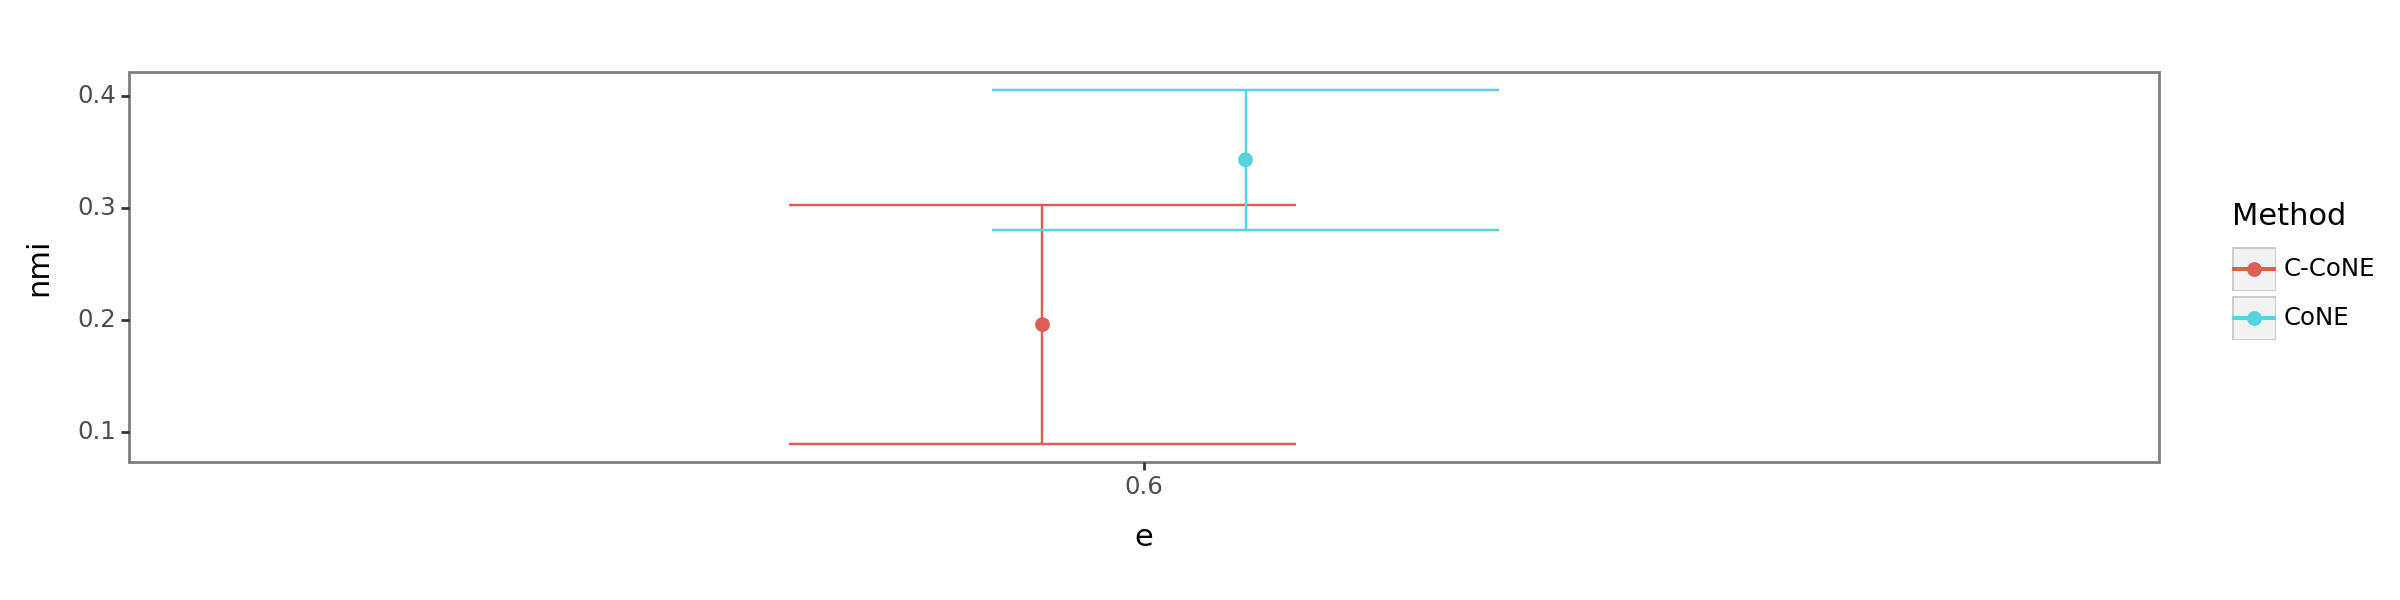

In [117]:
summary = (
    df.groupby(["run_name"])["nmi"]
        .agg(n='count', mean='mean', std='std').reset_index()
)
summary.rename(columns={'g_ps':r'$g_{ps}$','c_ps':r'$c_{ps}$'},inplace=True)
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["n"])         # normal approx 95% CI
summary["ymin"] = summary["mean"] - summary["ci95"]
summary["ymax"] = summary["mean"] + summary["ci95"]
dodge = position_dodge(width = .2)
p = (
ggplot(summary, aes(x="factor(e)", y="mean", color="run_name", group="run_name"))
+ geom_point(size=2,position=dodge)
+ geom_line(position=dodge)
+ geom_errorbar(aes(ymin="ymin",ymax="ymax"),position=dodge)
+ labs(x="e", y="nmi", title='',color='Method')
+ theme_bw()
+ theme(
    panel_grid_major = element_blank(),
    panel_grid_minor = element_blank()
)
+ theme(figure_size=(12,3))
)
print(p)

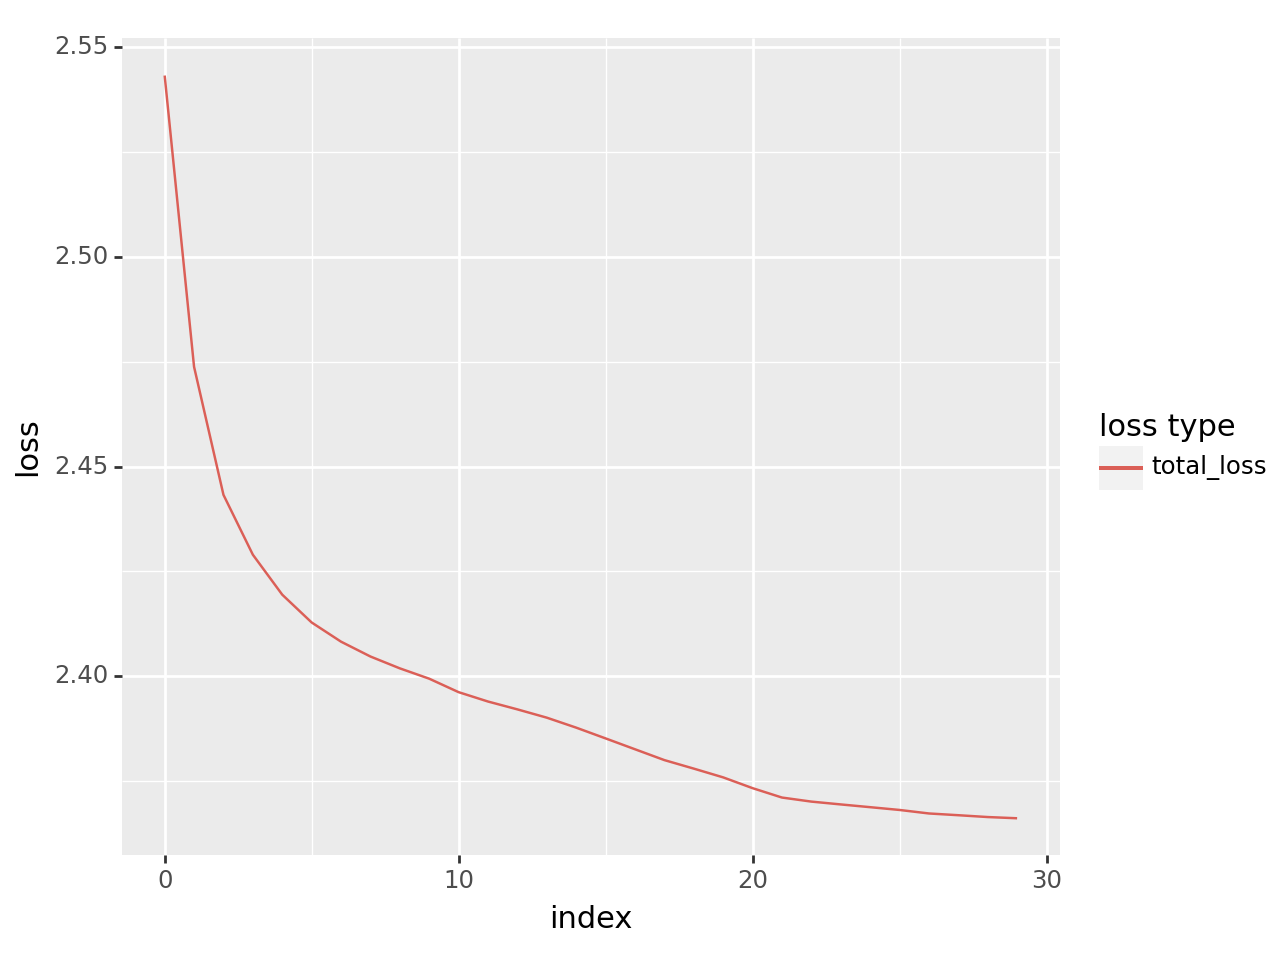

<Figure Size: (640 x 480)>

In [5]:
loss_df = pd.DataFrame(loss_function).reset_index()
loss_df = pd.melt(loss_df,id_vars=['index'],value_vars=['total_loss'],var_name='loss type',value_name='loss')
from plotnine import *
p = ggplot(loss_df,aes(x='index',y='loss',color='loss type'))+ geom_line()
p

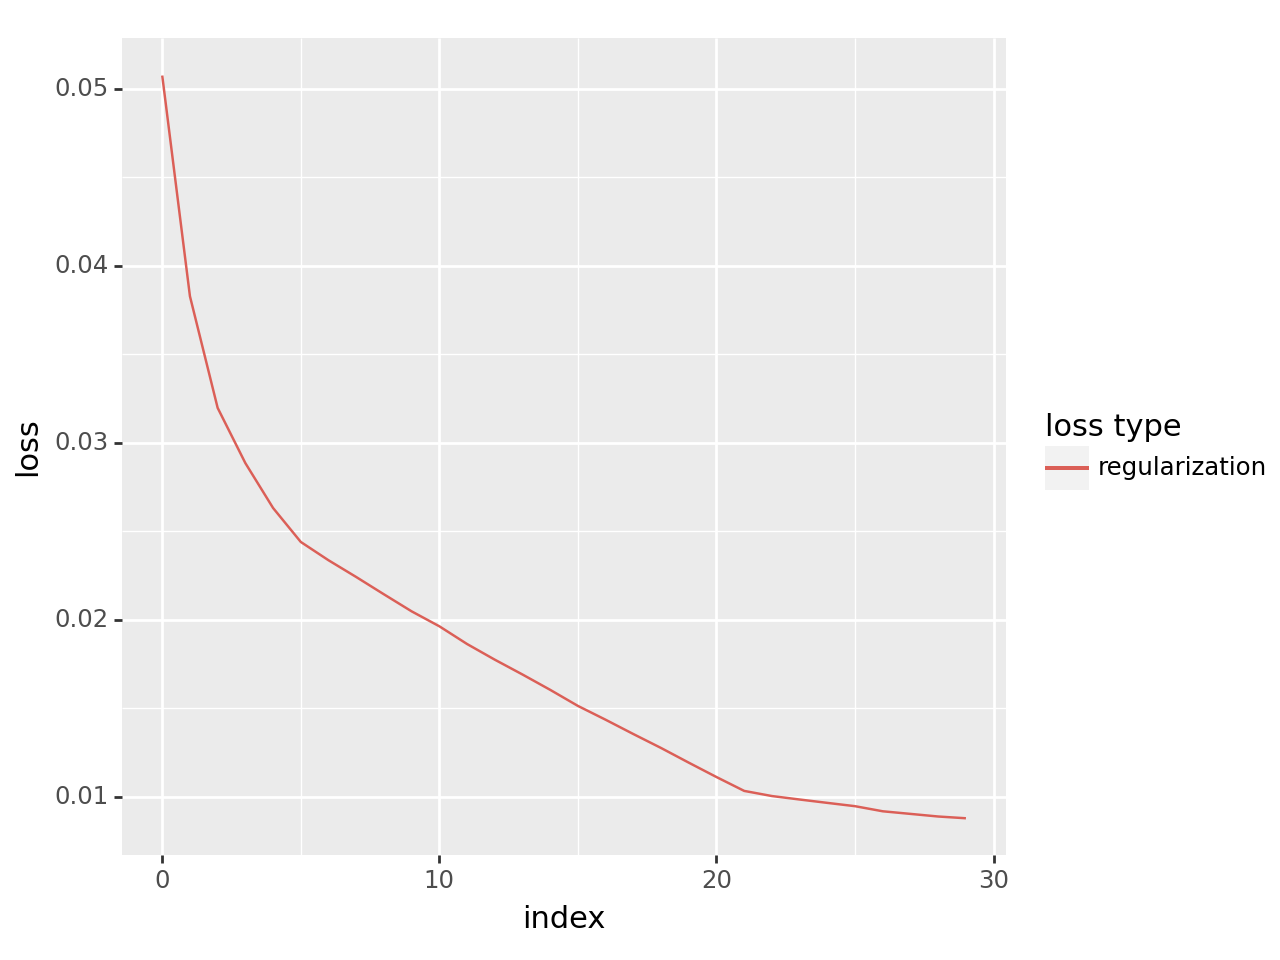

<Figure Size: (640 x 480)>

In [6]:
loss_df = pd.DataFrame(loss_function).reset_index()
loss_df = pd.melt(loss_df,id_vars=['index'],value_vars=['regularization'],var_name='loss type',value_name='loss')
from plotnine import *
p = ggplot(loss_df,aes(x='index',y='loss',color='loss type'))+ geom_line()
p

running mvbc

In [7]:
import json
import algorithms.MVBCWrapper as MVBCWrapper
G_path = f'{sim_output_dir}/G_{output_file_suffix}.raw'
C_path = f'{sim_output_dir}/C_{output_file_suffix}.npy'
lambda_W,lambda_H_G,lambda_H_C = (0,0,0)
rank=3

def MVBCWrapper(G_path, C_path, rank, lambda_W, lambda_H_G, lambda_H_C, r_path):
    result = subprocess.run(
    f'{r_path} algorithms/MVBC.R {G_path} {C_path} {rank} {lambda_W} {lambda_H_G} {lambda_H_C}',
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True,
    shell=True, executable='/bin/bash')
    r_output = result.stdout.strip()
    warn_output = result.stderr.strip()
    print(r_output)
    print(warn_output)

MVBCWrapper(G_path, C_path, rank, lambda_W, lambda_H_G, lambda_H_C, r_path)

{"factor_matrices":{"W":[[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0]

running rgwas

In [94]:
e_list = [0.25, 0.50, 0.75, 1]
g_ps_list = [0,0.25,0.75]
c_ps_list = [0,0.1,0.3]
dataset_list = range(11)
combos = [(e, g_ps, c_ps, d) for e, g_ps in product(e_list, g_ps_list) for c_ps in ([0] if g_ps == 0 else c_ps_list) for d in dataset_list]
len(combos)

308

In [8]:
from algorithms import RGWASWrapper
import importlib
importlib.reload(RGWASWrapper)
G_path = f'{sim_output_dir}/G_{output_file_suffix}.raw'
C_path = f'{sim_output_dir}/C_{output_file_suffix}.npy'
Z_path = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5.Q'
# save iid index
output_suffix = output_file_suffix
iid_index_path = f'{sim_output_dir}/iid_index_{output_suffix}.npy'
np.save(iid_index_path,iid_index.to_numpy())
if len(iid_index)<500: # need to subset to only linked features 
    clinical_assoc = list(set([x for sub in simulation_metadata['clinical_assoc']['indices'].values.tolist() for x in sub]))
    C_subset = C[:,clinical_assoc] 
    np.save(f'{sim_output_dir}/C_subset_{output_suffix}.npy', C_subset)
    C_path= f'{sim_output_dir}/C_subset_{output_suffix}.npy'

    markers_assoc = list(set([x for sub in simulation_metadata['markers_assoc'].values() for x in sub]))
    with open(f'{sim_output_dir}/markers_assoc_G_subset_{output_suffix}.txt','w') as f:
        for snp in markers_assoc:
            f.write(snp + "\n")
    plink_extract = f'''
        module load plink/1.9 && plink --bfile {sim_output_dir}/G_{output_suffix} \
            --recode A \
            --extract {sim_output_dir}/markers_assoc_G_subset_{output_suffix}.txt\
            --out {sim_output_dir}/G_subset_{output_suffix}
        '''
    result = subprocess.run(plink_extract, shell=True, check=True, executable="/bin/bash")
    G_path=f'{sim_output_dir}/G_subset_{output_suffix}.raw'


factor_matrices, loss_history = RGWASWrapper.RGWASWrapper(iid_index_path,r_path, G_path, C_path, Z_path ,num_init=5)


PLINK v1.90b6.21 64-bit (19 Oct 2020)          www.cog-genomics.org/plink/1.9/
(C) 2005-2020 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/G_subset_e_0.25_g_ps_0_c_ps_0_dataset_6.log.
Options in effect:
  --bfile /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/G_e_0.25_g_ps_0_c_ps_0_dataset_6
  --extract /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/markers_assoc_G_subset_e_0.25_g_ps_0_c_ps_0_dataset_6.txt
  --out /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/G_subset_e_0.25_g_ps_0_c_ps_0_dataset_6
  --recode A

773571 MB RAM detected; reserving 386785 MB for main workspace.
100 variants loaded from .bim file.
417 people (0 males, 0 females, 417 ambiguous) loaded from .fam.
Ambiguous sex IDs written to
/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/da

In [14]:
W_true = (simulation_metadata['phenotypic_subgroups'].pivot(index='IID',columns='phenotypic_subgroup',values='subgroup')
        .reindex(simulation_metadata['iid_order']).iloc[:,:2].to_numpy().astype(int))
ground_truth = {"W":W_true}


In [15]:
cluster_evaluation.compute_sim_metrics(factor_matrices,ground_truth)

{'purity': 0.8200956937799043,
 'norm_cond_entropy': 0.6641397170370558,
 'nmi': 0.2639464077067433}

In [ ]:
C.sum()/G.sum()

0.14364134296002576

In [22]:
import hashlib

def seed_from(*xs):
    s = "|".join(f"{x:.8g}" if isinstance(x, float) else str(x) for x in xs)
    return int(hashlib.md5(s.encode()).hexdigest()[:8], 16)  
seed_from("markers",g_ps)

433049560

# Working on test code

In [ ]:
e_list = [0.4,0.6,0.8,1]
g_ps_list = [0,0.25,0.75]
c_ps_list = [0,0.1,0.2,0.3,0.4,0.5,1,2,10]
dataset_list = range(11) # 11 random datasets for each combination 
bfile_path=f'{sim_output_dir}/G'
af_df_filepath=admixture_filepath
rank = 3
num_markers = 100

maf_by_superpop = pd.read_csv(maf_by_superpop_filepath,sep='\s+')
superpopulations = maf_by_superpop['CLST'].unique()
maf_by_superpop = maf_by_superpop.pivot(index=['SNP'],columns='CLST',values='MAF').reset_index()
igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath,bfile_path)

# calculate weighted af variance
w = igsr_samples['Superpopulation code'].value_counts().to_numpy(float)
w_code_index = igsr_samples['Superpopulation code'].value_counts().index
X = maf_by_superpop[w_code_index].to_numpy(float)  

w = w / w.sum()
mu = X @ w                                        
maf_by_superpop['af_variance_weighted'] = ((X - mu[:, None])**2 * w[None, :]).sum(axis=1)
q1 = maf_by_superpop['af_variance_weighted'].quantile(0.25)
q3 = maf_by_superpop['af_variance_weighted'].quantile(0.75)
# Mark bottom/top quartiles; leave middle as NaN 
maf_by_superpop["af_var_quartile"] = np.select([maf_by_superpop['af_variance_weighted'] <= q1, maf_by_superpop['af_variance_weighted'] >= q3],[0.25, 0.75],default=np.nan)

g_all_markers = {}
rows = []
rows_columns = ['g_ps','c_ps','e','pheno_subgroup','metric']
for g_ps,c_ps, e, dataset in product(g_ps_list,c_ps_list, e_list, dataset_list):
    if g_ps !=0:
        output_suffix = sim_functions.get_output_file_suffix(g_ps=g_ps, c_ps=c_ps, e=e, dataset=dataset)
        output_file_suffix = output_suffix
        C_path = f'{sim_output_dir}/C_{output_suffix}.npy'
        C = np.load(C_path)
        with open(f"{sim_output_dir}/simulation_metadata_{output_suffix}.pkl", "rb") as f:
            simulation_metadata = pickle.load(f)
        all_markers_assoc = set(sum(simulation_metadata['markers_assoc'].values(), []))
        assoc_markers_in_quartile = [i for i in all_markers_assoc if i in maf_by_superpop[maf_by_superpop["af_var_quartile"]==g_ps]['SNP'].values.tolist()]
        bim_df = pd.read_csv(f'{sim_output_dir}/G_{output_file_suffix}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2']).reset_index(drop=True)
        bim_df['in_g_ps'] = bim_df['SNP'].isin(maf_by_superpop[maf_by_superpop["af_var_quartile"]==g_ps]['SNP'].values.tolist())
        g_all_markers[g_ps] = bim_df['SNP'].values.tolist()
        # get correlation between population superpopulation and phenotypic subgroup
        phenotypic_subgroups = simulation_metadata['phenotypic_subgroups'].copy()
        for pheno_subgroup in range(4):
            # avg correlation between all superpopulation codes
            pheno_subgroup_df = phenotypic_subgroups[phenotypic_subgroups['phenotypic_subgroup']==pheno_subgroup][['IID','subgroup']].merge(igsr_samples[['IID','Superpopulation code']],on='IID')
            pheno_subgroup_df = pheno_subgroup_df[['IID','subgroup']].join(pd.get_dummies(pheno_subgroup_df['Superpopulation code']))
            pheno_subgroup_df['subgroup'] = pheno_subgroup_df['subgroup'].astype(int)
            corr_within_subgp = []
            for superpop in superpopulations:
                if np.nanstd(pheno_subgroup_df['subgroup'].values, axis=0) == 0:
                    print(f'pheno value 0 for g_ps: {g_ps}, c_ps: {c_ps}, e: {e}, pheno subgroup: {pheno_subgroup}',flush=True)
                    assert True == False
                if np.nanstd(pheno_subgroup_df[superpop].values, axis=0) == 0:
                    print(f'pheno value 0 for g_ps: {g_ps}, c_ps: {c_ps}, e: {e}, superpop: {superpop}',flush=True)
                corr_within_subgp.append(np.corrcoef(pheno_subgroup_df['subgroup'].values,pheno_subgroup_df[superpop].values)[0,1])
            rows.append([g_ps,c_ps,e,pheno_subgroup,np.mean(corr_within_subgp)])
df = pd.DataFrame(rows,columns=rows_columns)

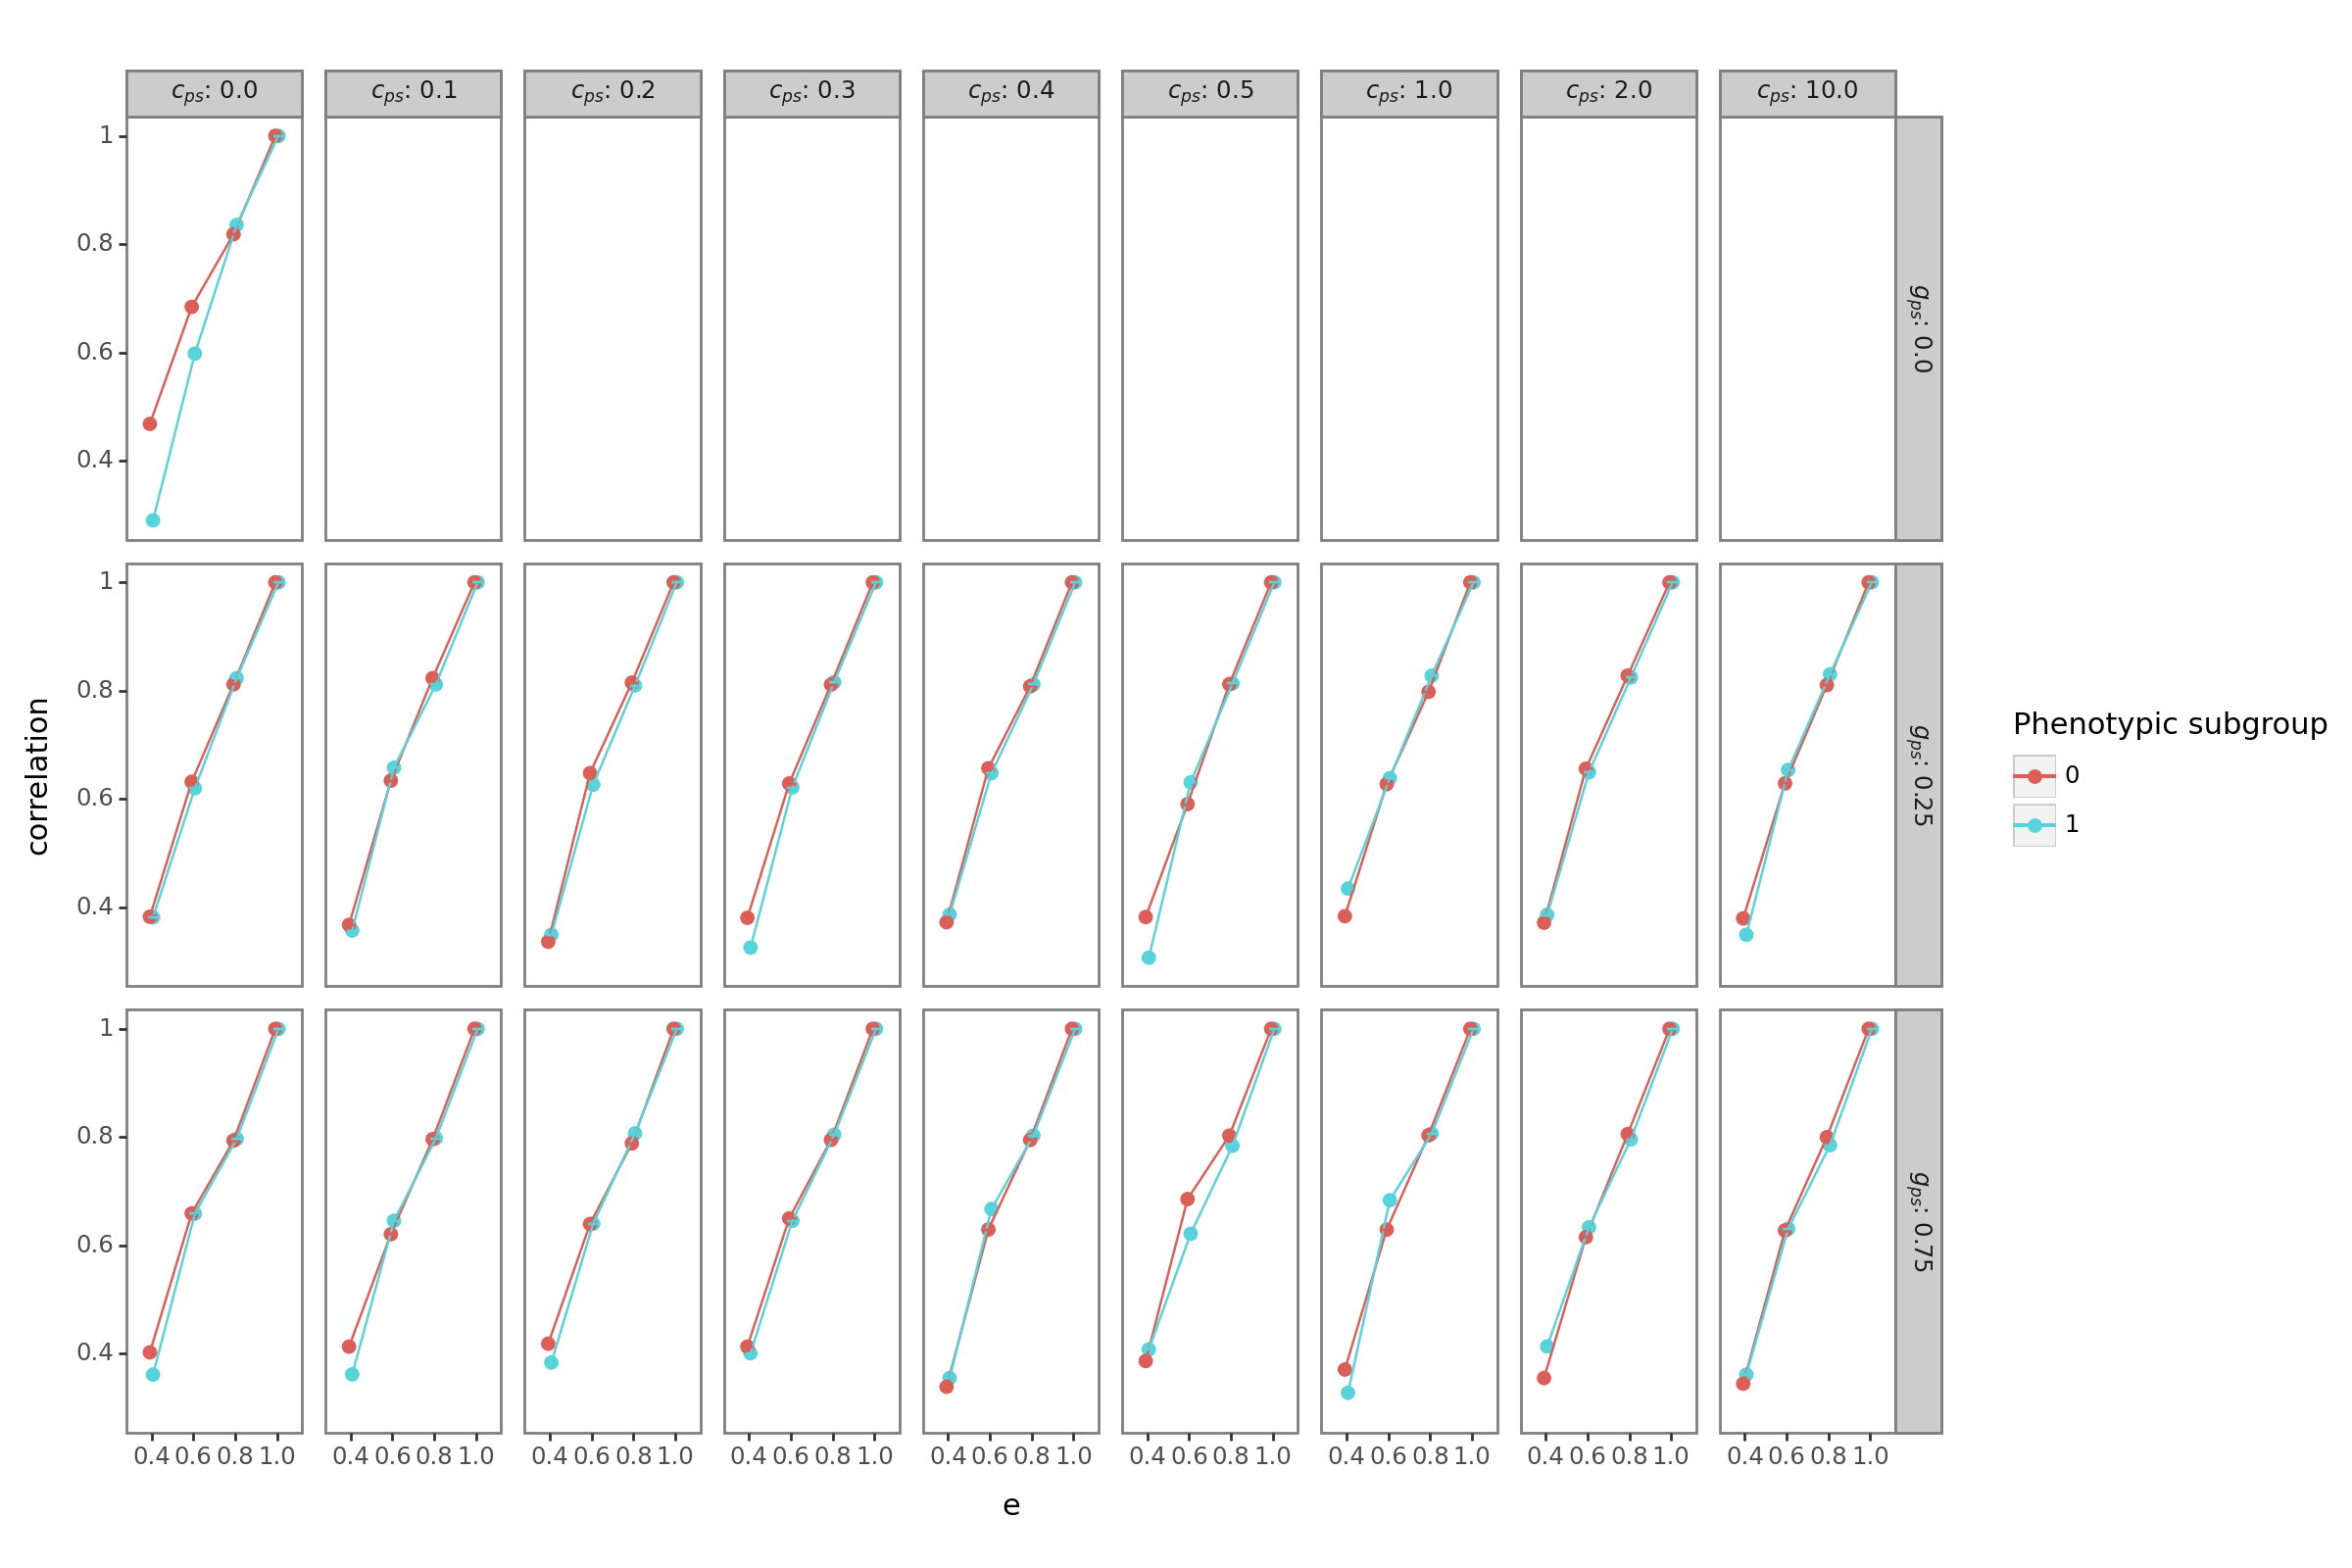

In [142]:
e_list = [0.4,0.6,0.8,1]
g_ps_list = [0,0.25,0.75]
c_ps_list = [0,0.1,0.2,0.3,0.4,0.5,1,2,10]
dataset_list = range(11) # 11 random datasets for each combination 
combos = [(e, g_ps, c_ps, d) for e, g_ps in product(e_list, g_ps_list) for c_ps in ([0] if g_ps == 0 else c_ps_list) for d in dataset_list]
rows = []
for (e, g_ps, c_ps, d) in combos:
    output_suffix = sim_functions.get_output_file_suffix(g_ps=g_ps, c_ps=c_ps, e=e, dataset=dataset)
    with open(f"{sim_output_dir}/simulation_metadata_{output_suffix}.pkl", "rb") as f:
        simulation_metadata = pickle.load(f)
    genetic_subgroups = simulation_metadata['genetic_subgroups']
    phenotypic_subgroups = simulation_metadata['phenotypic_subgroups']
    mean_corr = []
    for k in range(2):
        corr = np.corrcoef(genetic_subgroups[f'subgroup{k}'],phenotypic_subgroups[f'subgroup{k}'])[0,1]
        rows.append([k,e, g_ps, c_ps, d, corr])
df = pd.DataFrame(rows,columns=["pheno_subgroup", "e", "g_ps", "c_ps", "d", "corr"])    
summary = (
    df.groupby(["pheno_subgroup", "g_ps", "c_ps", "e"])["corr"]
        .agg(n='count', mean='mean', std='std').reset_index()
)
summary.rename(columns={'g_ps':r'$g_{ps}$','c_ps':r'$c_{ps}$'},inplace=True)
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["n"])         # normal approx 95% CI
summary["ymin"] = summary["mean"] - summary["ci95"]
summary["ymax"] = summary["mean"] + summary["ci95"]
dodge = position_dodge(width=0.15)
p = (
ggplot(summary, aes(x="factor(e)", y="mean", color="factor(pheno_subgroup)", group="factor(pheno_subgroup)"))
+ geom_point(size=2,position=dodge)
+ geom_line(position=dodge)
+ geom_errorbar(aes(ymin="ymin",ymax="ymax"),position=dodge)
+ labs(x="e", y="correlation", title='',color='Phenotypic subgroup')
+ facet_grid(r'$g_{ps}$ ~ $c_{ps}$',labeller='label_both')
+ theme_bw()
+ theme(
    panel_grid_major = element_blank(),
    panel_grid_minor = element_blank()
)
+ theme(figure_size=(12,8))
)
print(p)

PLINK v1.90b6.21 64-bit (19 Oct 2020)          www.cog-genomics.org/plink/1.9/
(C) 2005-2020 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/null_pool_G.log.
Options in effect:
  --bfile /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/G
  --extract /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink/null_pool.txt
  --make-bed
  --out /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/null_pool_G
  --recode A

369425 MB RAM detected; reserving 184712 MB for main workspace.
193634 variants loaded from .bim file.
2504 people (0 males, 0 females, 2504 ambiguous) loaded from .fam.
Ambiguous sex IDs written to
/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/null_pool_G.nosex
.
--extract: 9682 variants remaining.
Using 1 thread (no mult

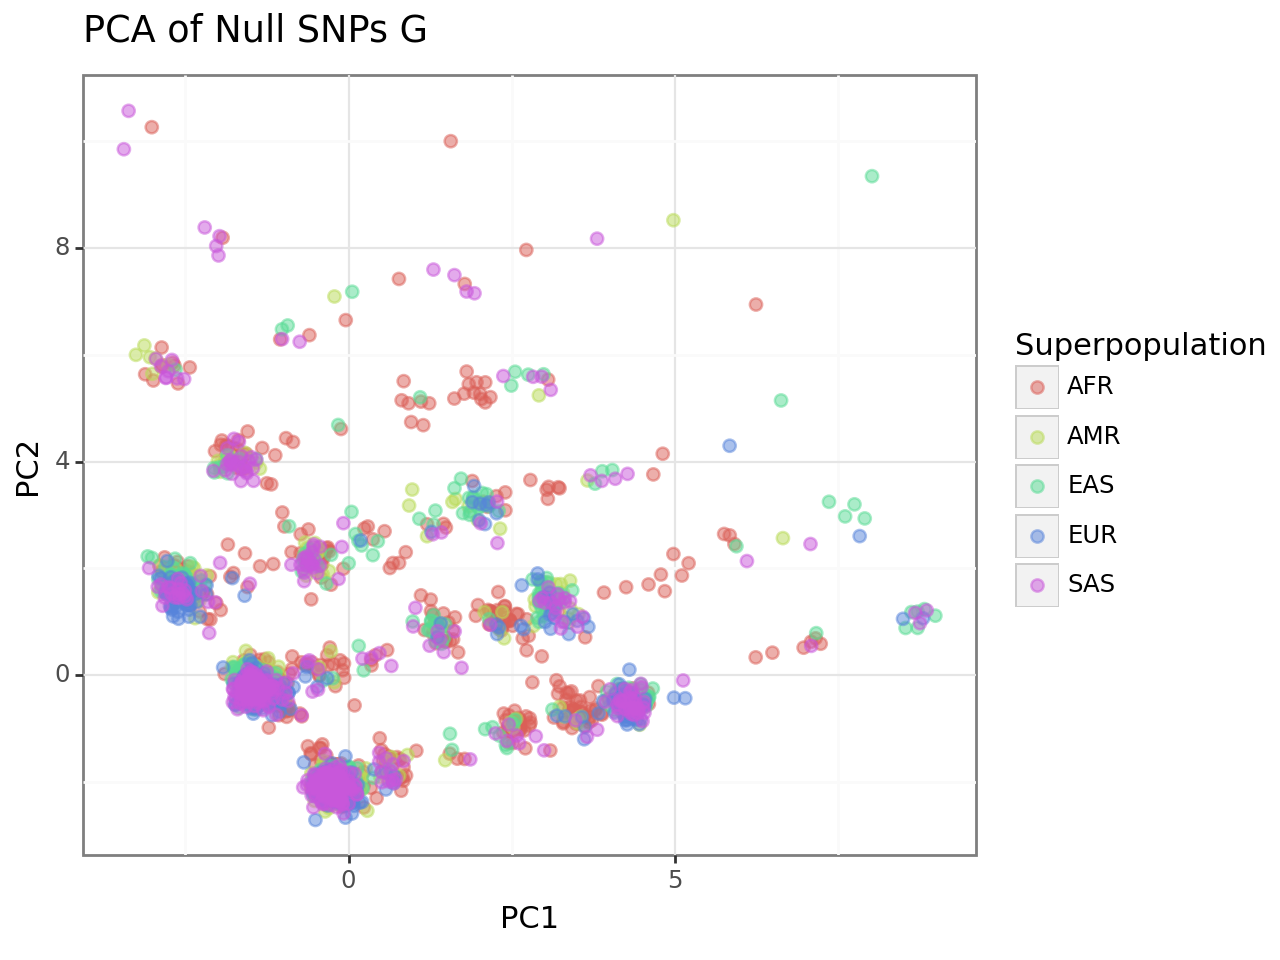

In [72]:
# generate a null snv pool
maf_by_superpop = pd.read_csv(maf_by_superpop_filepath,sep='\s+')
superpopulations = maf_by_superpop['CLST'].unique()
maf_by_superpop = maf_by_superpop.pivot(index=['SNP'],columns='CLST',values='MAF').reset_index()
igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath,bfile_path)

w = igsr_samples['Superpopulation code'].value_counts().to_numpy(float)
w_code_index = igsr_samples['Superpopulation code'].value_counts().index
X = maf_by_superpop[w_code_index].to_numpy(float)  

w = w / w.sum()
mu = X @ w                                        
maf_by_superpop['af_variance_weighted'] = ((X - mu[:, None])**2 * w[None, :]).sum(axis=1)
fifth_percentile = q1 = maf_by_superpop['af_variance_weighted'].quantile(0.05) # TODO trying, might need to remove
maf_by_superpop["null_pool"] = maf_by_superpop['af_variance_weighted'] <= fifth_percentile
maf_by_superpop[maf_by_superpop['null_pool']].shape
with open(f'{intermediate_plink_dir}/null_pool.txt','w') as f:
    for snp in maf_by_superpop[maf_by_superpop['null_pool']]['SNP'].values:
        f.write(snp + "\n")

plink_extract = f'''
module load plink/1.9 && plink --bfile {bfile_path} \
    --extract {intermediate_plink_dir}/null_pool.txt \
    --make-bed \
    --recode A \
    --out {sim_output_dir}/null_pool_G
'''
result = subprocess.run(plink_extract, shell=True, check=True, executable="/bin/bash")
# 3. Generate phenotypic subgroups
fam_df = pd.read_csv(f'{sim_output_dir}/G.fam',sep='\s+',header=None)
fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
iid_order = fam_df['IID'].values.tolist()
matrix = np.loadtxt(f'{sim_output_dir}/null_pool_G.raw',  usecols=range(6, num_markers+6), dtype=np.int8, skiprows=1)
scaled = StandardScaler().fit_transform(matrix) 
pca = PCA(n_components=2, random_state=0)  
embedding = pca.fit_transform(scaled) 
plot_df = (pd.DataFrame(embedding, columns=["PC1", "PC2"], index=iid_order).
                            rename_axis("IID").reset_index().merge(igsr_samples[['IID','Superpopulation code']], on='IID',how='inner'))
plot_df.rename(columns={'Superpopulation code':'label'},inplace=True)

p = (
    ggplot(plot_df, aes("PC1", "PC2", color='label'))
    + geom_point(alpha=0.5, size=2)
    + labs(title=f'PCA of Null SNPs G', color="Superpopulation")
    + theme_bw()
)
print(p)

In [58]:
output_suffix = sim_functions.get_output_file_suffix(g_ps=0, c_ps=0, e=1, dataset=dataset)
with open(f"{sim_output_dir}/simulation_metadata_{output_suffix}.pkl", "rb") as f:
            simulation_metadata = pickle.load(f)
phenotypic_subgroups = simulation_metadata['phenotypic_subgroups'].copy()
genetic_subgroups = simulation_metadata['genetic_subgroups'].copy()
clinical_assoc_df = simulation_metadata['clinical_assoc'].copy()
marker_assoc_df =  simulation_metadata['markers_assoc'].copy()

In [65]:
bim = pd.read_csv(f'{sim_output_dir}/G_{output_suffix}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2']).reset_index(drop=True)
bim[bim['SNP'].isin(marker_assoc_df['SNP'].values.tolist())].index

Int64Index([3, 8, 9, 10, 11, 14, 22, 28, 29, 30, 32, 33, 56, 58, 61, 80, 84,
            86, 93],
           dtype='int64')

In [7]:
from sklearn.preprocessing import StandardScaler
from plotnine import *
import importlib
from sklearn.decomposition import PCA
importlib.reload(sim_functions)

# umap of G with superpopulation label & also genetic subgroup label
e_list = [0.25, 0.50, 0.75, 1] 
g_ps_list = [0,0.25,0.75]
c_ps_list = [0,0.1,0.3]
dataset_list = range(11) # 11 random datasets for each combination 
bfile_path=f'{sim_output_dir}/G'
af_df_filepath=admixture_filepath
rank = 3
num_markers = 100

def regress_out(Z, X):

    # 2) Center columns
    Xc = X - X.mean(axis=0, keepdims=True)
    Zc = Z - Z.mean(axis=0, keepdims=True)

    # 3) Orthonormal basis for Z (numerically stable)
    #   Use QR; Q has orthonormal columns spanning col(Zc)
    Q, _ = np.linalg.qr(Zc, mode="reduced")        # shape (n, r)
    # 4) Project X onto col(Z) and compute residuals
    X_hat = Q @ (Q.T @ Xc)
    R = Xc - X_hat

    # 5) Fraction of centered variance removed
    frac_removed = (np.linalg.norm(X_hat, 'fro')**2) / (np.linalg.norm(Xc, 'fro')**2 + 1e-12)
    return R, frac_removed


def superpop_matrix_pca(g_ps_list, c_ps_list, e, dataset, matrix_name, type, regressed=False):
    plot_dfs = []
    for (g_ps, c_ps) in list(product(g_ps_list,c_ps_list)):
        if g_ps==0 and c_ps!=0:
             continue
        output_suffix = sim_functions.get_output_file_suffix(g_ps=g_ps, c_ps=c_ps, e=e, dataset=dataset)
        with open(f"{sim_output_dir}/simulation_metadata_{output_suffix}.pkl", "rb") as f:
                    simulation_metadata = pickle.load(f)
        phenotypic_subgroups = simulation_metadata['phenotypic_subgroups'].copy()
        genetic_subgroups = simulation_metadata['genetic_subgroups'].copy()
        marker_assoc_df =  simulation_metadata['markers_assoc'].copy()

        iid_order = simulation_metadata['iid_order']
        igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath, bfile_path=f'{sim_output_dir}/G')
        if matrix_name=='G':
            matrix = np.loadtxt(f'{sim_output_dir}/G_{output_suffix}.raw',  usecols=range(6, num_markers+6), dtype=np.int8, skiprows=1)
            bim = pd.read_csv(f'{sim_output_dir}/G_{output_suffix}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2']).reset_index(drop=True)
            columns = bim[bim['SNP'].isin(marker_assoc_df['SNP'].values.tolist())].index
        elif matrix_name=='C':
            matrix = np.load(f'{sim_output_dir}/C_{output_suffix}.npy')
            columns = range(100)
        if regressed:
            fam_df = pd.read_csv(f'{bfile_path}.fam',sep='\s+',header=None) 
            fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
            iid_index = fam_df[fam_df['IID'].isin(simulation_metadata['iid_order'])].index 
            matrix, frac_removed = regress_out(Z[iid_index,:], matrix)
        
        scaled = StandardScaler().fit_transform(matrix[:,columns]) 
        pca = PCA(n_components=2, random_state=0)  
        embedding = pca.fit_transform(scaled) 
        if type == 'superpopulation':
            plot_df = (pd.DataFrame(embedding, columns=["PC1", "PC2"], index=iid_order).
                            rename_axis("IID").reset_index().merge(igsr_samples[['IID','Superpopulation code']], on='IID',how='inner'))
            plot_df.rename(columns={'Superpopulation code':'label'},inplace=True)
        elif type=='phenotypic subgroup':
            labels_df = phenotypic_subgroups.melt(id_vars=['IID'],value_vars=[c for c in phenotypic_subgroups.columns if c.startswith('subgroup')],
                                      var_name='subgroup', value_name='value')
            labels = (labels_df[labels_df['value']==1].assign(sub_idx=lambda d: d['subgroup'].str.replace('subgroup','',regex=False).astype(int))
                      .groupby('IID')['sub_idx'].min().rename('label'))           
            out = pd.DataFrame(index=phenotypic_subgroups['IID'].unique()).sort_index()
            out['phenotypic_subgroup'] = 99
            out.loc[labels.index, 'phenotypic_subgroup'] = labels
            out = out.reset_index().rename(columns={"index": "IID"})
            plot_df = (pd.DataFrame(embedding, columns=["PC1", "PC2"], index=iid_order).
                    rename_axis("IID").reset_index().merge(out[['IID','phenotypic_subgroup']], on='IID',how='inner'))
            plot_df.rename(columns={'phenotypic_subgroup':'label'},inplace=True)
        elif type=='genetic subgroup':
            labels_df = genetic_subgroups.melt(id_vars=['IID'],value_vars=[c for c in genetic_subgroups.columns if c.startswith('subgroup')],
                            var_name='subgroup', value_name='value')
            labels = (labels_df.loc[lambda d: d['value']==1].groupby('IID')['subgroup']
            .apply(lambda s: ','.join(map(str, sorted(s)))))
            # fill others as 'control'
            out = pd.DataFrame(index=genetic_subgroups['IID'].unique()).sort_index()
            out['genetic_subgroup'] = 'control'
            out.loc[labels.index, 'genetic_subgroup'] = labels
            out = out.reset_index().rename(columns={"index": "IID"})
            plot_df = (pd.DataFrame(embedding, columns=["PC1", "PC2"], index=iid_order).
                    rename_axis("IID").reset_index().merge(out[['IID','genetic_subgroup']], on='IID',how='inner'))
            plot_df.rename(columns={'genetic_subgroup':'label'},inplace=True)
        plot_df['g_ps'] = g_ps
        plot_df['c_ps'] = c_ps
        plot_dfs.append(plot_df)
    plot_dfs = pd.concat(plot_dfs)
    p = (
        ggplot(plot_dfs, aes("PC1", "PC2", color='factor(label)'))
        + geom_point(alpha=0.5, size=2)
        + labs(title=f'PCA of {matrix_name}', color=type)
        + facet_grid(f'g_ps ~ c_ps')
        + theme(legend_title=element_text(size=9),figure_size=(6,4))
        + theme_bw()
    )
    print(p)


0
0.4


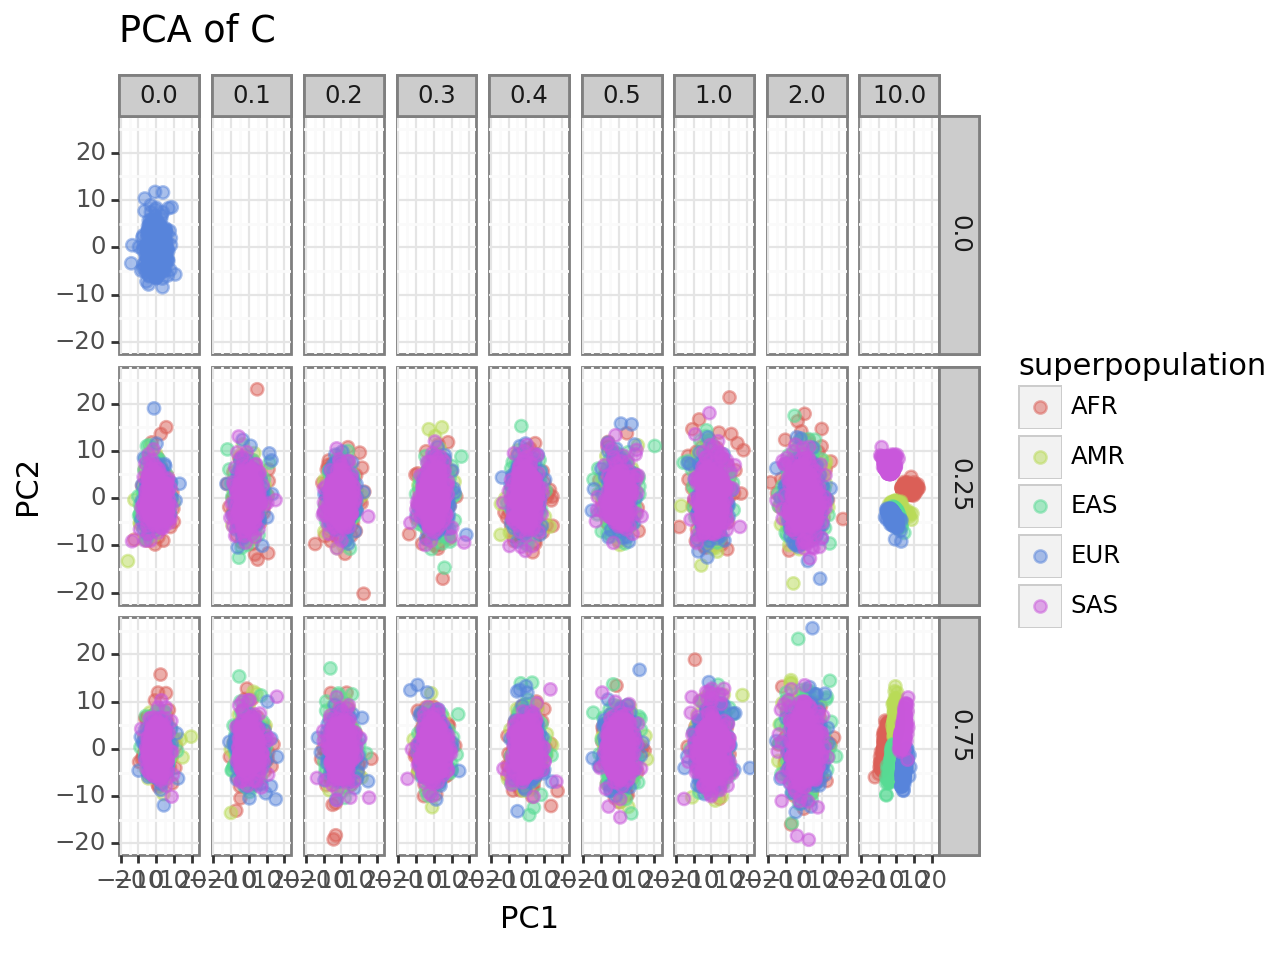

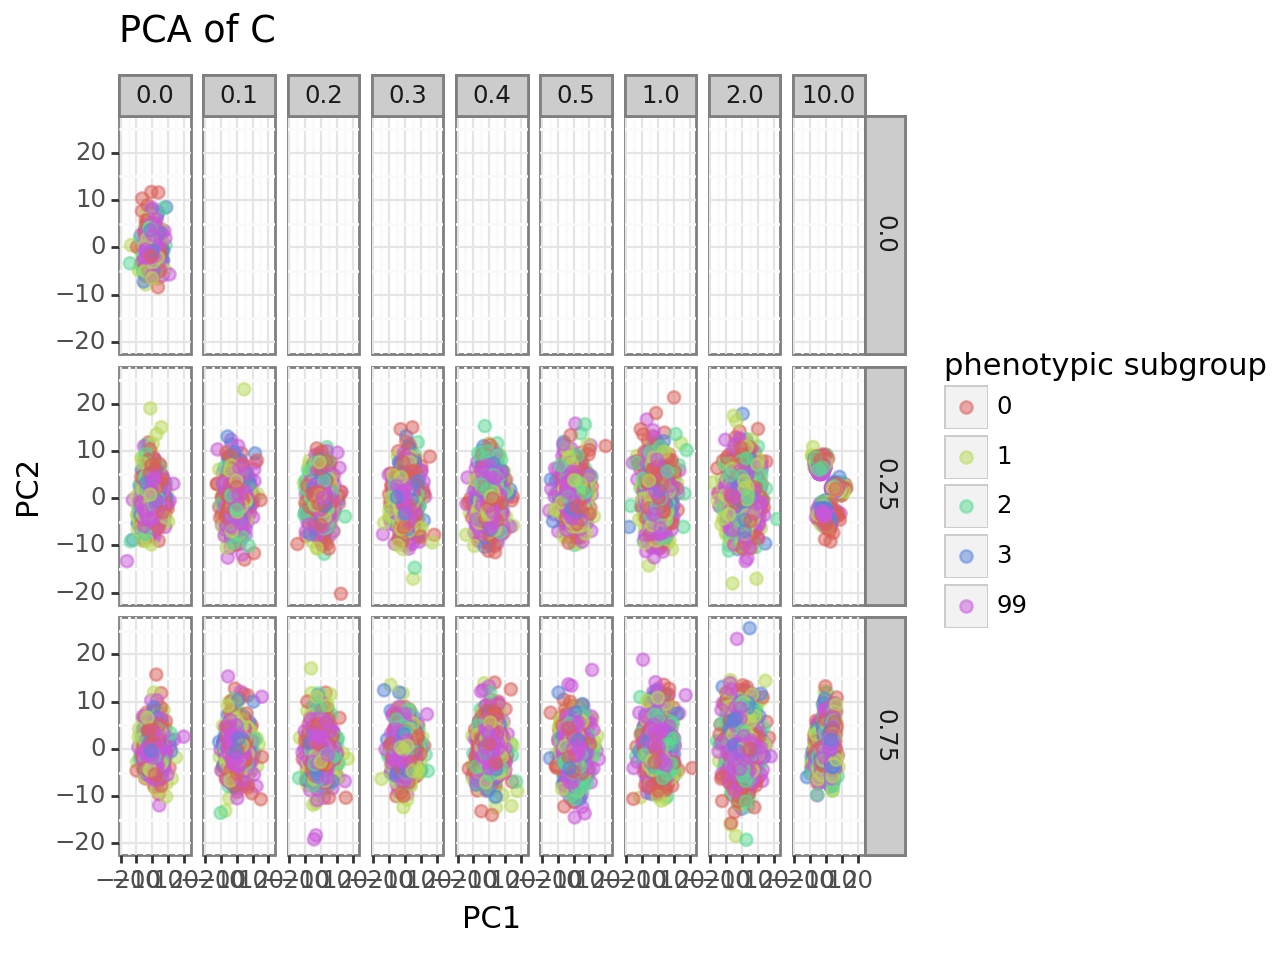

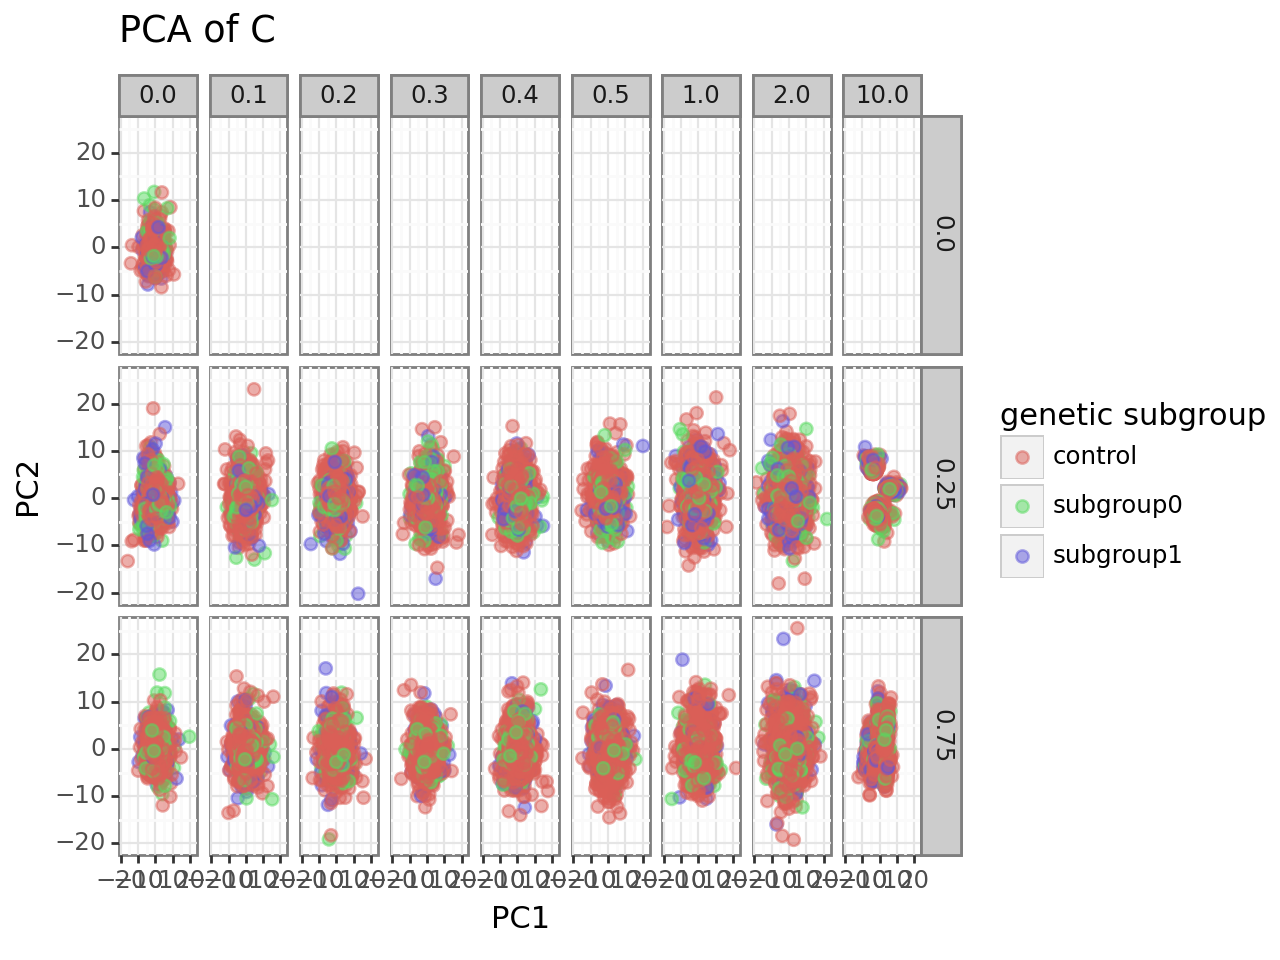


-----
0.6


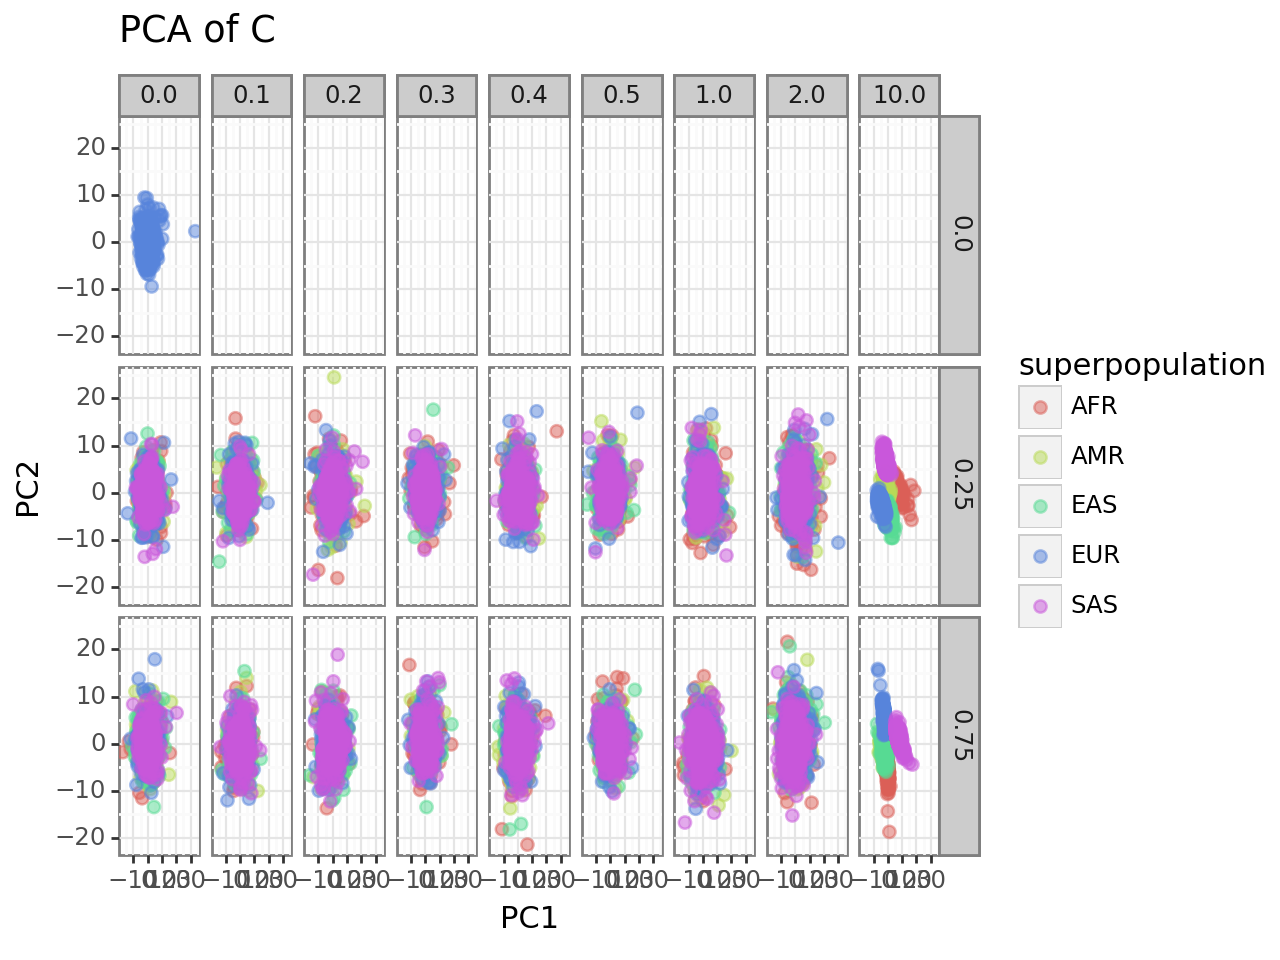

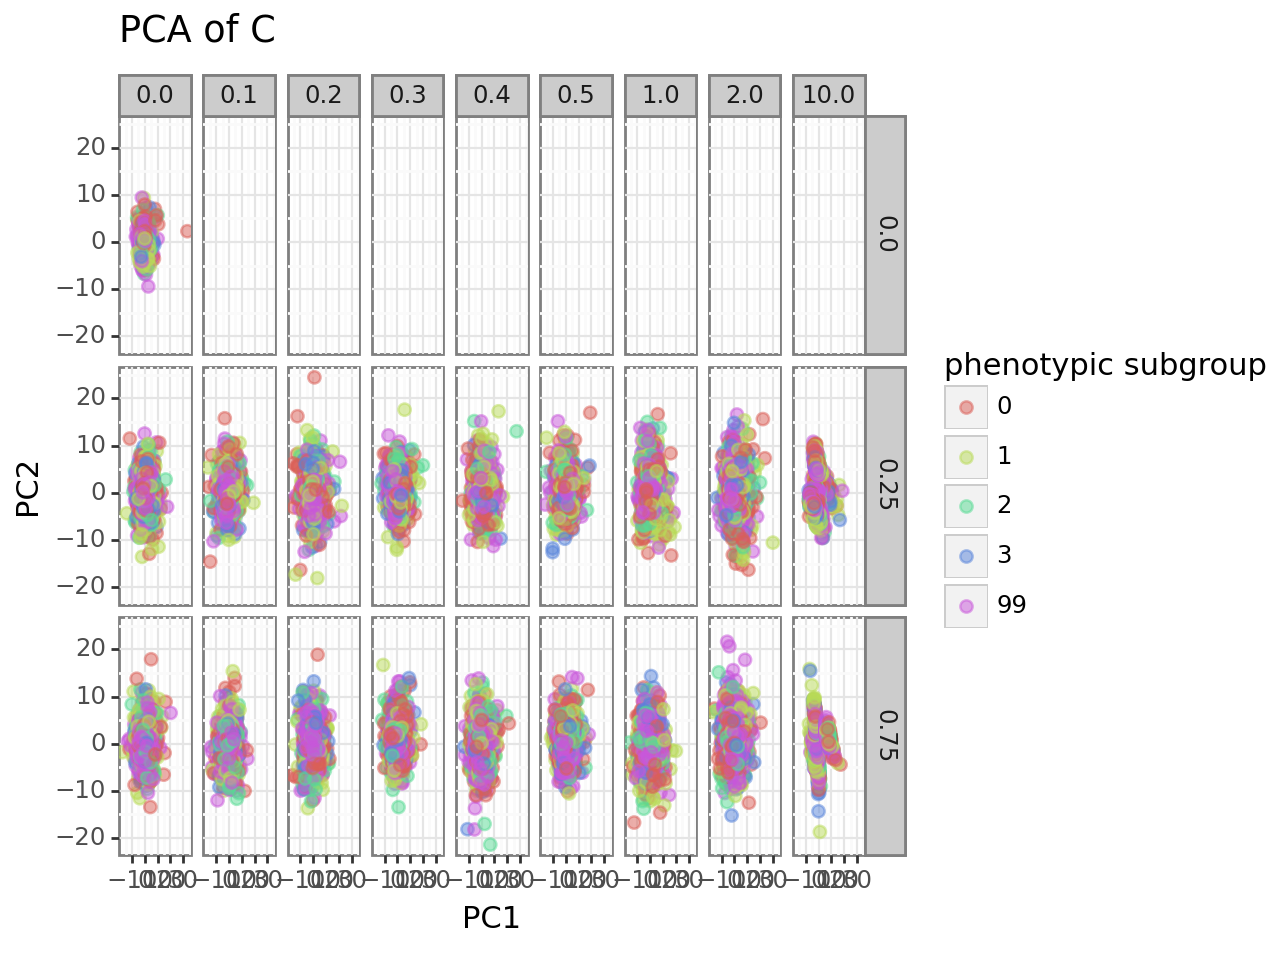

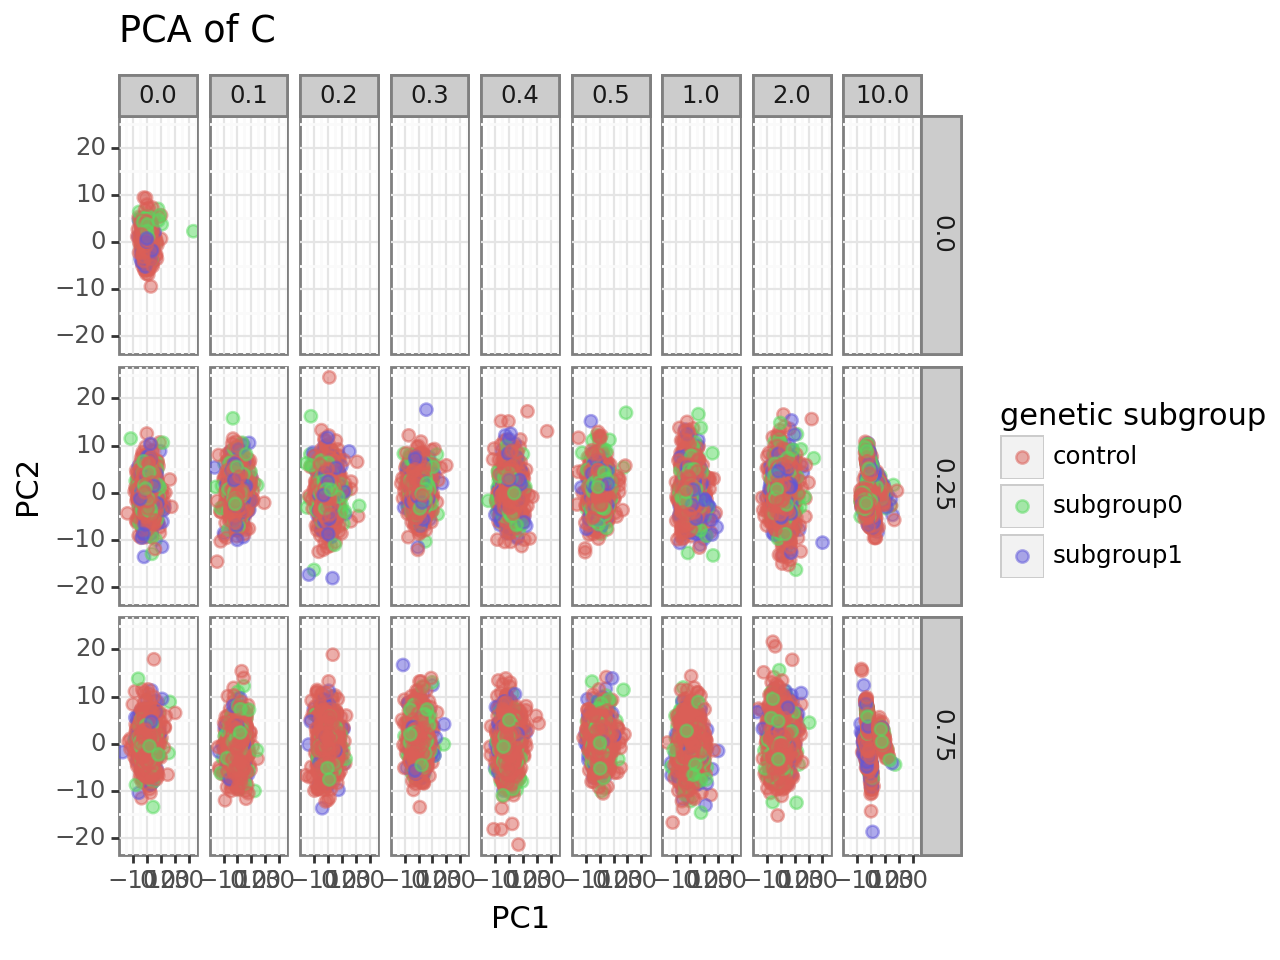


-----
0.8


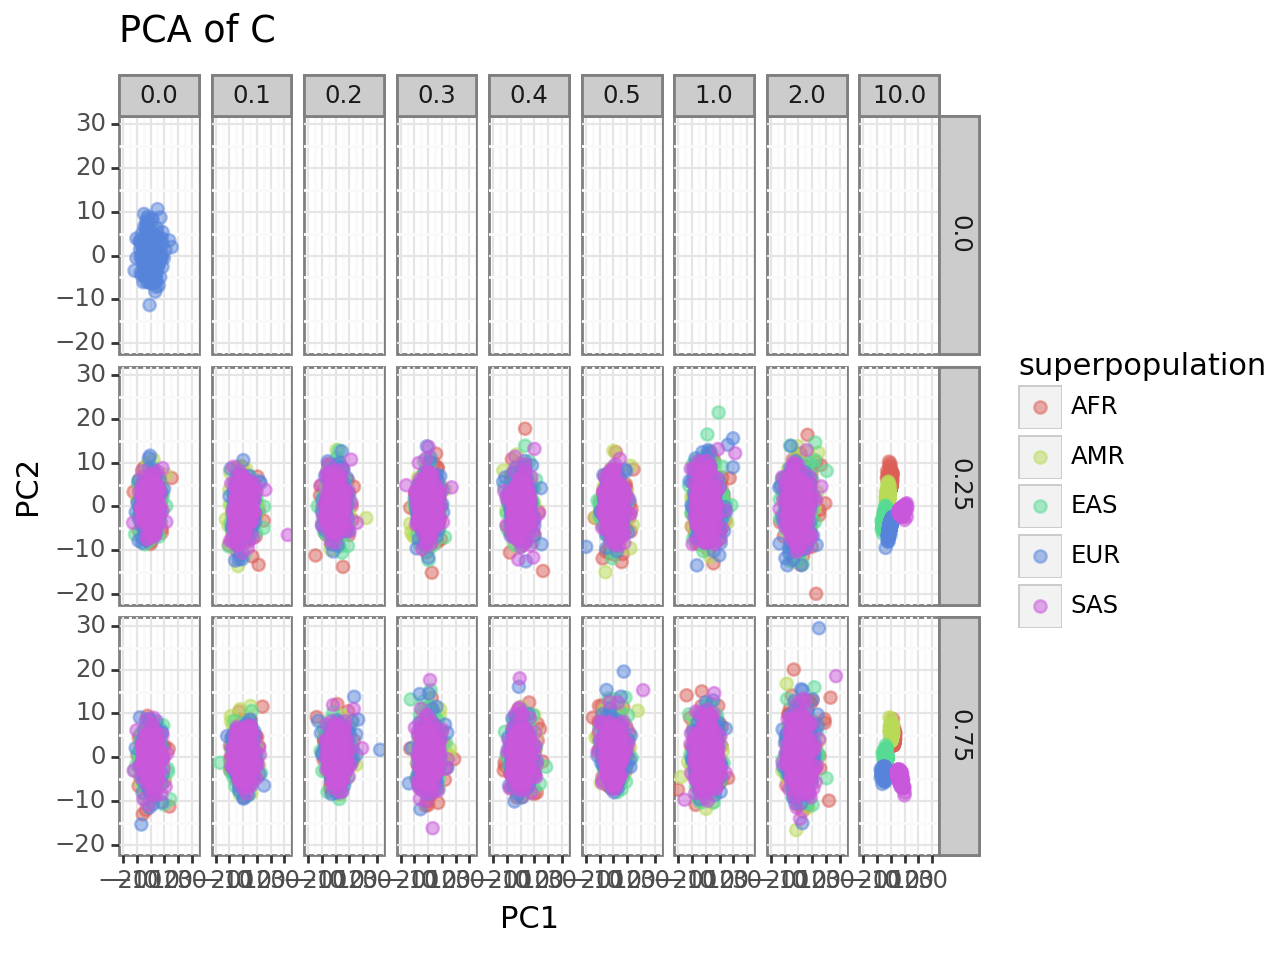

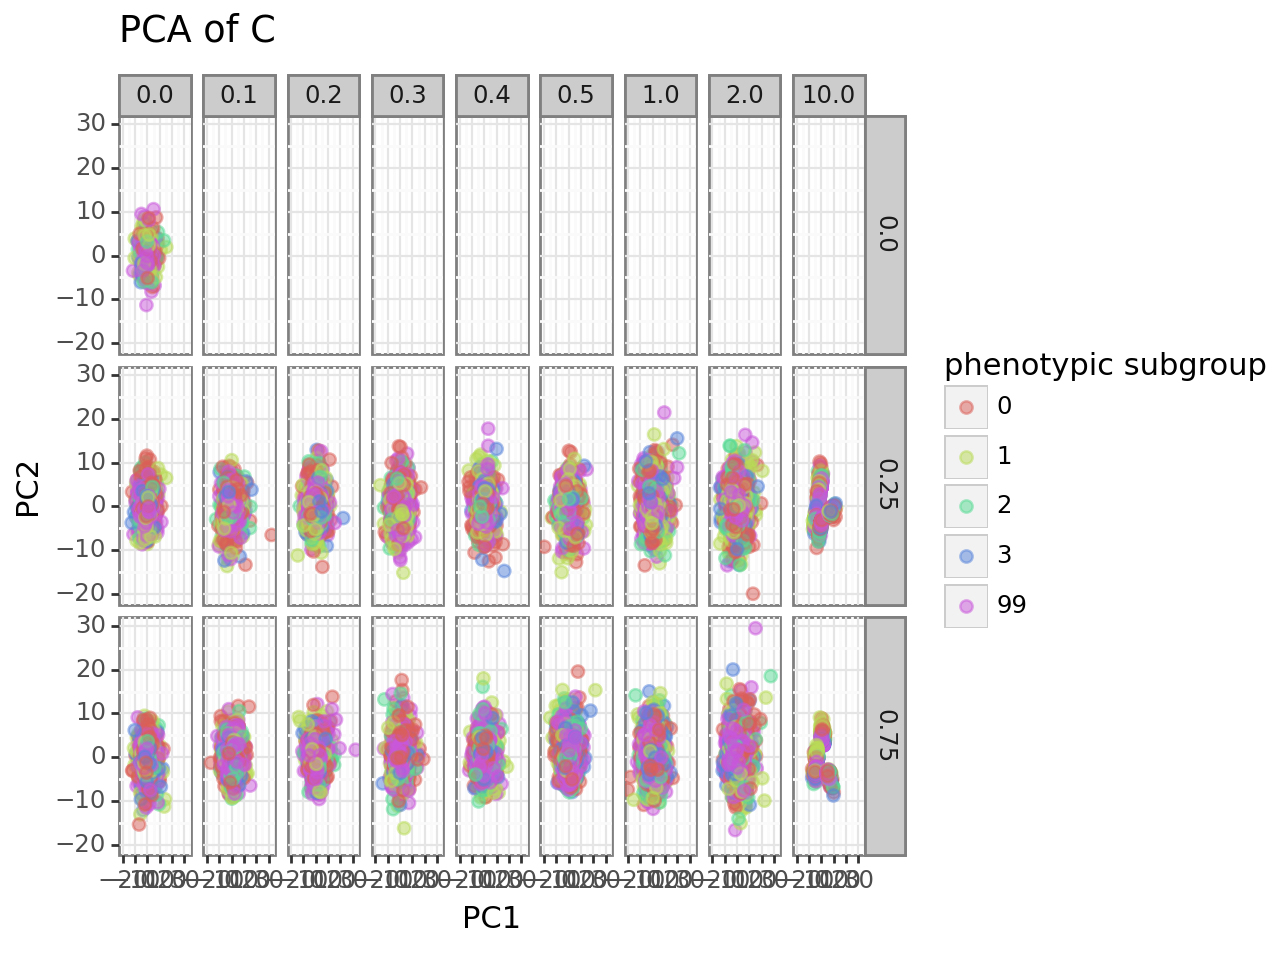

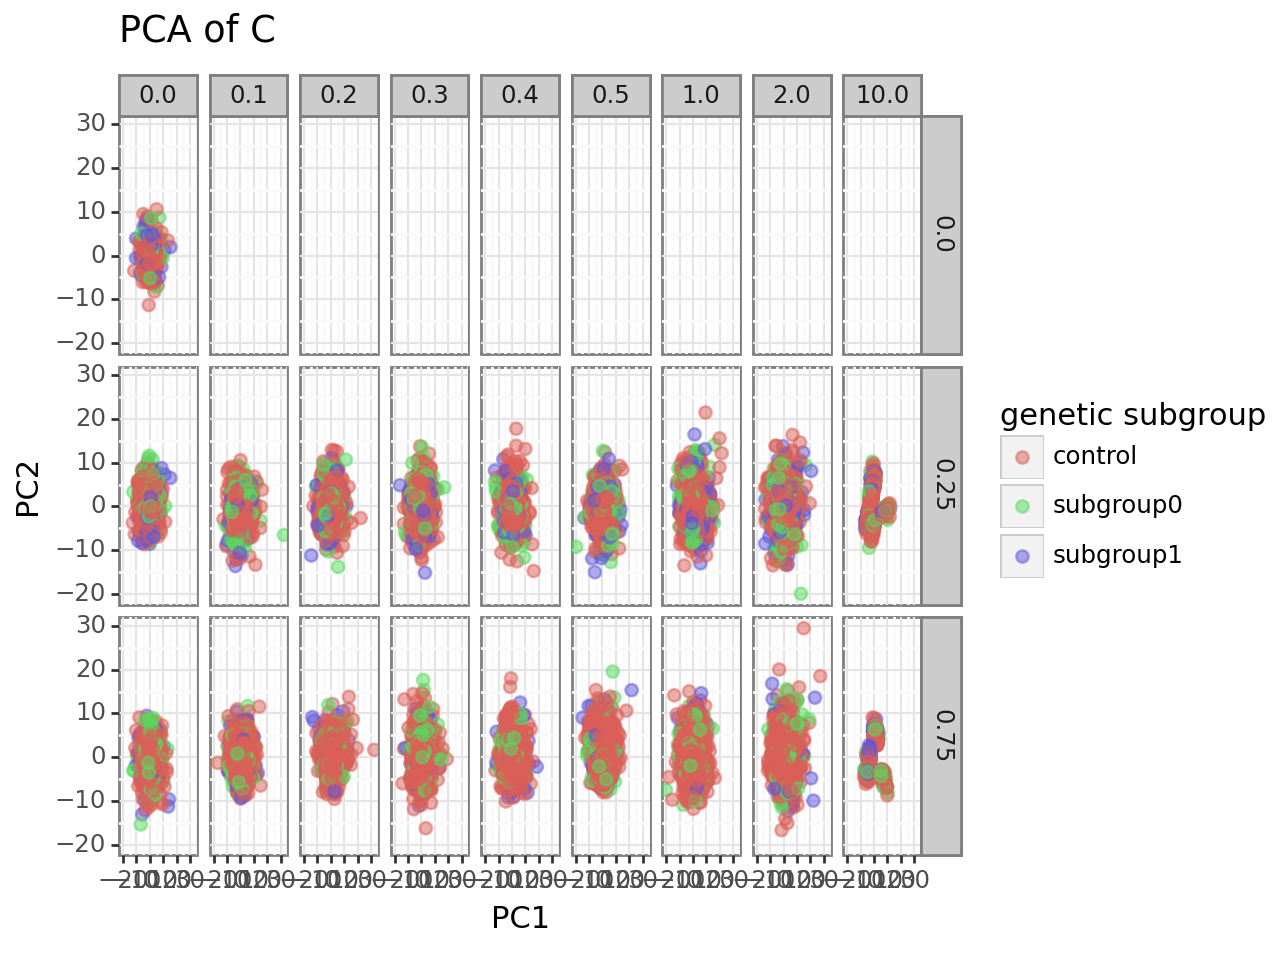


-----
1


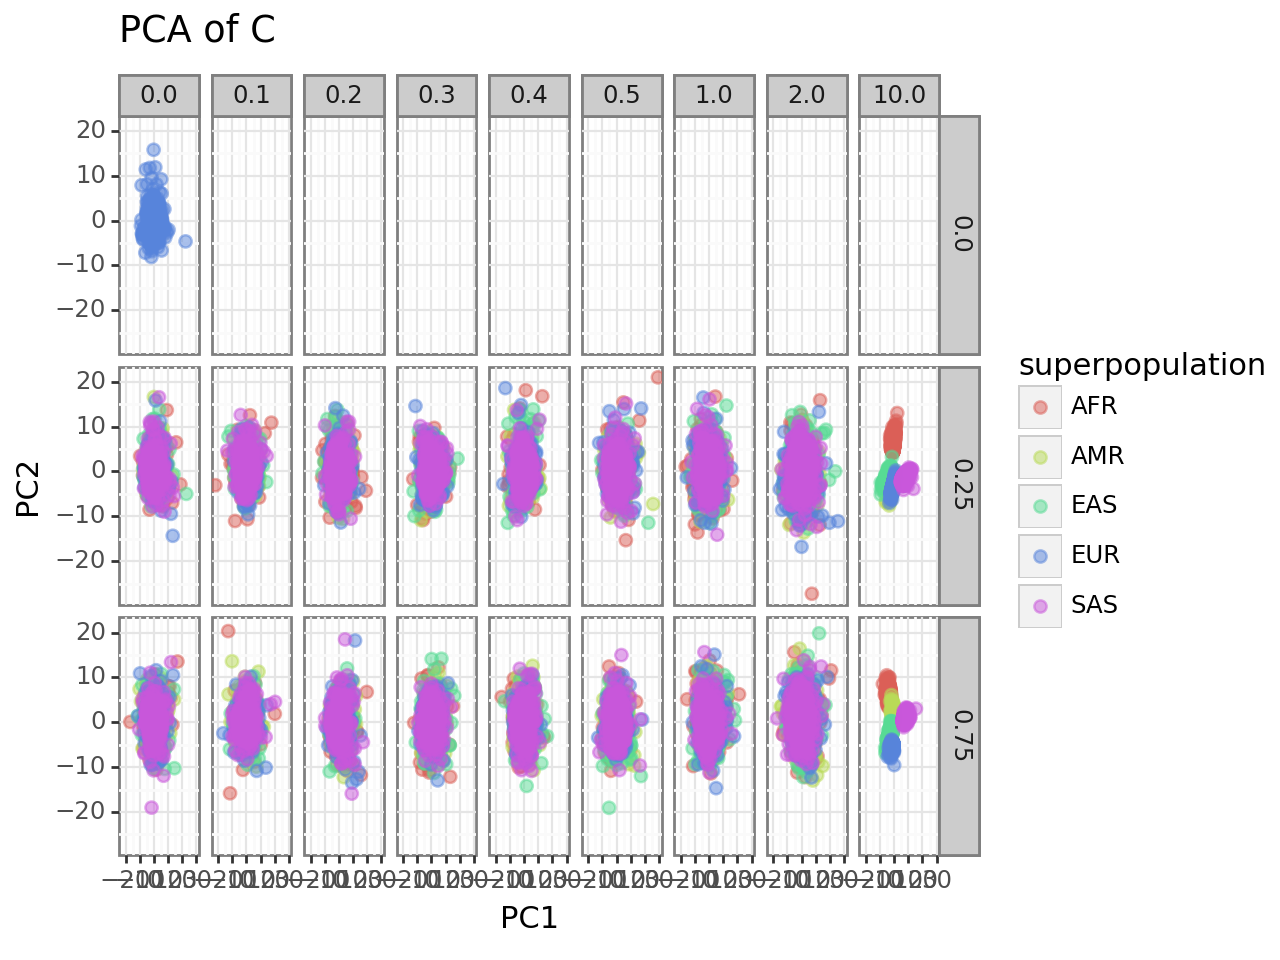

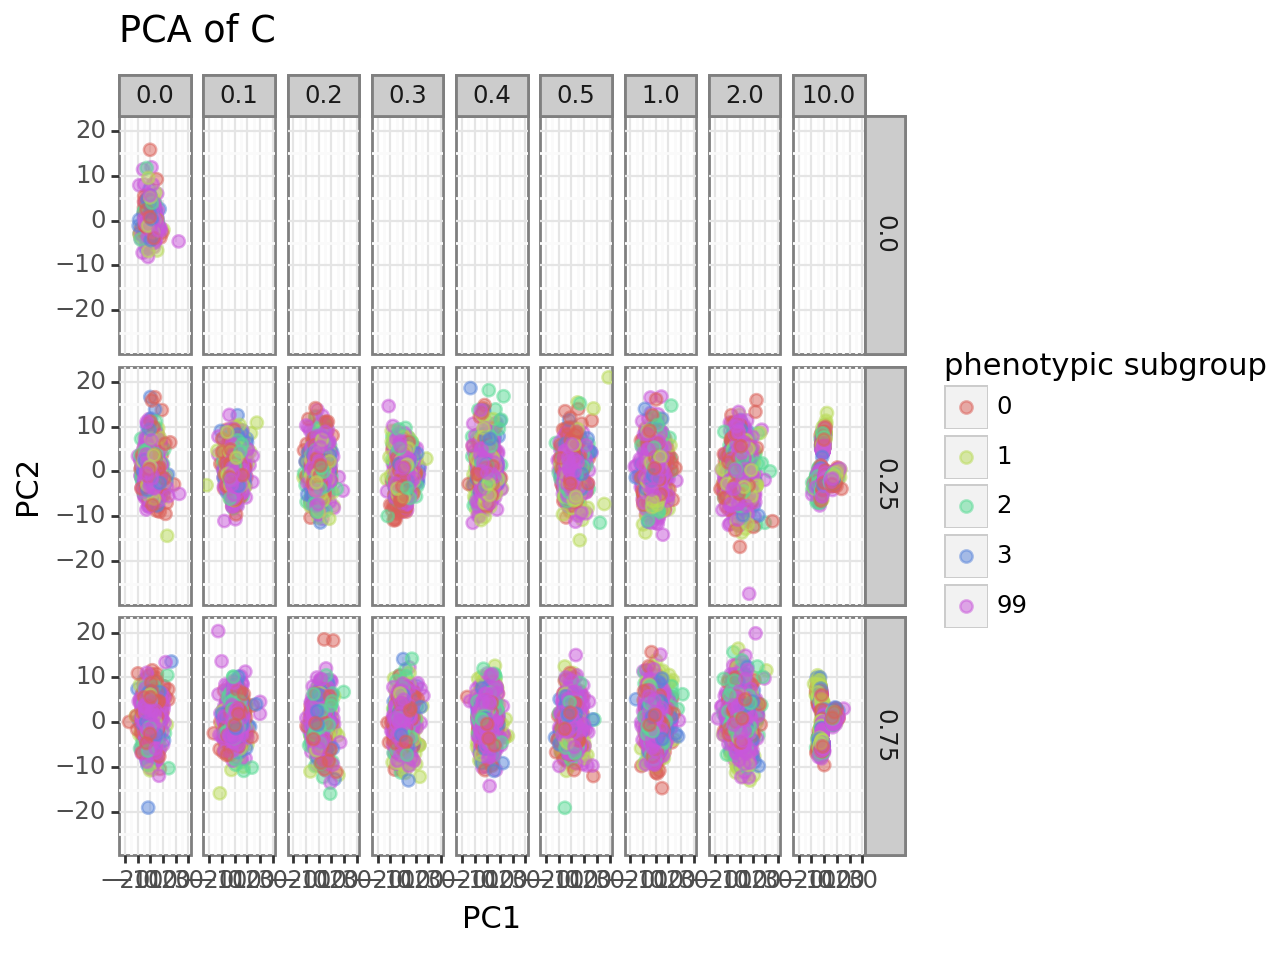

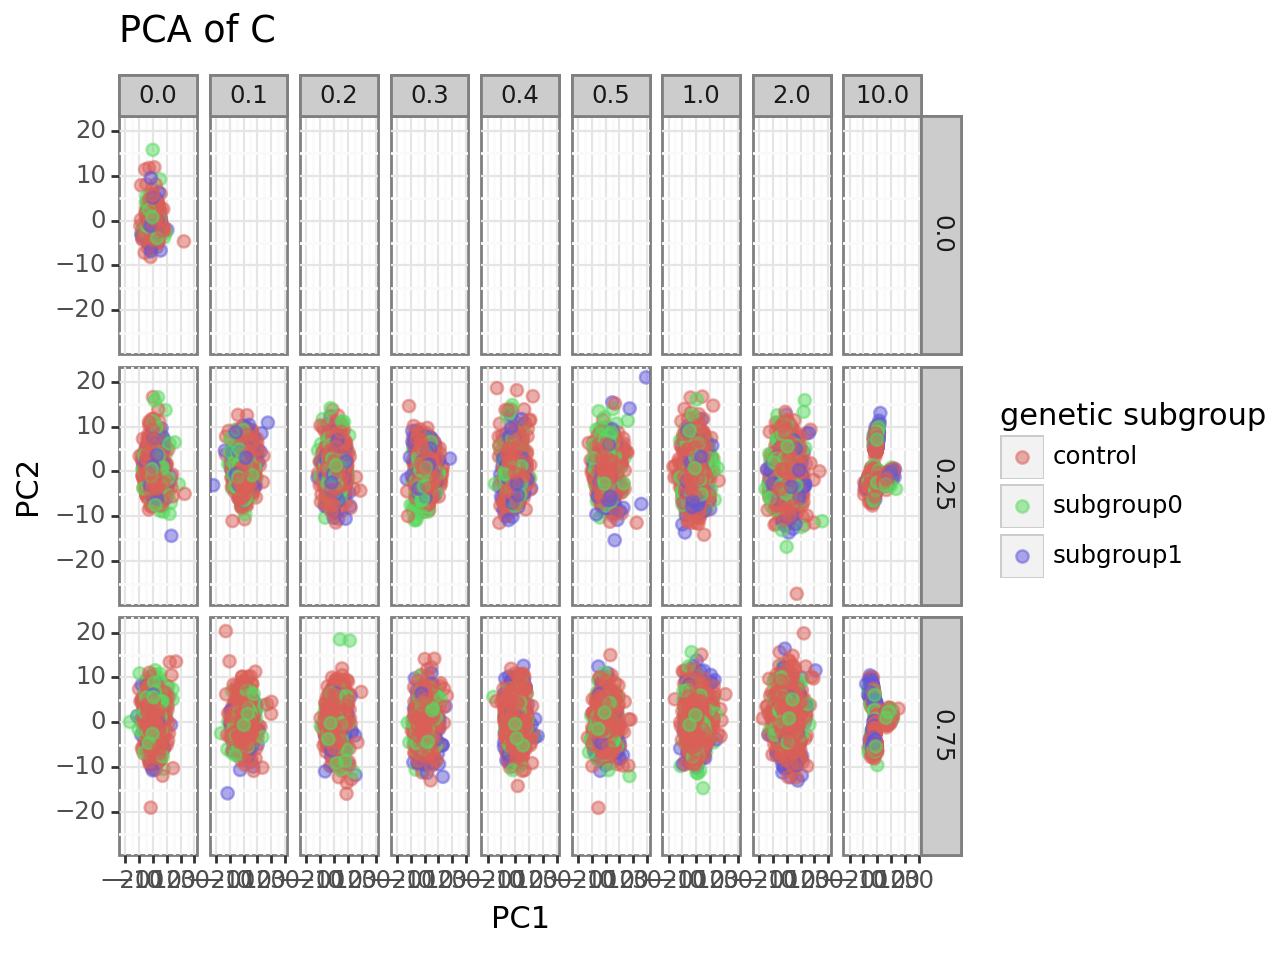


-----


In [8]:
c_ps_list = [0,0.1,0.2,0.3,0.4,0.5,1,2,10]
g_ps_list = [0,0.25,0.75]
e_list = [0.4,0.6,0.8,1]
for dataset in [0]:
    print(dataset)
    #superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=0.25, dataset=dataset,matrix_name='C',type='superpopulation')
    for e in e_list:
        print(e)
        superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=e, dataset=dataset,matrix_name='C',type='superpopulation')
        superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=e, dataset=dataset,matrix_name='C',type='phenotypic subgroup')
        superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=e, dataset=dataset,matrix_name='C',type='genetic subgroup')
        print('-----')
        # superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=e, dataset=dataset,matrix_name='G',type='superpopulation')
        # superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=e, dataset=dataset,matrix_name='G',type='phenotypic subgroup')
        # superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=e, dataset=dataset,matrix_name='G',type='genetic subgroup')
        # print('******')
    # superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=0.5, dataset=dataset,matrix_name='C',type='phenotypic subgroup')
    # superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=0.75, dataset=dataset,matrix_name='C',type='phenotypic subgroup')
    # superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=1, dataset=dataset,matrix_name='C',type='phenotypic subgroup')
    #superpop_matrix_pca(g_ps_list=g_ps_list,c_ps_list=c_ps_list, e=1, dataset=dataset,matrix_name='C',type='phenotypic subgroup',regressed=True)

In [10]:
g = 1 # 10 linked markers # TODO: scale back up
e_list = [0.4,0.6,0.8,1]
g_ps_list = [0,0.25,0.75]
c_ps_list = [0,0.1,0.2,0.3,0.4,0.5,1]
dataset_list = range(11) # 21 random datasets for each combination # TODO: make 21
combos = [(e, g_ps, c_ps, d) for e, g_ps in product(e_list, g_ps_list) for c_ps in ([0] if g_ps == 0 else c_ps_list) for d in dataset_list]    
num_markers = 10
for (e, g_ps, c_ps, d) in combos:
    output_suffix = sim_functions.get_output_file_suffix(g_ps=g_ps, c_ps=c_ps, e=e, dataset=dataset)
    C_path = f'{sim_output_dir}/C_{output_suffix}.npy'
    C = np.load(C_path)
    with open(f"{sim_output_dir}/simulation_metadata_{output_suffix}.pkl", "rb") as f:
        simulation_metadata = pickle.load(f)
    fam_df = pd.read_csv(f'{bfile_path}.fam',sep='\s+',header=None) 
    fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
    iid_index = fam_df[fam_df['IID'].isin(simulation_metadata['iid_order'])].index # some samples removed due to overlap btwn subgroups, need correct length
    # read in G with num_markers
    G_path = f'{sim_output_dir}/G_{output_suffix}.raw'
    G = np.loadtxt(G_path,  usecols=range(6, num_markers+6), dtype=np.int64, skiprows=1)
    fam_df_subset = pd.read_csv(f'{sim_output_dir}/G_{output_suffix}.fam',sep='\s+',header=None)
    fam_df_subset.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
    assert set(fam_df_subset['IID'].values).issubset(set(fam_df['IID'].values))
    # Note: first two columns are genetically-informed subgroups by construction
    W_true = simulation_metadata['phenotypic_subgroups'].set_index('IID')[['subgroup0','subgroup1']].to_numpy('float64')
    ground_truth = {"W":W_true}

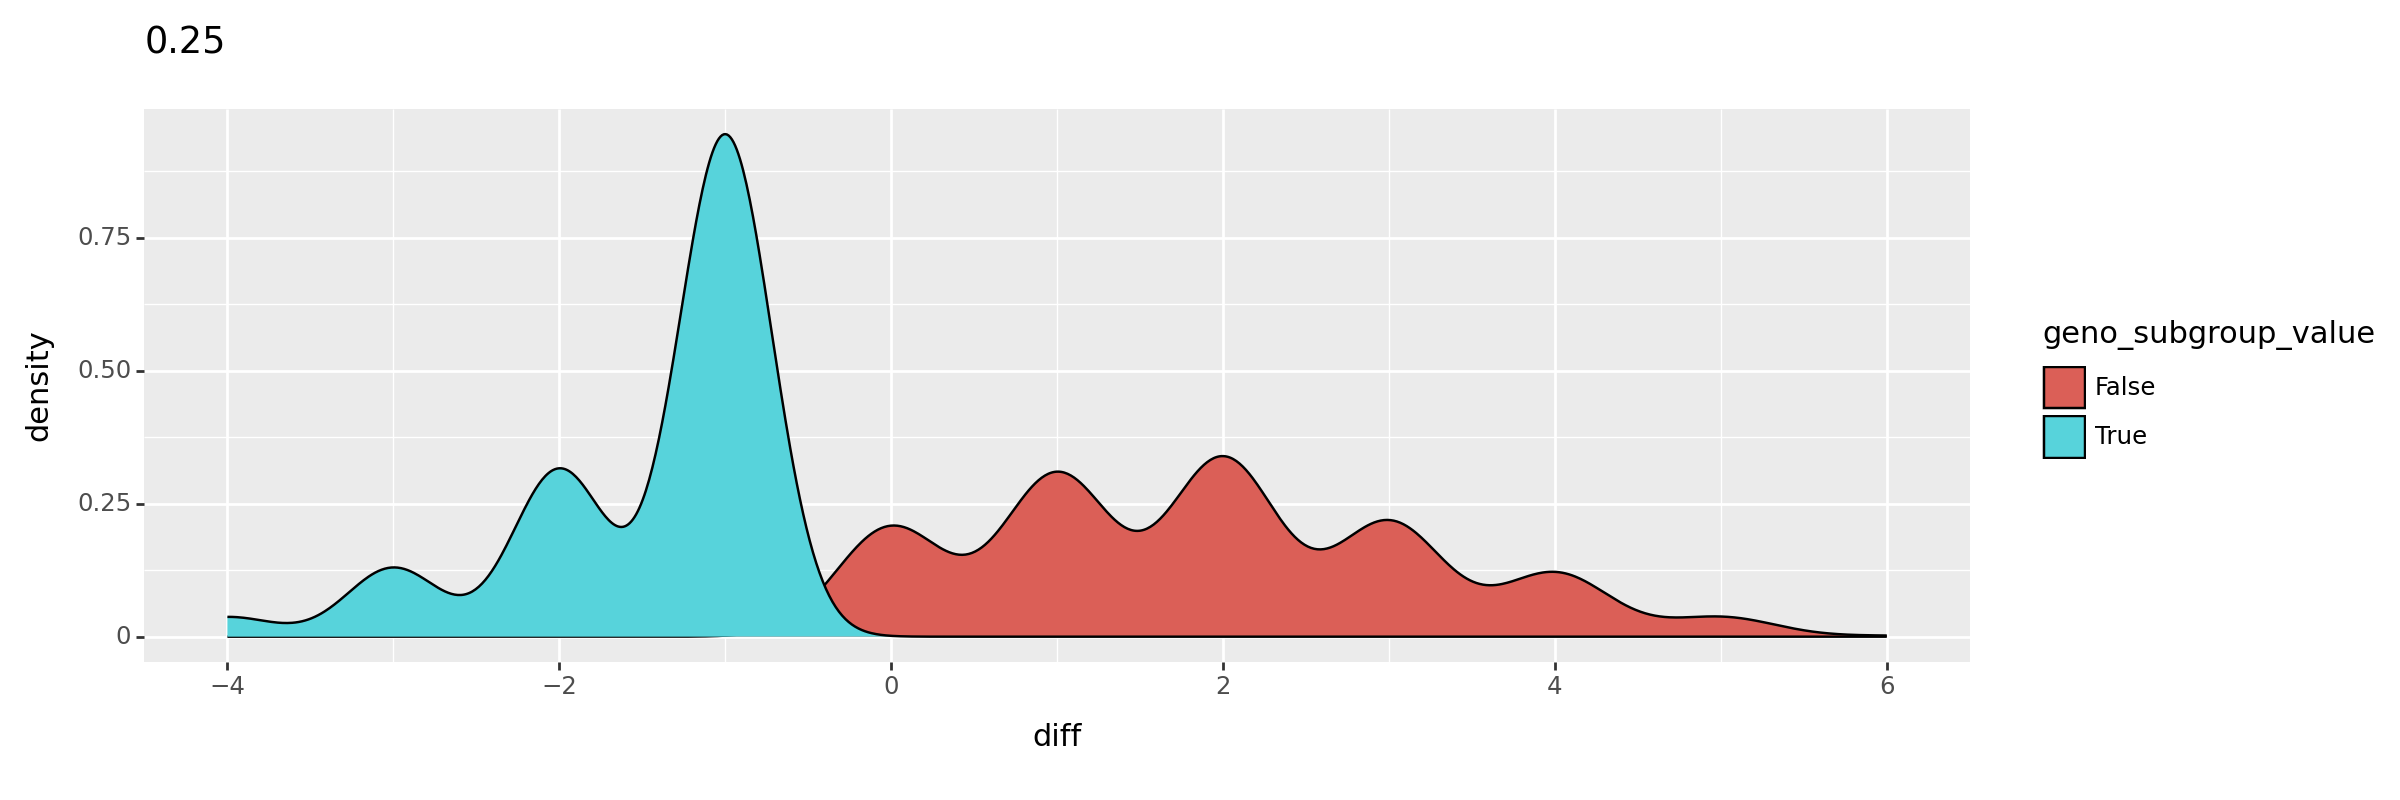

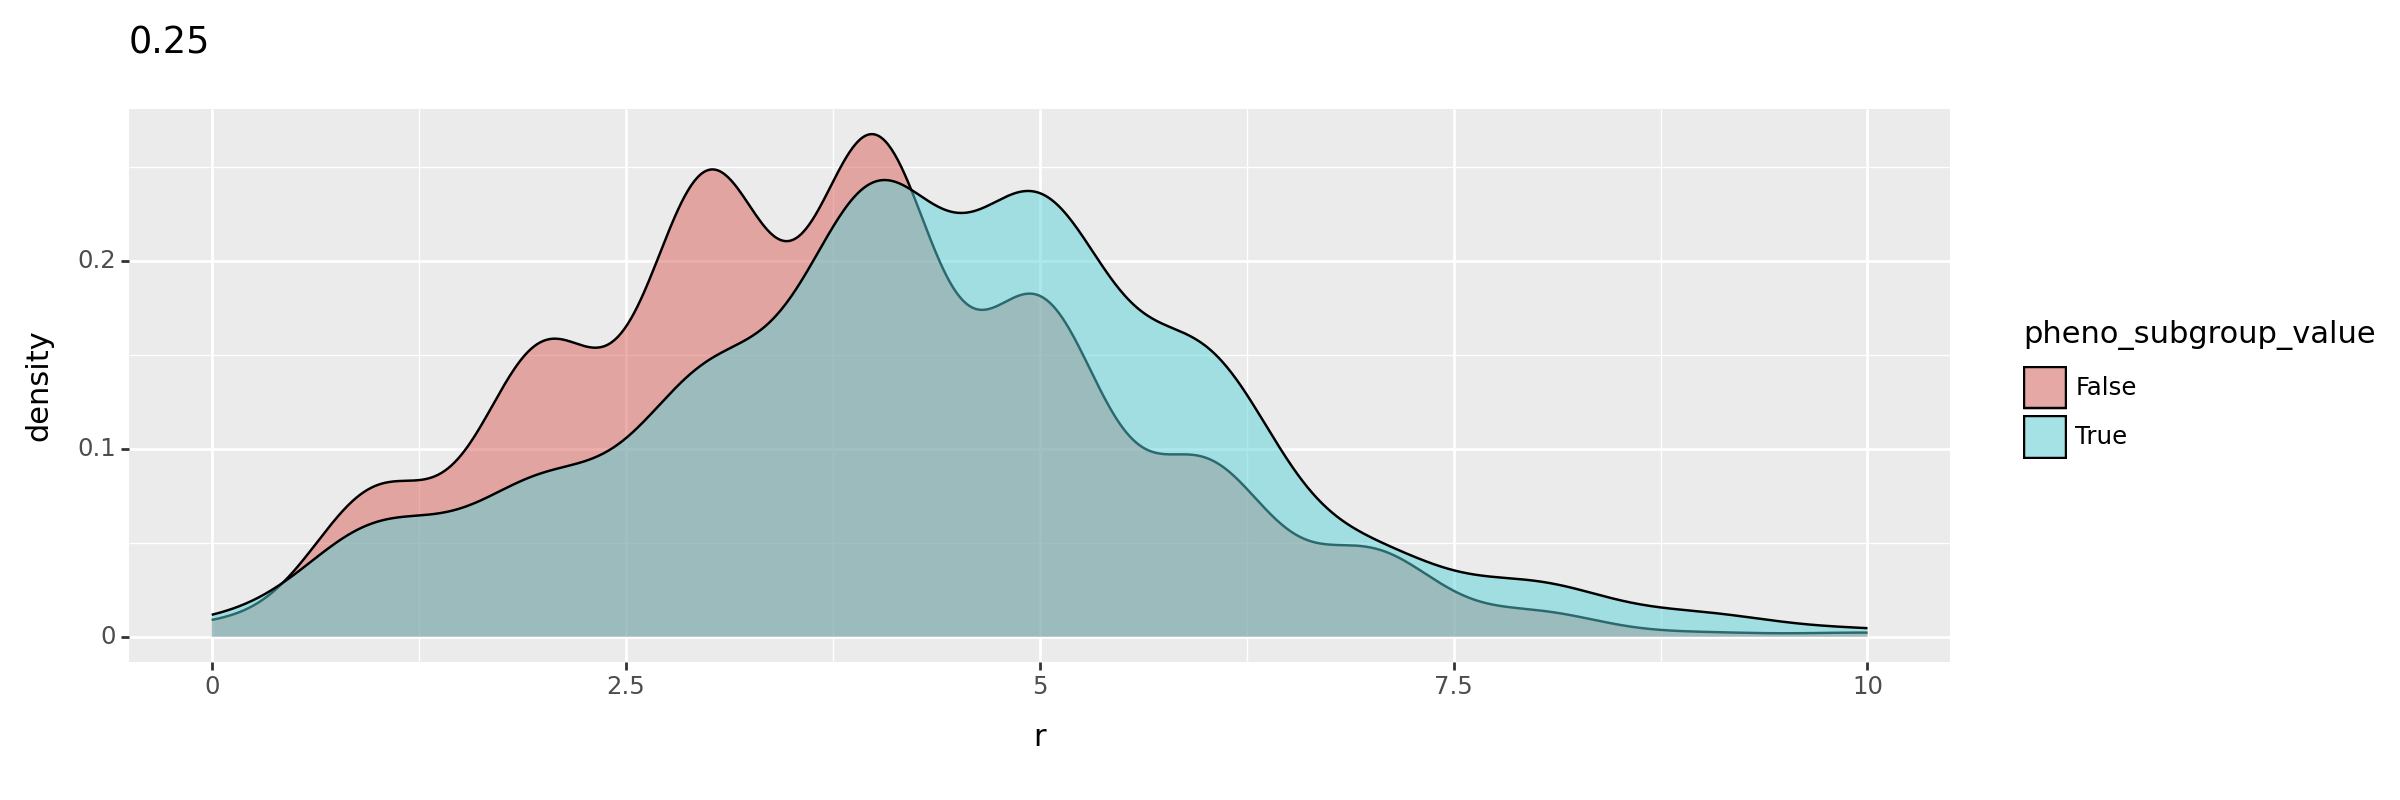

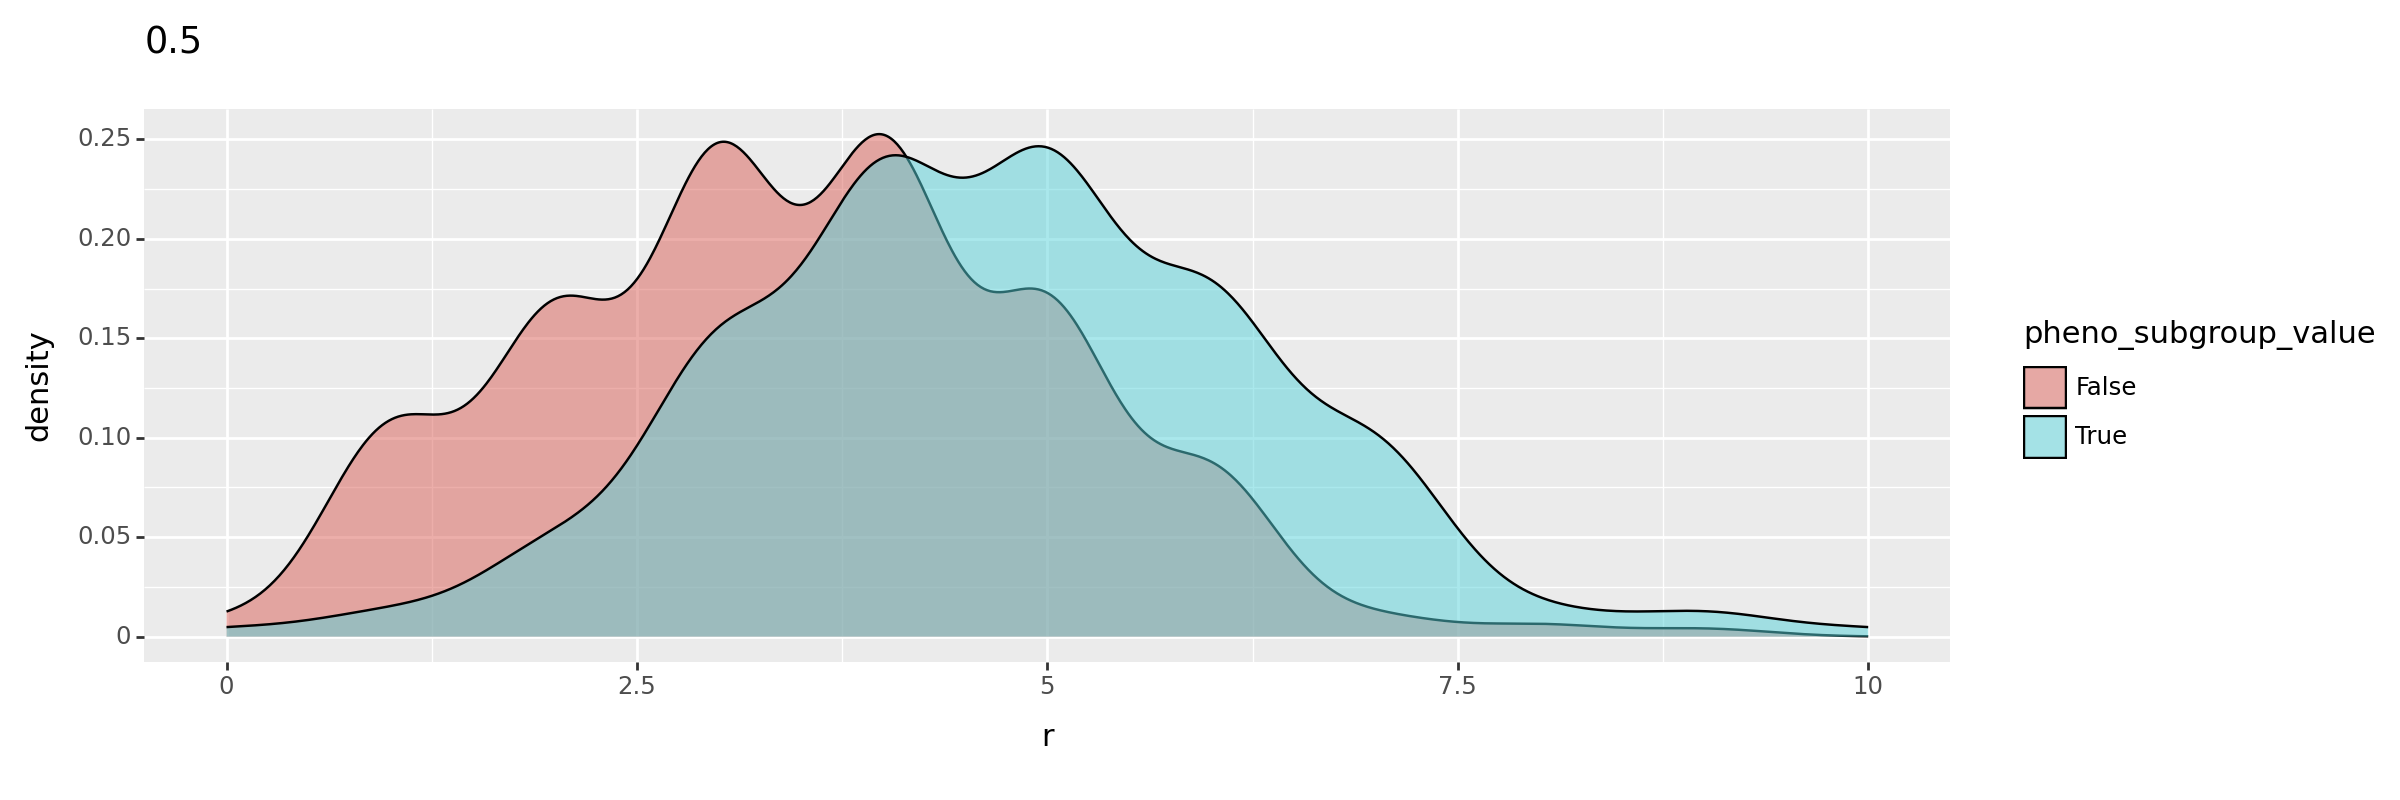

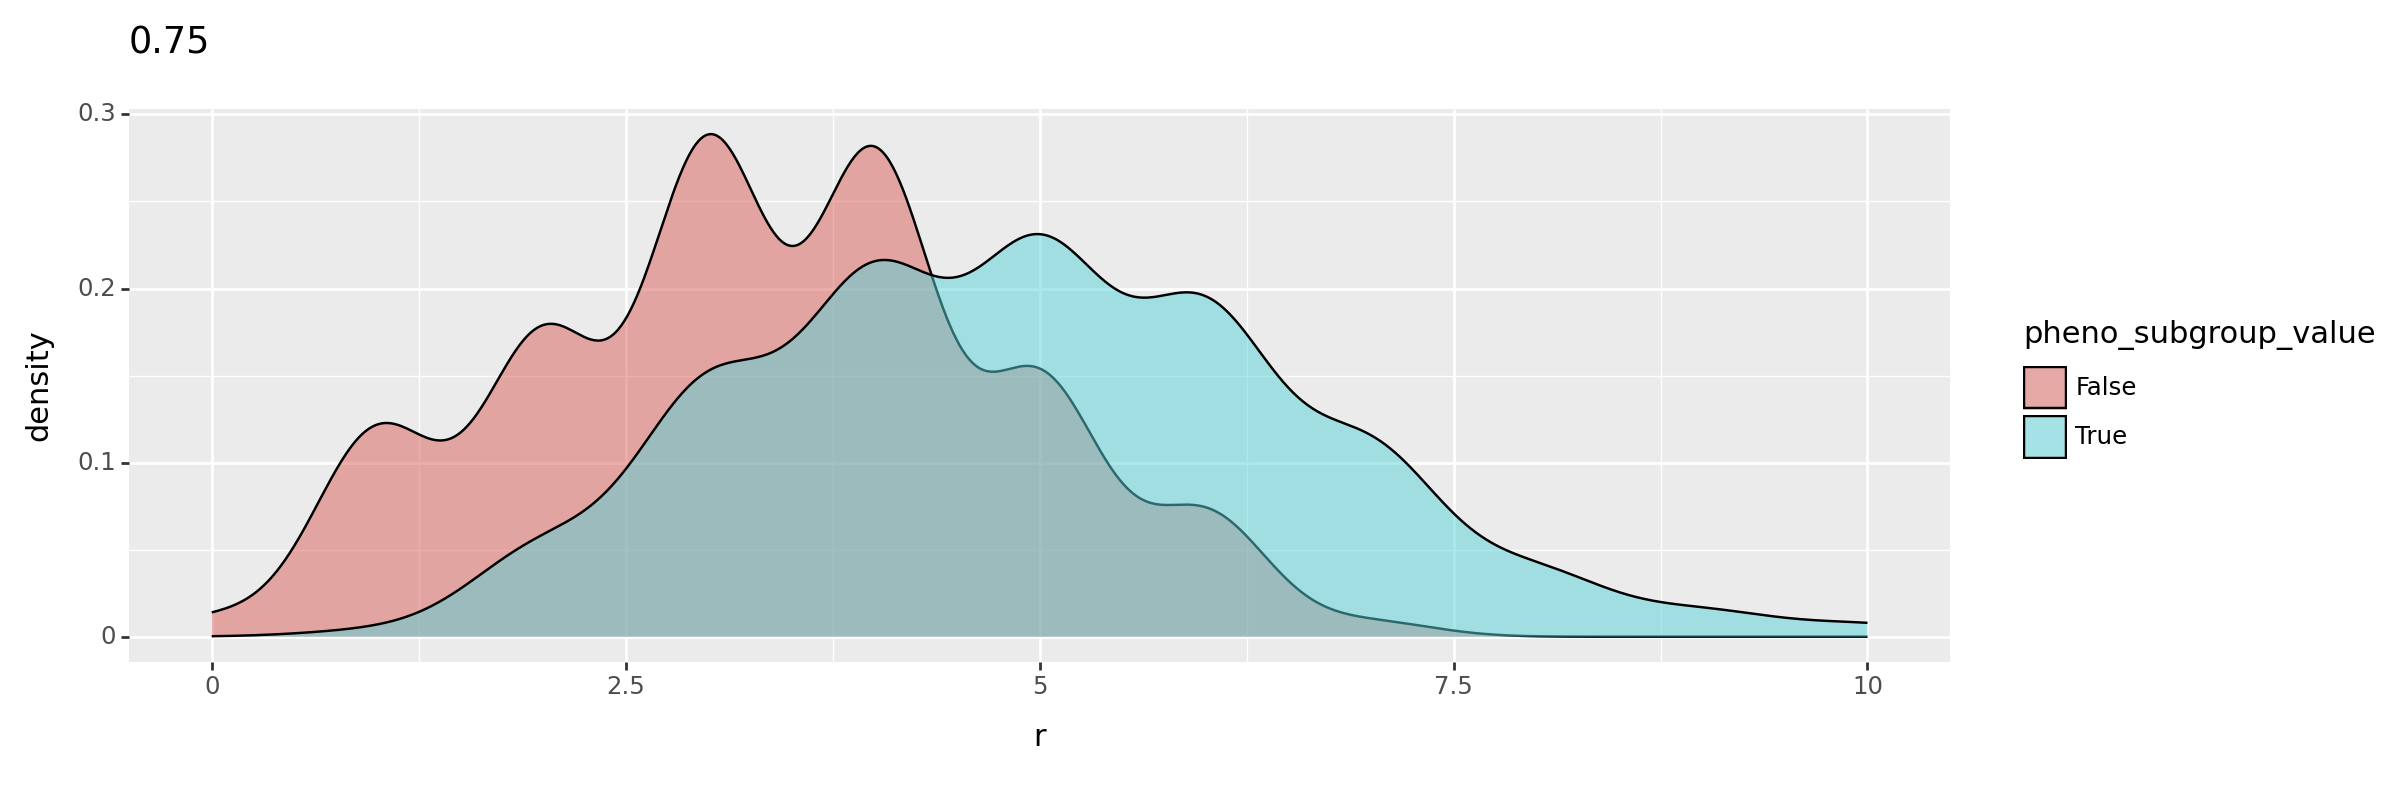

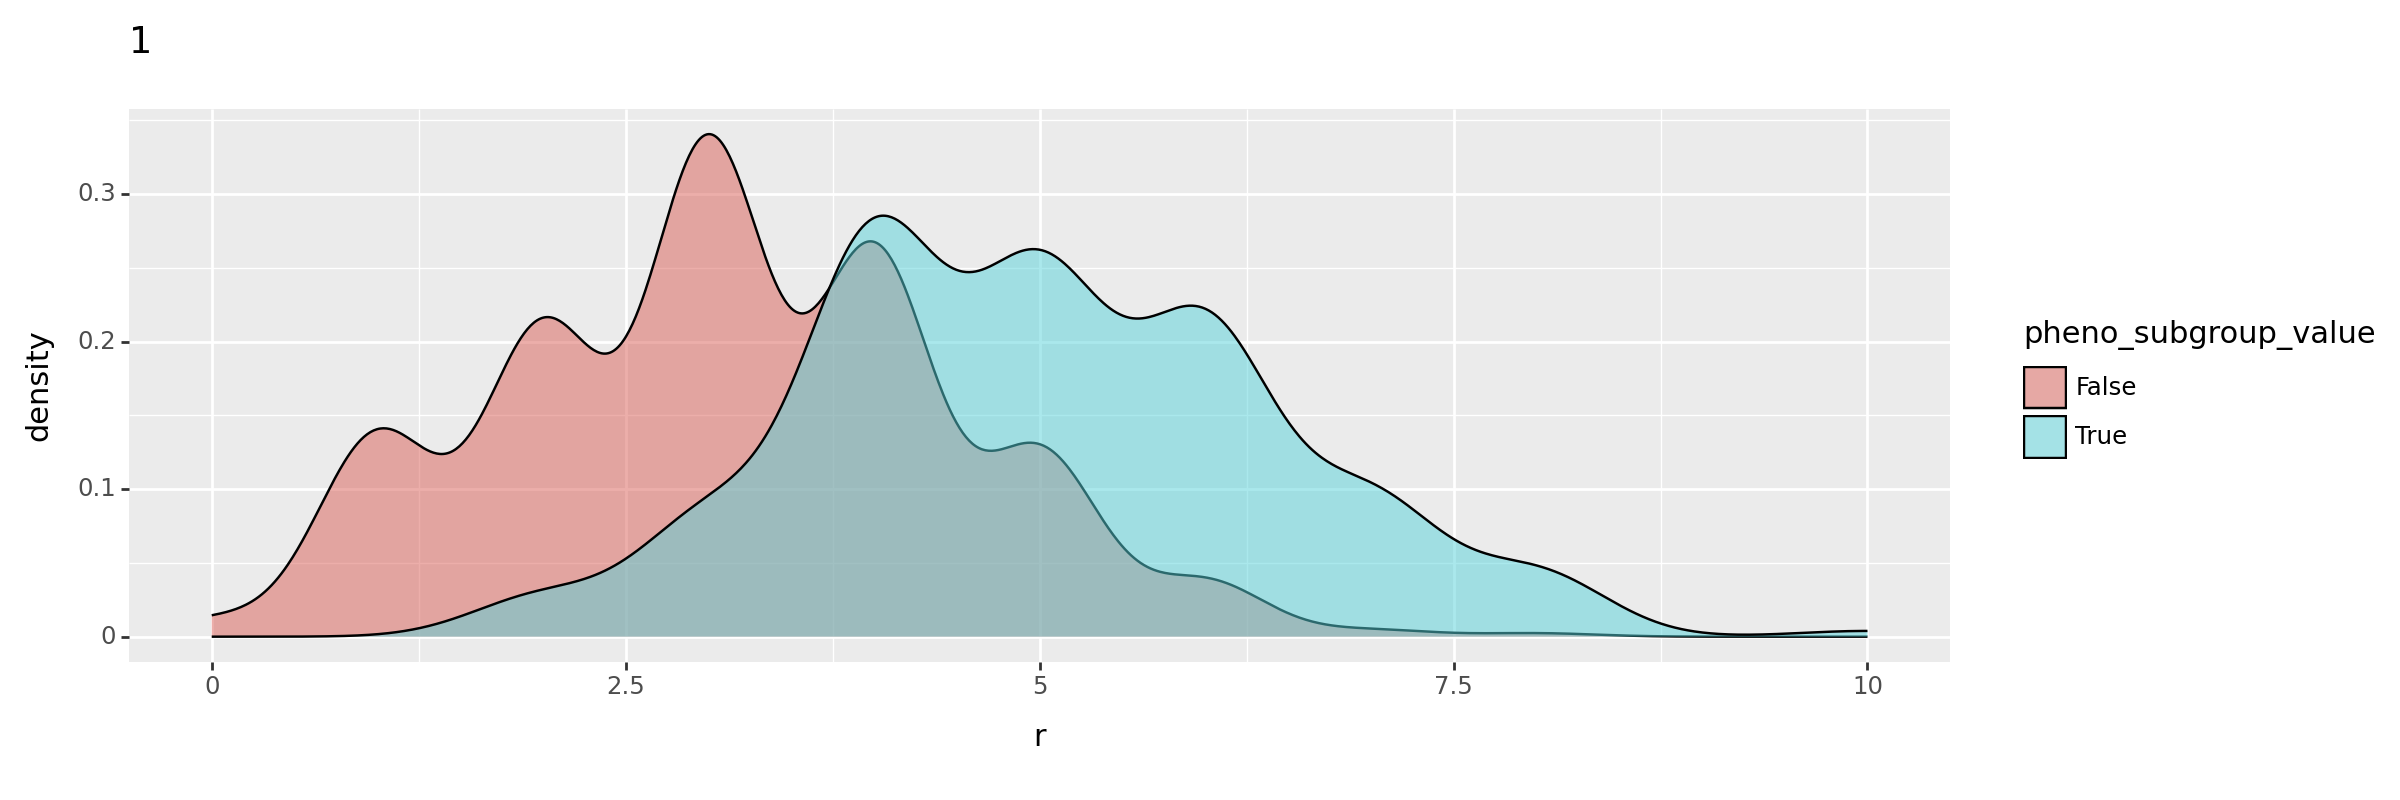

In [292]:
g_ps = 0
c_ps = 0
num_markers=100
from scipy.stats import norm
from scipy.stats import ks_2samp, wasserstein_distance, entropy

rows = []
rows_columns = ['e','dataset','ks']
for e in e_list:
    rv_coef_means = []
    for dataset in dataset_list:
        output_suffix = sim_functions.get_output_file_suffix(g_ps=g_ps, c_ps=c_ps, e=e, dataset=dataset)
        with open(f"{sim_output_dir}/simulation_metadata_{output_suffix}.pkl", "rb") as f:
                    simulation_metadata = pickle.load(f)
        if e==0.25 and dataset==0:
            baseline_markers_assoc=simulation_metadata['markers_assoc'].copy()
        assert set(baseline_markers_assoc[0])==set(simulation_metadata['markers_assoc'][0])
        assert set(baseline_markers_assoc[1])==set(simulation_metadata['markers_assoc'][1])
        # try G and C row-wise correlation
        G = np.loadtxt(f'{sim_output_dir}/G_{output_suffix}.raw',  usecols=range(6, num_markers+6), dtype=np.int64, skiprows=1)
        C = np.load(f'{sim_output_dir}/C_{output_suffix}.npy')
        # get iids in subgroup
        fam_df = pd.read_csv(f'{sim_output_dir}/G_{output_suffix}.fam',sep='\s+',header=None) 
        fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
        phenotypic_subgroups = simulation_metadata['phenotypic_subgroups'].copy()
        phenotypic_subgroups = phenotypic_subgroups[(phenotypic_subgroups['phenotypic_subgroup'].isin([0,1]))].copy()
        phenotypic_subgroups['r'] = phenotypic_subgroups['r'].astype(int)
        phenotypic_subgroups = phenotypic_subgroups.sort_values('IID', key=lambda x: pd.Categorical(x, categories=fam_df['IID'].values, ordered=True))
        iids = phenotypic_subgroups[phenotypic_subgroups['subgroup']]['IID'].unique().tolist()
        genetic_subgroups = simulation_metadata['genetic_subgroups'].copy()
        both_subgroups = phenotypic_subgroups.rename(columns={'subgroup':'pheno_subgroup_value'}).merge(genetic_subgroups[['IID','genetic_subgroup','subgroup']].rename(columns={'subgroup':'geno_subgroup_value'}),how='inner',on=['IID'])
        both_subgroups = both_subgroups[both_subgroups['phenotypic_subgroup']==both_subgroups['genetic_subgroup']].copy()
        iid_index = fam_df[fam_df['IID'].isin(iids)].index # some samples removed due to overlap btwn subgroups, need correct length
        sample_wise_corr = []
        for i in iid_index:
            sample_wise_corr.append(np.corrcoef(G[i,:], C[i,:])[0, 1])

        if dataset==0:
            # print((ggplot(phenotypic_subgroups, aes(x='r', fill='subgroup')) +
            # geom_histogram(binwidth=1, color='black')+labs(title=e)))
            cut_points = both_subgroups.groupby('genetic_subgroup')['r'].quantile(0.8).to_dict()
            both_subgroups['abs_diff'] = both_subgroups.apply(lambda x: np.abs(cut_points[x['genetic_subgroup']]-x['r']),axis=1)
            both_subgroups['diff'] = both_subgroups.apply(lambda x: cut_points[x['genetic_subgroup']]-x['r'],axis=1)
            both_subgroups['col_z'] = (both_subgroups['diff'] - both_subgroups['diff'].mean()) / both_subgroups['diff'].std()
            if e==0.25:
                print((ggplot(both_subgroups, aes(x='diff', fill='geno_subgroup_value')) +
                geom_density(color='black')+labs(title=e)+theme(figure_size=(12,4))))
            both_subgroups['lhs'] = both_subgroups.apply(lambda x:(1/1)*(x['col_z'])*e, axis=1)
            print((ggplot(both_subgroups, aes(x='r', fill='pheno_subgroup_value')) +
            geom_density(color='black',alpha=0.5)+labs(title=e)+theme(figure_size=(12,4))))

            # # get prob
            # both_subgroups['p'] = both_subgroups['lhs'].apply(lambda x: norm.sf(x))
            # print((ggplot(both_subgroups, aes(x='p', fill='geno_subgroup_value')) +
            # geom_density(color='black')+labs(title=e)+theme(figure_size=(12,4))))

        a = both_subgroups[both_subgroups['pheno_subgroup_value']==True]['r'].values.tolist()
        b = both_subgroups[both_subgroups['pheno_subgroup_value']==False]['r'].values.tolist()
        rows.append([e,dataset,ks_2samp(a, b).statistic])
    #print(f'e {e}, mean sample-wise corr: {np.mean(sample_wise_corr)}; ks {ks_2samp(a, b).statistic}')
df = pd.DataFrame(rows,columns=rows_columns)

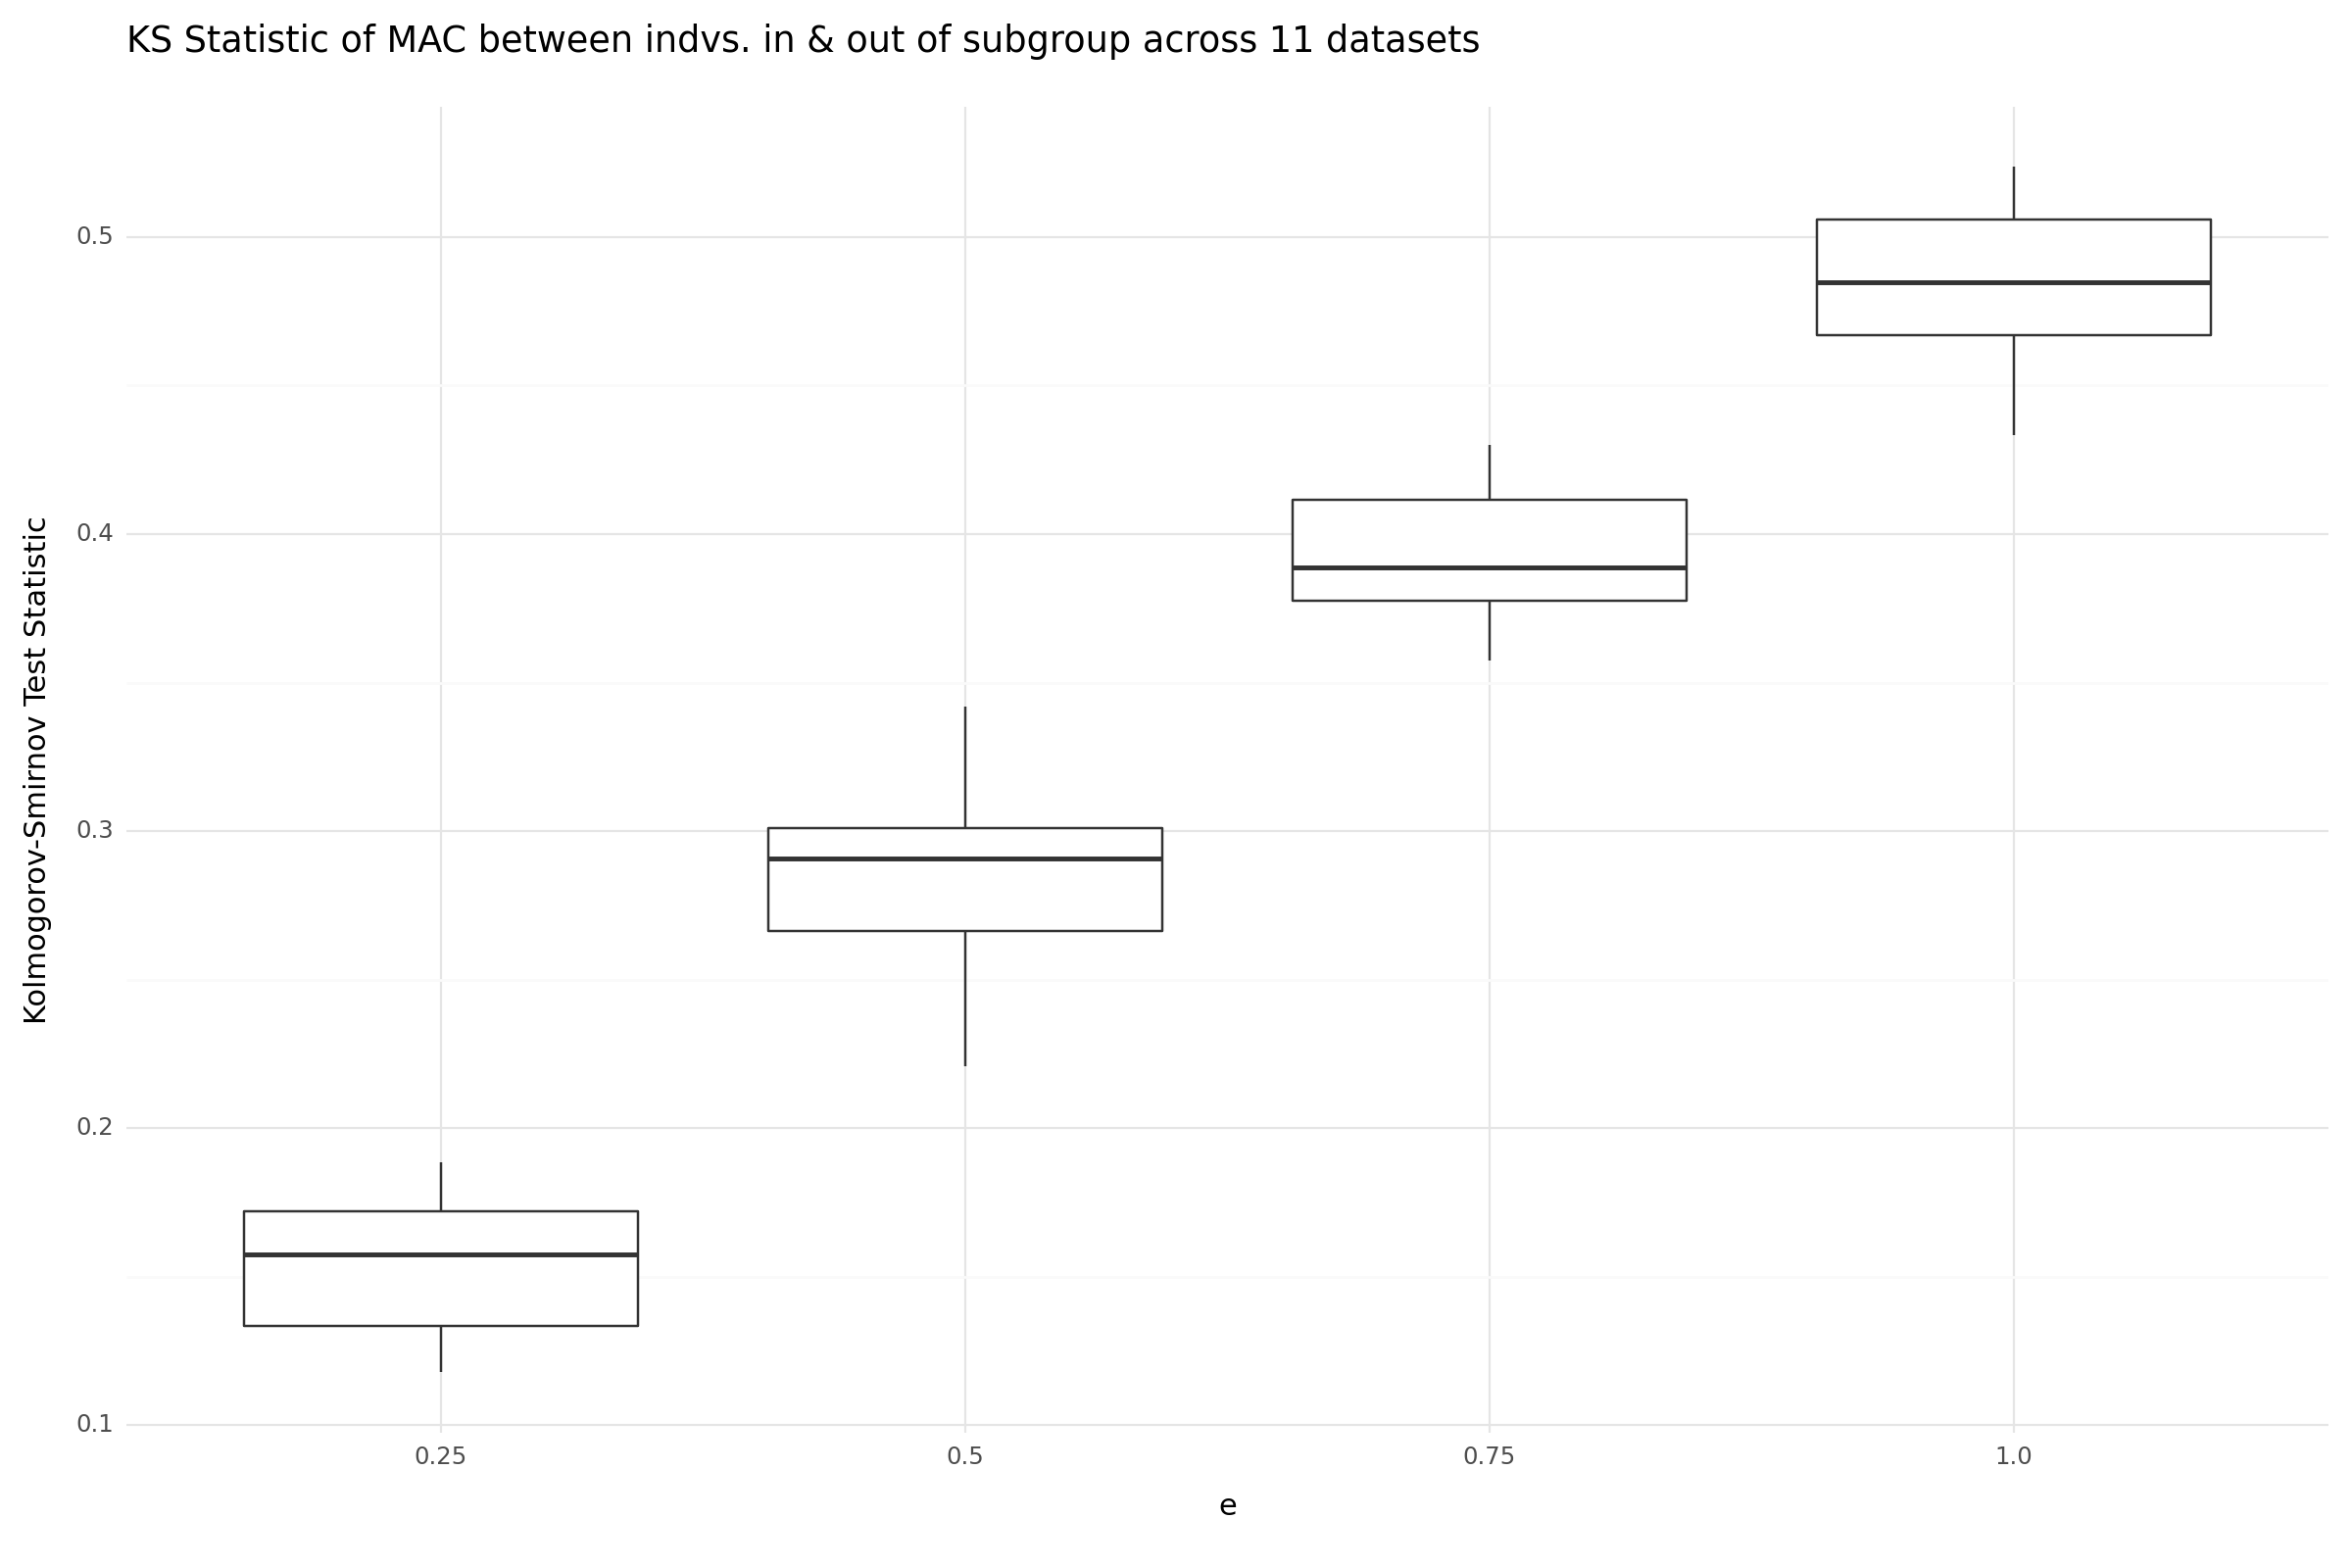

In [293]:
df
dodge = position_dodge(width=0.35)
p = (
ggplot(df, aes(x="factor(e)", y="ks"))
+ geom_boxplot()
+ labs(x="e", y="Kolmogorov-Smirnov Test Statistic", title='KS Statistic of MAC between indvs. in & out of subgroup across 11 datasets')
+ theme_minimal()
+ theme(figure_size=(12,8))
)
print(p)


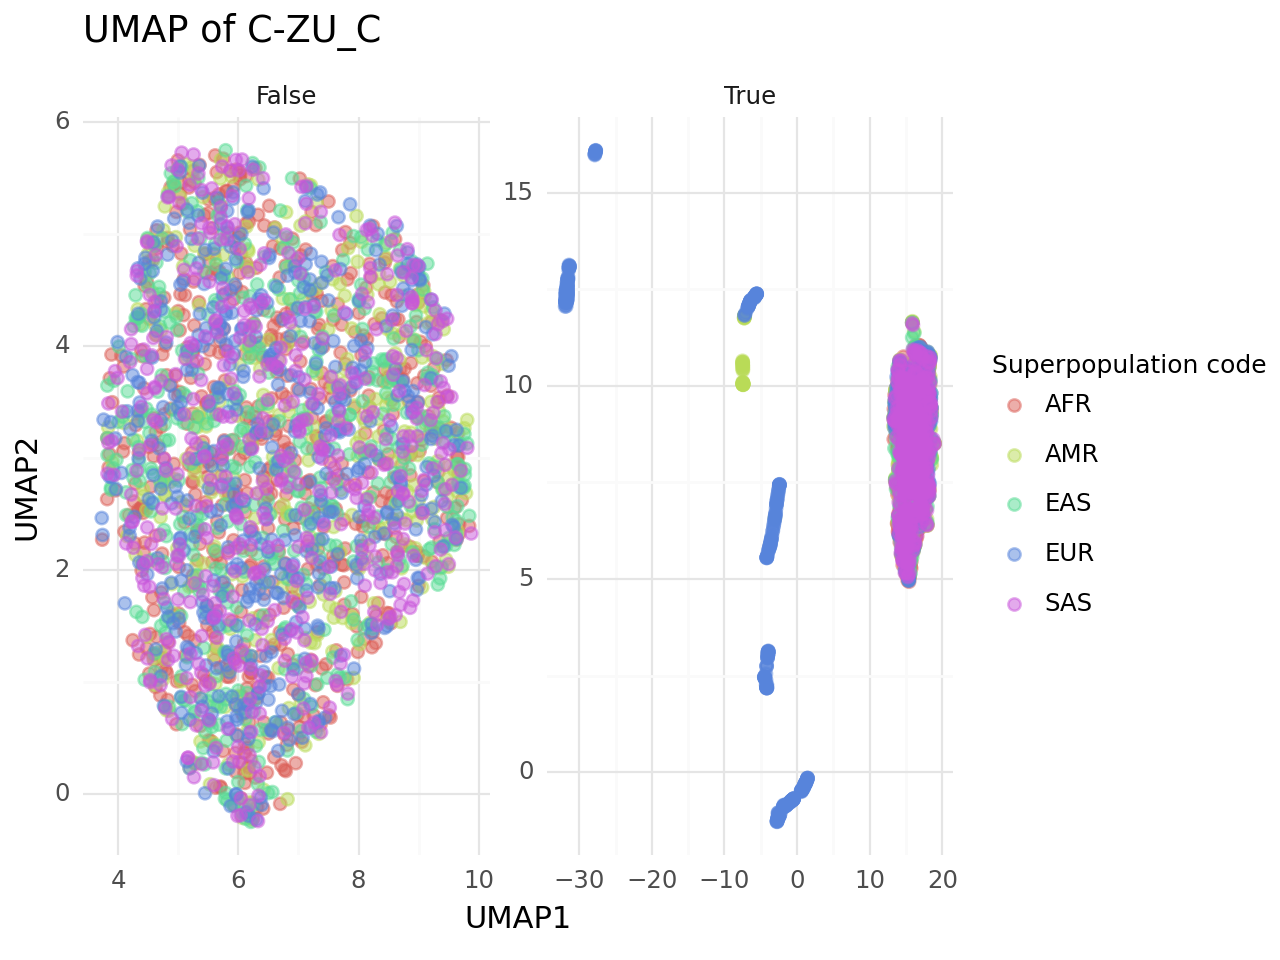

<Figure Size: (640 x 480)>

In [32]:
# umap of G-ZUG
# umap of G with superpopulation label & also genetic subgroup label
ps_list = [True,False]
e = 1
dataset=0
g=10
num_markers = 100
rank = 3
import algorithms.SCoNE as SCoNE
plot_dfs = []
for ps in ps_list:
    admixture = pd.read_csv(f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5.Q',sep='\s+',header=None)
    fam_df = pd.read_csv(f'{sim_output_dir}/G.fam',sep='\s+',header=None)
    fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
    admixture['IID'] = fam_df['IID'].values
    igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath, bfile_path=f'{sim_output_dir}/G')
    igsr_samples['Sex'] = igsr_samples['Sex'].map({'female': 0, 'male': 1})

    Z_df = admixture.merge(igsr_samples[['IID']], on='IID',how='inner') # not including covar Sex
    Z = Z_df[[i for i in Z_df.columns if i!='IID']].to_numpy()

    output_file_suffix = sim_functions.get_output_file_suffix(ps,e,dataset,g)
    with open(f"{sim_output_dir}/simulation_metadata_{output_file_suffix}.pkl", "rb") as f:
                simulation_metadata = pickle.load(f)
    phenotypic_subgroups = simulation_metadata['phenotypic_subgroups']
    iid_order = simulation_metadata['iid_order']
    fam_df = pd.read_csv(f'{sim_output_dir}/G_{sim_functions.get_output_file_suffix(ps,e,dataset,g)}.fam',sep='\s+',header=None)
    fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
    iid_index = fam_df[fam_df['IID'].isin(simulation_metadata['iid_order'])].index
    igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath, bfile_path=f'{sim_output_dir}/G')
    G = np.loadtxt(f'{sim_output_dir}/G_{sim_functions.get_output_file_suffix(ps,e,dataset,g)}.raw',  usecols=range(6, num_markers+6), dtype=np.int8, skiprows=1)
    C = np.load(f'{sim_output_dir}/C_{output_file_suffix}.npy')
    idx = all_runs.groupby(["run_name", "ps", "e", "g","dataset"])["total_loss"].idxmin()
    best = (
        all_runs.loc[idx, all_runs.columns]
        .sort_values(["experiment_id","run_name", "ps", "e", "g"])
        .reset_index(drop=True)
    )
    exp_id = best[(best['ps']==ps)&(best['e']==e)&(best['dataset']==dataset)&(best['g']==g)&(best['run_name']=='SCoNE')]['experiment_id'].values[0]
    run_id = best[(best['ps']==ps)&(best['e']==e)&(best['dataset']==dataset)&(best['g']==g)&(best['run_name']=='SCoNE')]['run_id'].values[0]
    with open(f'{output_dir}/logs/{exp_id}/{run_id}/artifacts/state_info/final_state.pkl','rb') as f:
            final_state = pickle.load(f)
    reducer = umap.UMAP(metric='cosine')
    embedding = reducer.fit_transform(C-Z[iid_index,:]@final_state['U_C'].T)


    plot_df = (pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"], index=iid_order).
                    rename_axis("IID").reset_index().merge(igsr_samples[['IID','Superpopulation code']], on='IID',how='inner'))
    plot_df['ps'] = ps
    plot_dfs.append(plot_df)
plot_dfs = pd.concat(plot_dfs)
p = (
    ggplot(plot_dfs, aes("UMAP1", "UMAP2", color='Superpopulation code'))
    + geom_point(alpha=0.5, size=2)
    + labs(title='UMAP of C-ZU_C', color='Superpopulation code')
    + facet_wrap(f'~ ps',scales='free')
    + theme_minimal()
    + theme(legend_title=element_text(size=9))
)
p

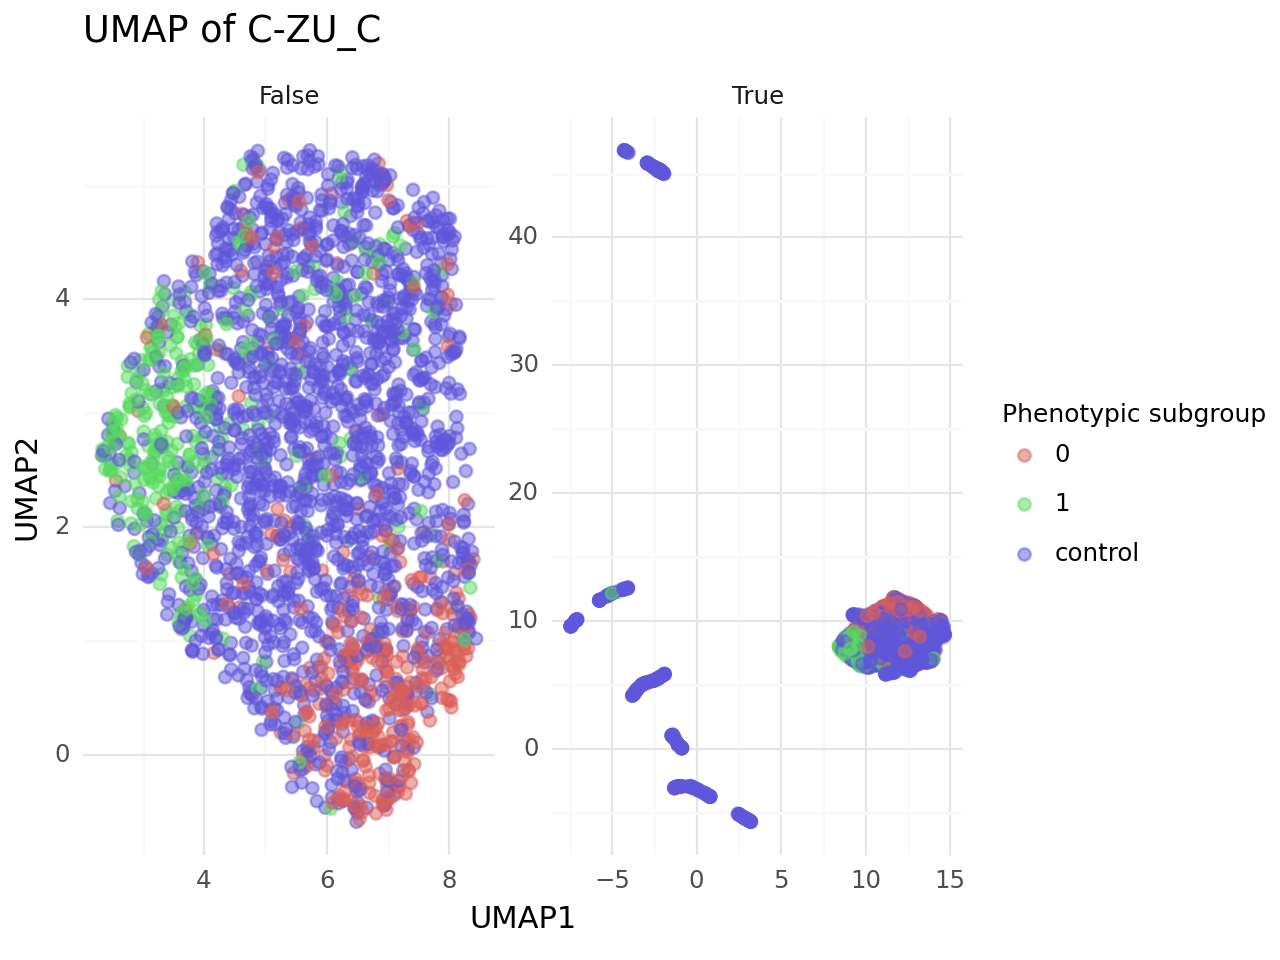

<Figure Size: (640 x 480)>

In [40]:
ps_list = [True,False]
e = 1
dataset=0
g=10
num_markers = 100
plot_dfs = []
for ps in ps_list:
    output_file_suffix = sim_functions.get_output_file_suffix(ps,e,dataset,g)
    with open(f"{sim_output_dir}/simulation_metadata_{output_file_suffix}.pkl", "rb") as f:
                simulation_metadata = pickle.load(f)
    phenotypic_subgroups = simulation_metadata['phenotypic_subgroups']
    iid_order = simulation_metadata['iid_order']
    fam_df = pd.read_csv(f'{sim_output_dir}/G_{sim_functions.get_output_file_suffix(ps,e,dataset,g)}.fam',sep='\s+',header=None)
    fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
    iid_index = fam_df[fam_df['IID'].isin(simulation_metadata['iid_order'])].index
    G = np.loadtxt(f'{sim_output_dir}/G_{sim_functions.get_output_file_suffix(ps,e,dataset,g)}.raw',  usecols=range(6, num_markers+6), dtype=np.int8, skiprows=1)
    C = np.load(f'{sim_output_dir}/C_{output_file_suffix}.npy')
    idx = all_runs.groupby(["run_name", "ps", "e", "g","dataset"])["total_loss"].idxmin()
    best = (
        all_runs.loc[idx, all_runs.columns]
        .sort_values(["experiment_id","run_name", "ps", "e", "g"])
        .reset_index(drop=True)
    )
    exp_id = best[(best['ps']==ps)&(best['e']==e)&(best['dataset']==dataset)&(best['g']==g)&(best['run_name']=='SCoNE')]['experiment_id'].values[0]
    run_id = best[(best['ps']==ps)&(best['e']==e)&(best['dataset']==dataset)&(best['g']==g)&(best['run_name']=='SCoNE')]['run_id'].values[0]
    with open(f'{output_dir}/logs/{exp_id}/{run_id}/artifacts/state_info/final_state.pkl','rb') as f:
        final_state = pickle.load(f)
    reducer = umap.UMAP(metric='cosine')
    embedding = reducer.fit_transform(C-Z[iid_index,:]@final_state['U_C'].T)

    labels = (phenotypic_subgroups.loc[lambda d: d['subgroup'] & d['phenotypic_subgroup'].isin([0, 1])].groupby('IID')['phenotypic_subgroup']
            .apply(lambda s: ','.join(map(str, sorted(s)))))
    # fill others as 'control'
    out = pd.DataFrame(index=phenotypic_subgroups['IID'].unique()).sort_index()
    out['phenotypic_subgroup'] = 'control'
    out.loc[labels.index, 'phenotypic_subgroup'] = labels
    out = out.reset_index().rename(columns={"index": "IID"})

    plot_df = (pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"], index=iid_order).
                    rename_axis("IID").reset_index().merge(out[['IID','phenotypic_subgroup']], on='IID',how='inner'))
    plot_df['ps'] = ps
    plot_dfs.append(plot_df)
plot_dfs = pd.concat(plot_dfs)
p = (
    ggplot(plot_dfs, aes("UMAP1", "UMAP2", color='phenotypic_subgroup'))
    + geom_point(alpha=0.5, size=2)
    + labs(title='UMAP of C-ZU_C', color='Phenotypic subgroup')
    + facet_wrap(f'~ps',ncol=2,scales='free')
    + theme_minimal()
    + theme(legend_title=element_text(size=9))
)
p

In [4]:
# test code setup

# DEFINE PATHS
intermediate_plink_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
sim_output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
graph_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
maf_by_superpop_filepath = f'{intermediate_plink_dir}/maf_by_superpop'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'
code_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/code'
# DEFINE PATHS


# read in 
G = np.loadtxt(f'{sim_output_dir}/G.raw',  usecols=range(6, 10000+6), dtype=np.int8, skiprows=1)
G = (G>0).astype(np.int8)
# assert that bim_df and G order is the same
bfile_path = f'{sim_output_dir}/G'
bim_df = pd.read_csv(f'{bfile_path}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2']).reset_index(drop=True)
G_columns = [i.split('_')[0] for i in pd.read_csv(f'{bfile_path}.raw',sep='\s+',usecols=range(6, 10000+6),nrows=1).columns]
assert all(bim_df['SNP'].values==G_columns)

In [6]:
from collections import defaultdict


# ML Flow 

In [1]:
import mlflow
from mlflow.tracking import MlflowClient

In [24]:
colors_dict = {
"SCoNE":"#2f4b7c",
"MVBC":"#665191",
"RGWAS":"#a05195",  
"C-NMF":"#d45087",  
"C-CoNE":"#f95d6a",  
"G-NMF":"#ff7c43",  
"G-CoNE":"#ffa600",  
"HNMF":"#2ca02c",  
"SCoNE(Fro)":"#1f77b4",
"CoNE":"#17becf"
}

In [ ]:
mlflow.set_tracking_uri("file:/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs_tuning")
client = MlflowClient()
# Get all experiments
experiments = client.search_experiments()
all_runs = []
for exp in experiments:
    df = mlflow.search_runs([exp.experiment_id])
    if not df.empty:
        df["experiment_id"] = exp.experiment_id
        df["experiment_name"] = exp.name
        all_runs.append(df)
all_runs = pd.concat(all_runs, ignore_index=True)
all_runs = all_runs[all_runs['status']=='FINISHED'].copy()
all_runs[['params.e','params.g_ps','params.c_ps','params.lambda_W','params.lambda_H_G','params.lambda_H_C']]  = all_runs[['params.e','params.g_ps','params.c_ps','params.lambda_W','params.lambda_H_G','params.lambda_H_C']].astype("float64") 
all_runs.columns=[i.replace('params.','').replace('metrics.','') for i in all_runs.columns]

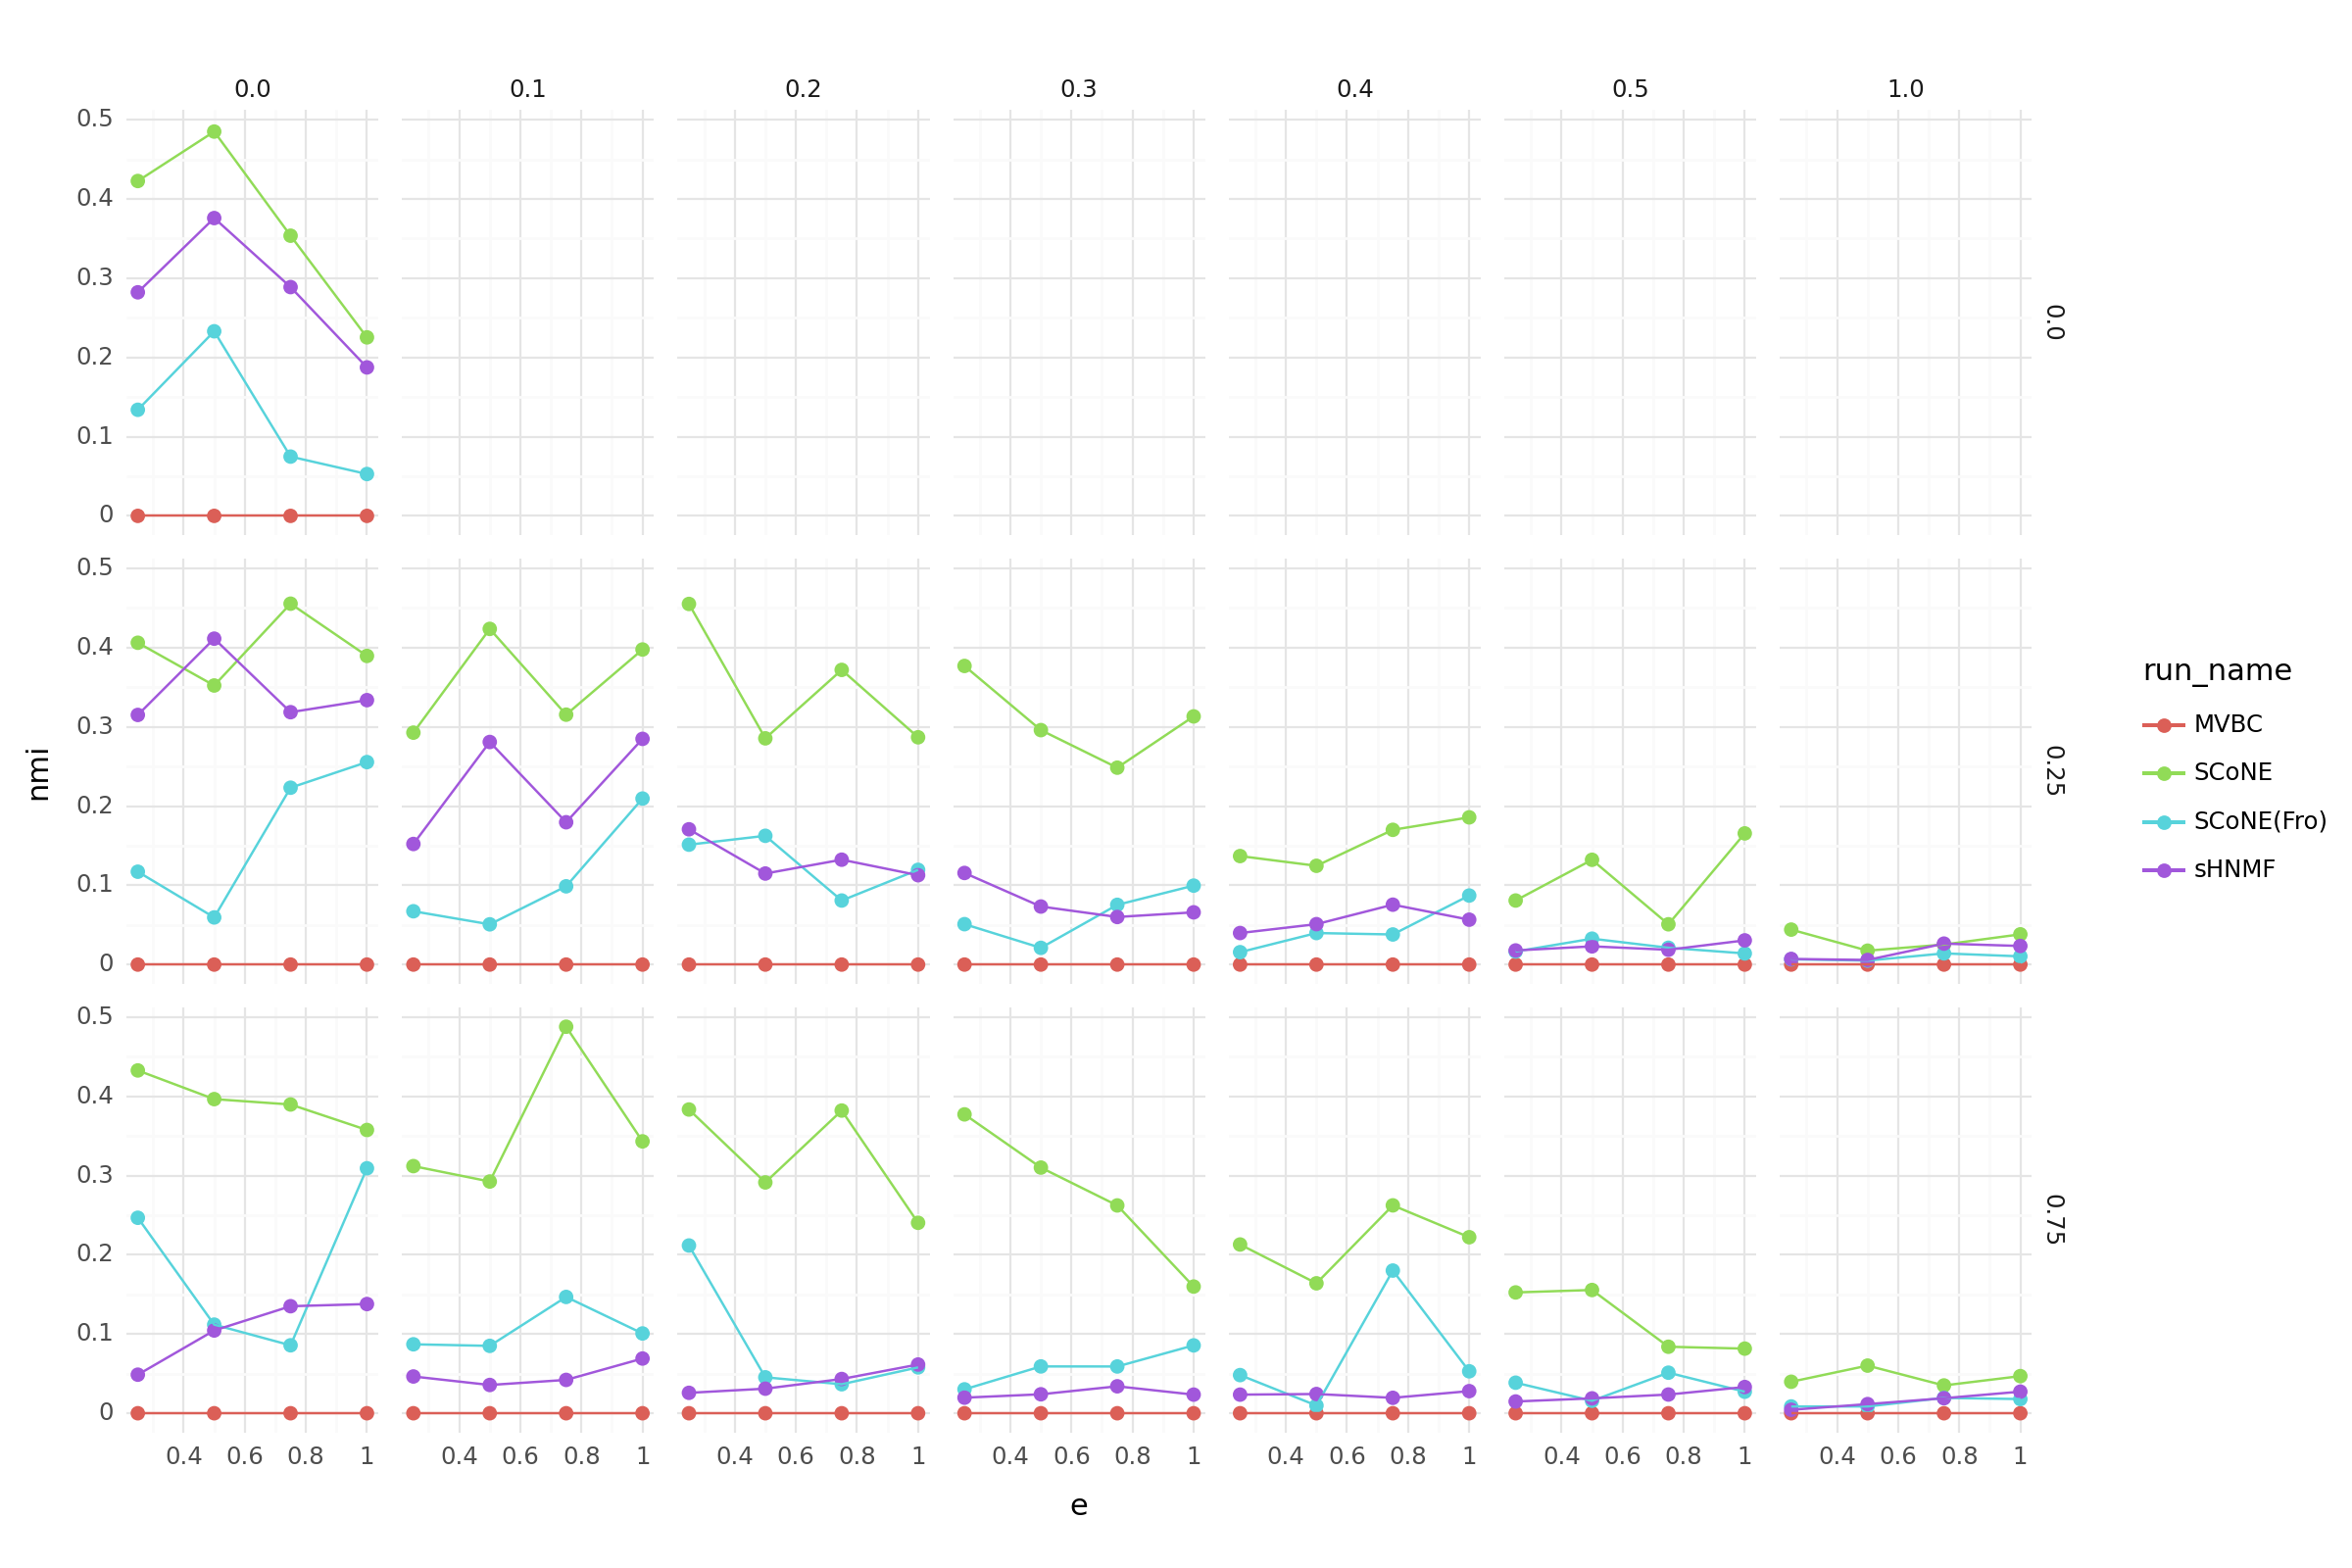

In [5]:
idx = all_runs.groupby(["run_name", "g_ps", "c_ps", "e"])["nmi"].idxmax()
best = (
    all_runs.loc[idx, all_runs.columns]
      .reset_index(drop=True)
)

p = (
ggplot(best, aes(x="e", y="nmi", color="run_name", group="run_name"))
+ geom_point(size=2)
+ geom_line()
+ facet_grid('g_ps ~ c_ps')
+ theme_minimal()
+ theme(figure_size=(12,8))
)
print(p)

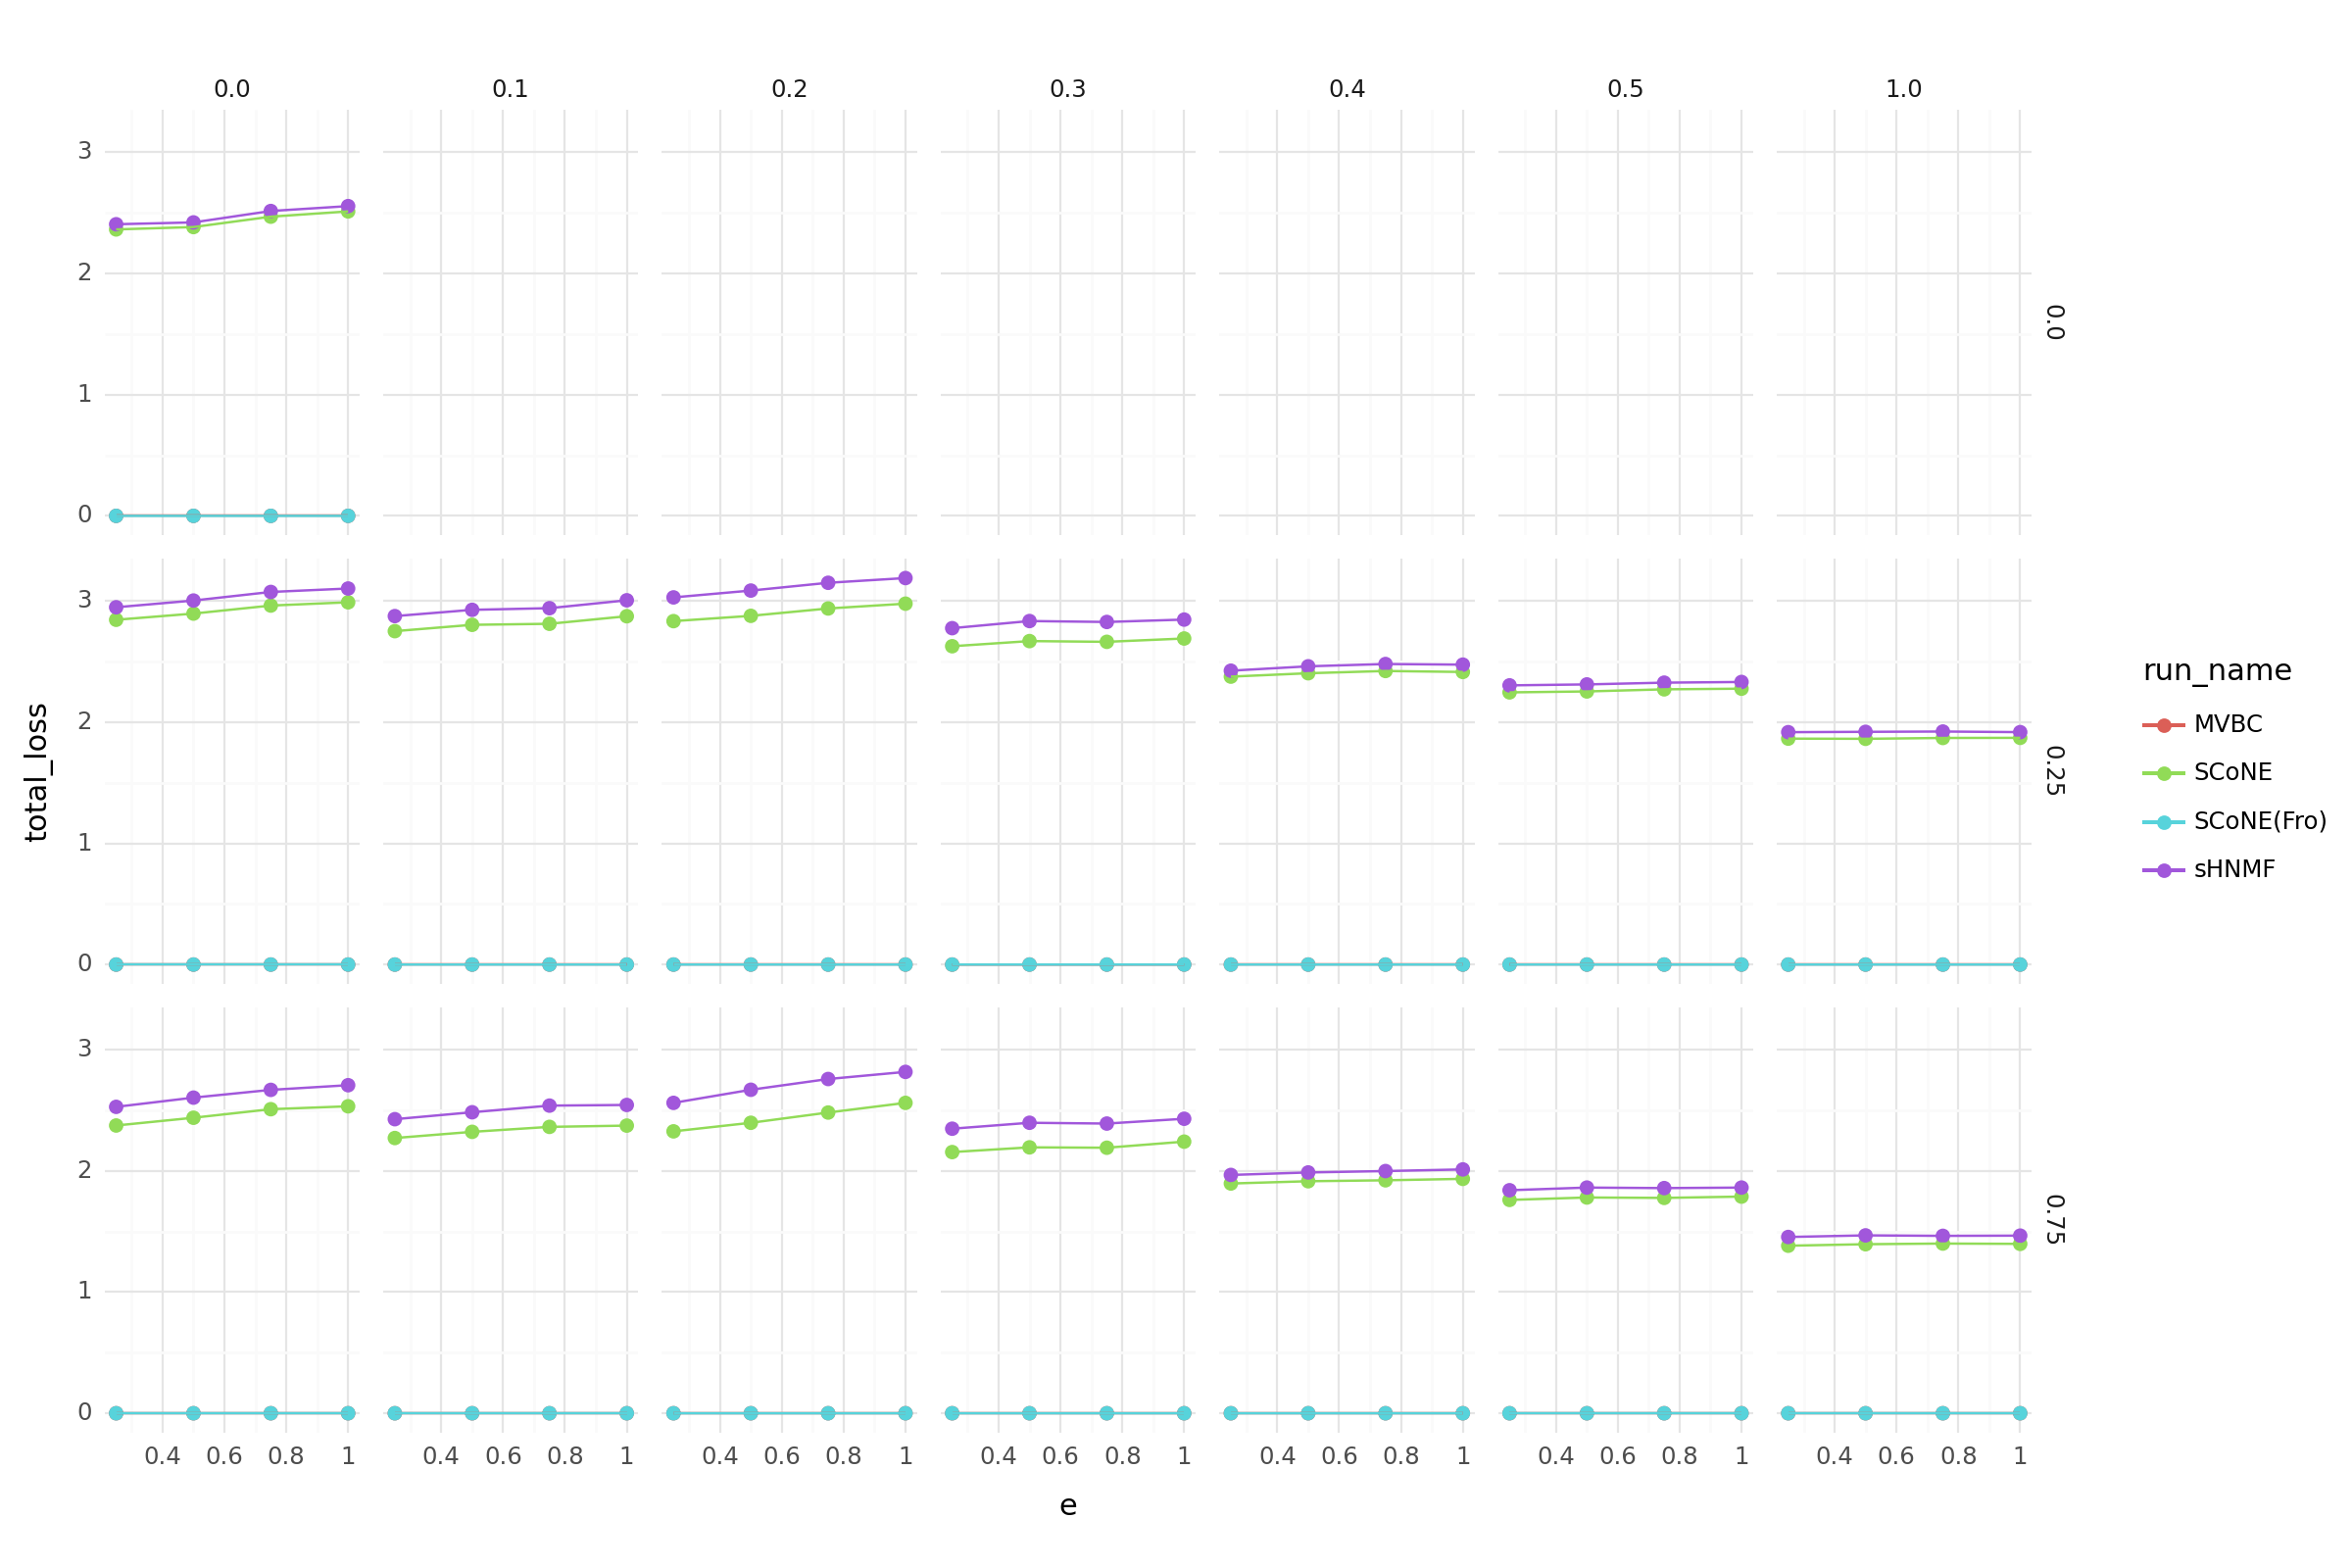

In [20]:
p = (
ggplot(best, aes(x="e", y="total_loss", color="run_name", group="run_name"))
+ geom_point(size=2)
+ geom_line()
+ facet_grid('g_ps ~ c_ps')
+ theme_minimal()
+ theme(figure_size=(12,8))
)
print(p)

In [51]:
group_means = best.groupby('run_name')['lambda_W']
mean = pd.DataFrame(group_means.mean()).reset_index().rename(columns={'lambda_W':'mean'})
sd   = pd.DataFrame(group_means.std(ddof=1)).reset_index().rename(columns={'lambda_W':'std'})
mean.merge(sd,on='run_name')

,run_name,mean,std
0,MVBC,0.000000,0.000000
1,SCoNE,0.026833,0.040942
2,SCoNE(Fro),0.003667,0.018130
3,sHNMF,0.021167,0.039877


In [52]:
group_means = best.groupby('run_name')['lambda_H_G']
mean = pd.DataFrame(group_means.mean()).reset_index().rename(columns={'lambda_H_G':'mean'})
sd   = pd.DataFrame(group_means.std(ddof=1)).reset_index().rename(columns={'lambda_H_G':'std'})
mean.merge(sd,on='run_name')

,run_name,mean,std
0,MVBC,0.000000,0.000000
1,SCoNE,0.051833,0.047102
2,SCoNE(Fro),0.045167,0.046886
3,sHNMF,0.046667,0.048770


In [53]:
group_means = best.groupby('run_name')['lambda_H_C']
mean = pd.DataFrame(group_means.mean()).reset_index().rename(columns={'lambda_H_C':'mean'})
sd   = pd.DataFrame(group_means.std(ddof=1)).reset_index().rename(columns={'lambda_H_C':'std'})
mean.merge(sd,on='run_name')

,run_name,mean,std
0,MVBC,0.086167,0.033247
1,SCoNE,0.018833,0.034694
2,SCoNE(Fro),0.011000,0.030068
3,sHNMF,0.034500,0.043430


generally sparsity increase with increase in lambda

In [55]:
all_runs[all_runs['status']!='FINISHED']

,run_id,experiment_id,status,artifact_uri,start_time,end_time,nmi,total_loss,user time,W_norm,...,min_outer,inner_ftol,norm,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.type,tags.mlflow.source.name,tags.trainer,tags.num_epochs,experiment_name


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 1 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 15 rows containing missing values.


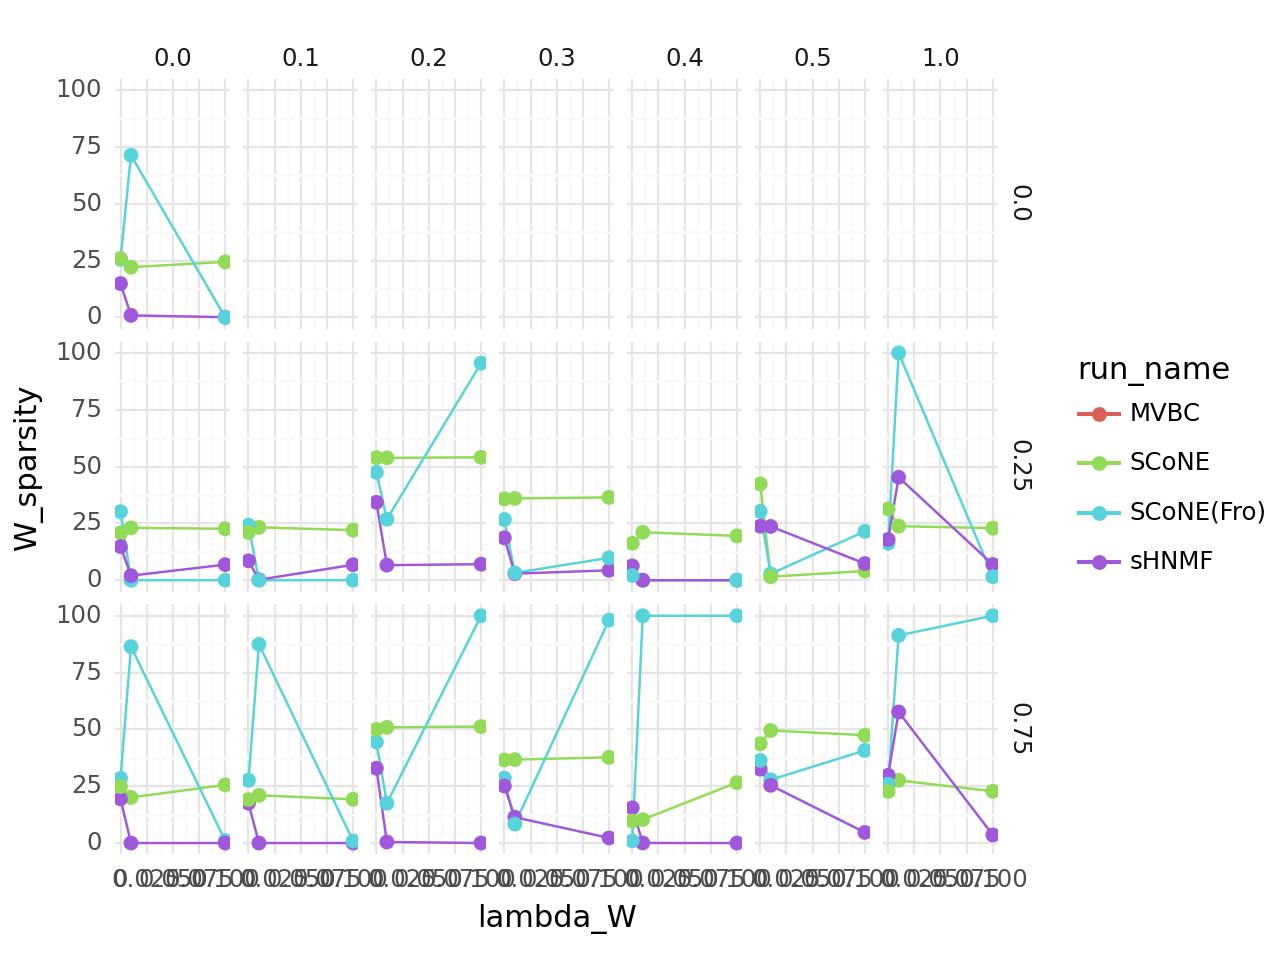

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 1 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 15 rows containing missing values.


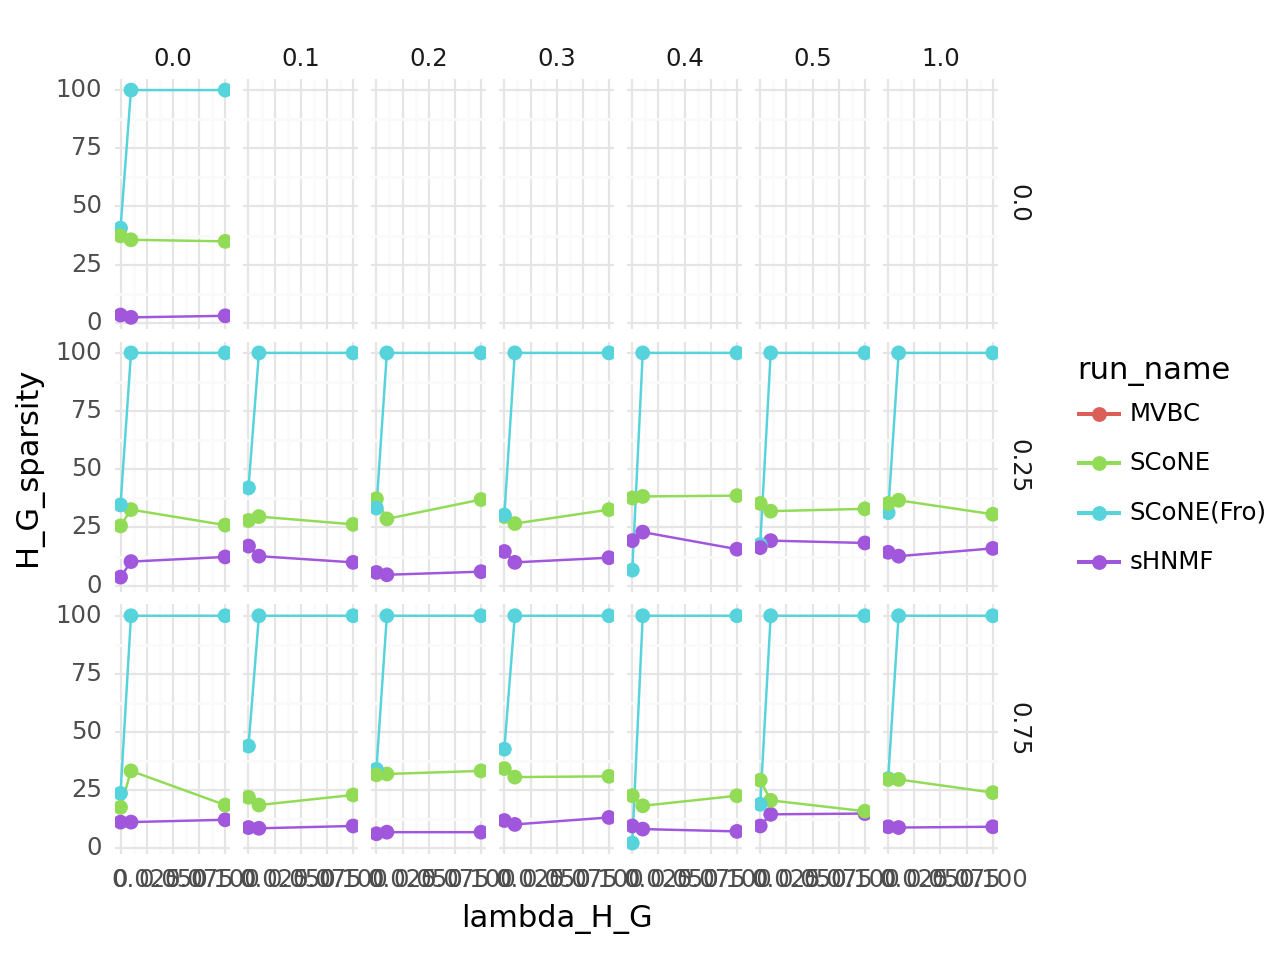

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 3 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 45 rows containing missing values.


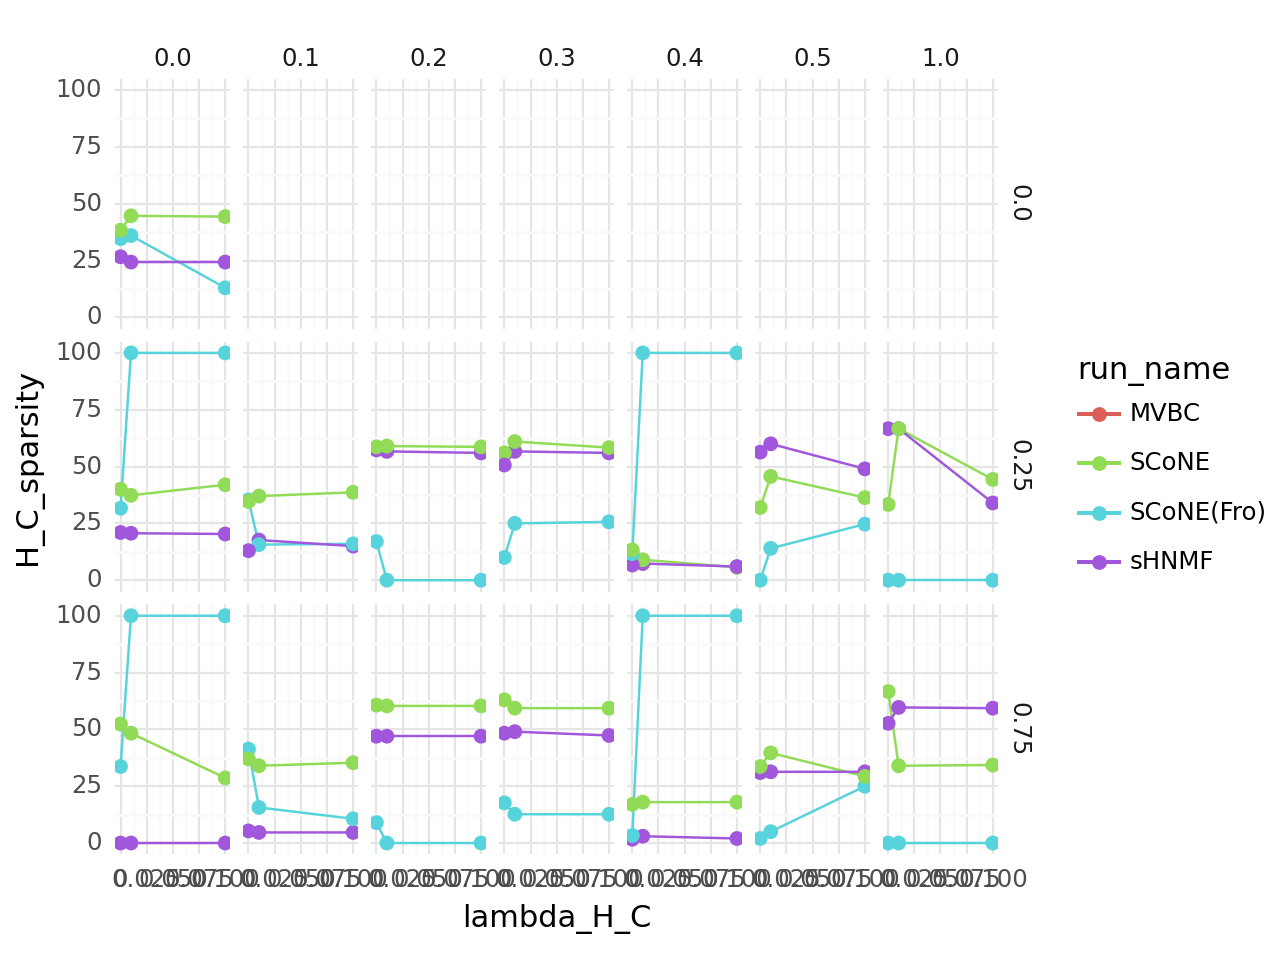

In [54]:
corresponding_norm = {'lambda_W':'W_sparsity','lambda_H_G':'H_G_sparsity','lambda_H_C':'H_C_sparsity'}
for param in ['lambda_W','lambda_H_G','lambda_H_C']: # maybe instead look when others are 0
    null_params = [i for i in ['lambda_W','lambda_H_G','lambda_H_C'] if i!=param]
    summary = all_runs[(all_runs[null_params[0]]==0)&(all_runs[null_params[1]]==0)]

    dodge = position_dodge(width=0.35)
    p = (
    ggplot(summary[summary['e']==1], aes(x=param, y=corresponding_norm[param], color="run_name", group='run_name'))
    + geom_line()
    + geom_point(size=2)
    #+ geom_errorbar(aes(ymin="ymin",ymax="ymax"))
    + theme_minimal()
    + theme()
    + facet_grid('g_ps ~ c_ps')
    )
    print(p)

# Reading in test runs

In [13]:
import mlflow
from mlflow.tracking import MlflowClient

colors_dict = {
"SCoNE":"#2f4b7c",
"MVBC":"#665191",
"RGWAS":"#a05195",  
"C-NMF":"#d45087",  
"C-CoNE":"#f95d6a",  
"G-NMF":"#ff7c43",  
"G-CoNE":"#ffa600",  
"HNMF":"#2ca02c",  
"SCoNE(Fro)":"#1f77b4",
"CoNE":"#17becf"
}

In [17]:
mlflow.set_tracking_uri("file:/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs")
client = MlflowClient()
client = MlflowClient()
# Get all experiments
experiments = client.search_experiments()
all_runs = []
for exp in experiments:
    df = mlflow.search_runs([exp.experiment_id])
    if not df.empty:
        df["experiment_id"] = exp.experiment_id
        df["experiment_name"] = exp.name
        all_runs.append(df)
    #print(df)
all_runs = pd.concat(all_runs, ignore_index=True)
#all_runs = all_runs[all_runs['status']=='FINISHED'].copy()
all_runs[['params.e','params.g_ps','params.c_ps','params.lambda_W','params.lambda_H_G','params.lambda_H_C']]  = all_runs[['params.e','params.g_ps','params.c_ps','params.lambda_W','params.lambda_H_G','params.lambda_H_C']].astype("float64") 
all_runs.columns=[i.replace('params.','').replace('metrics.','') for i in all_runs.columns]

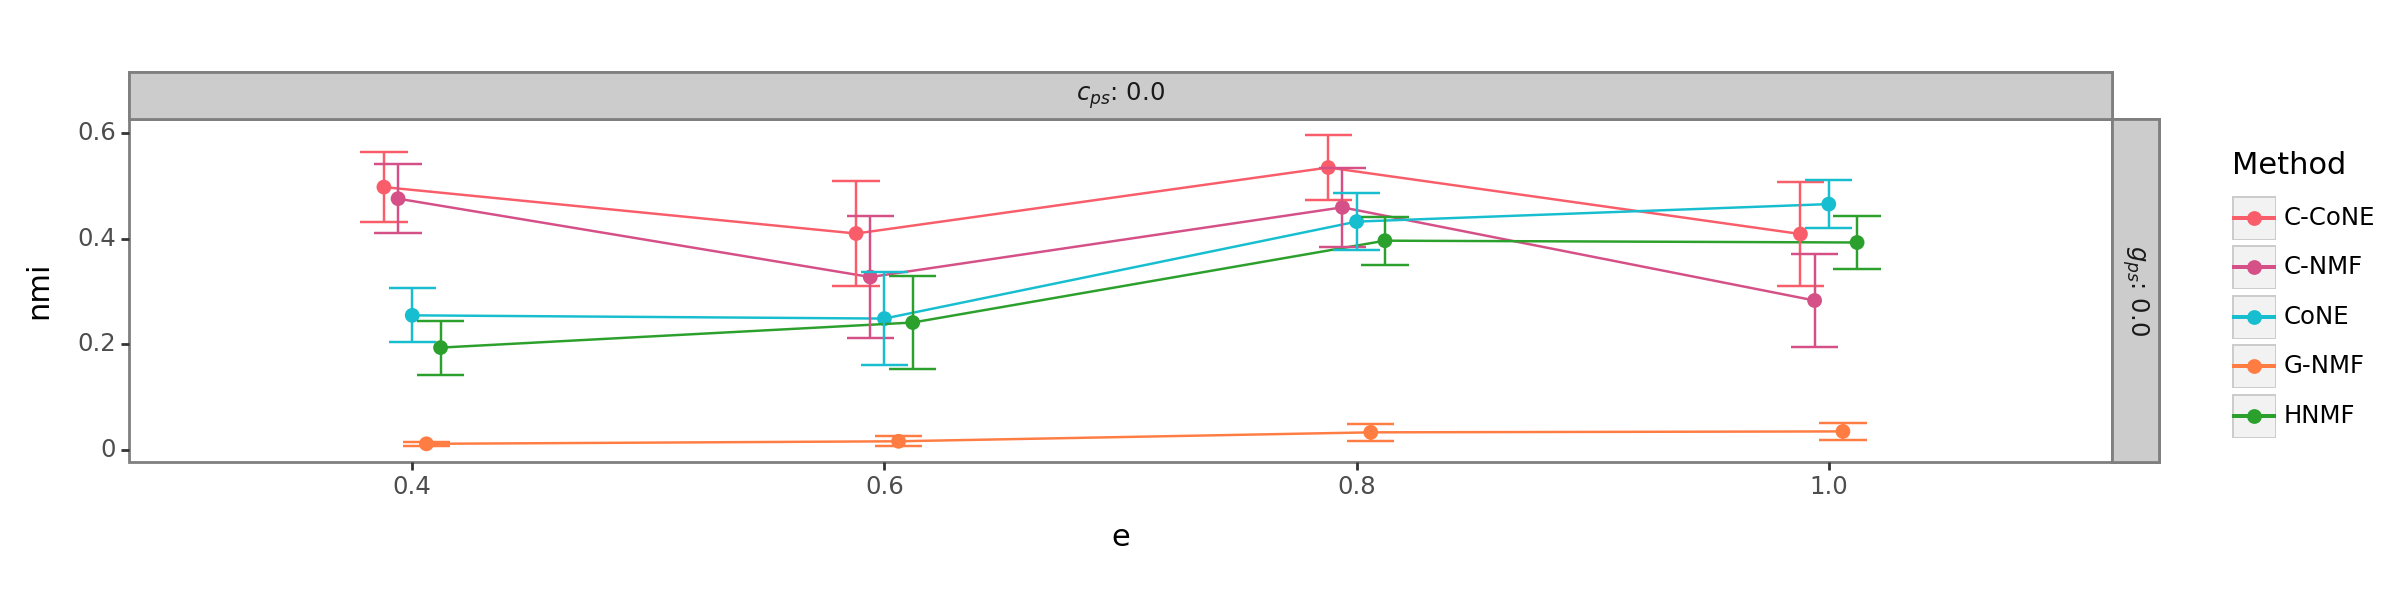

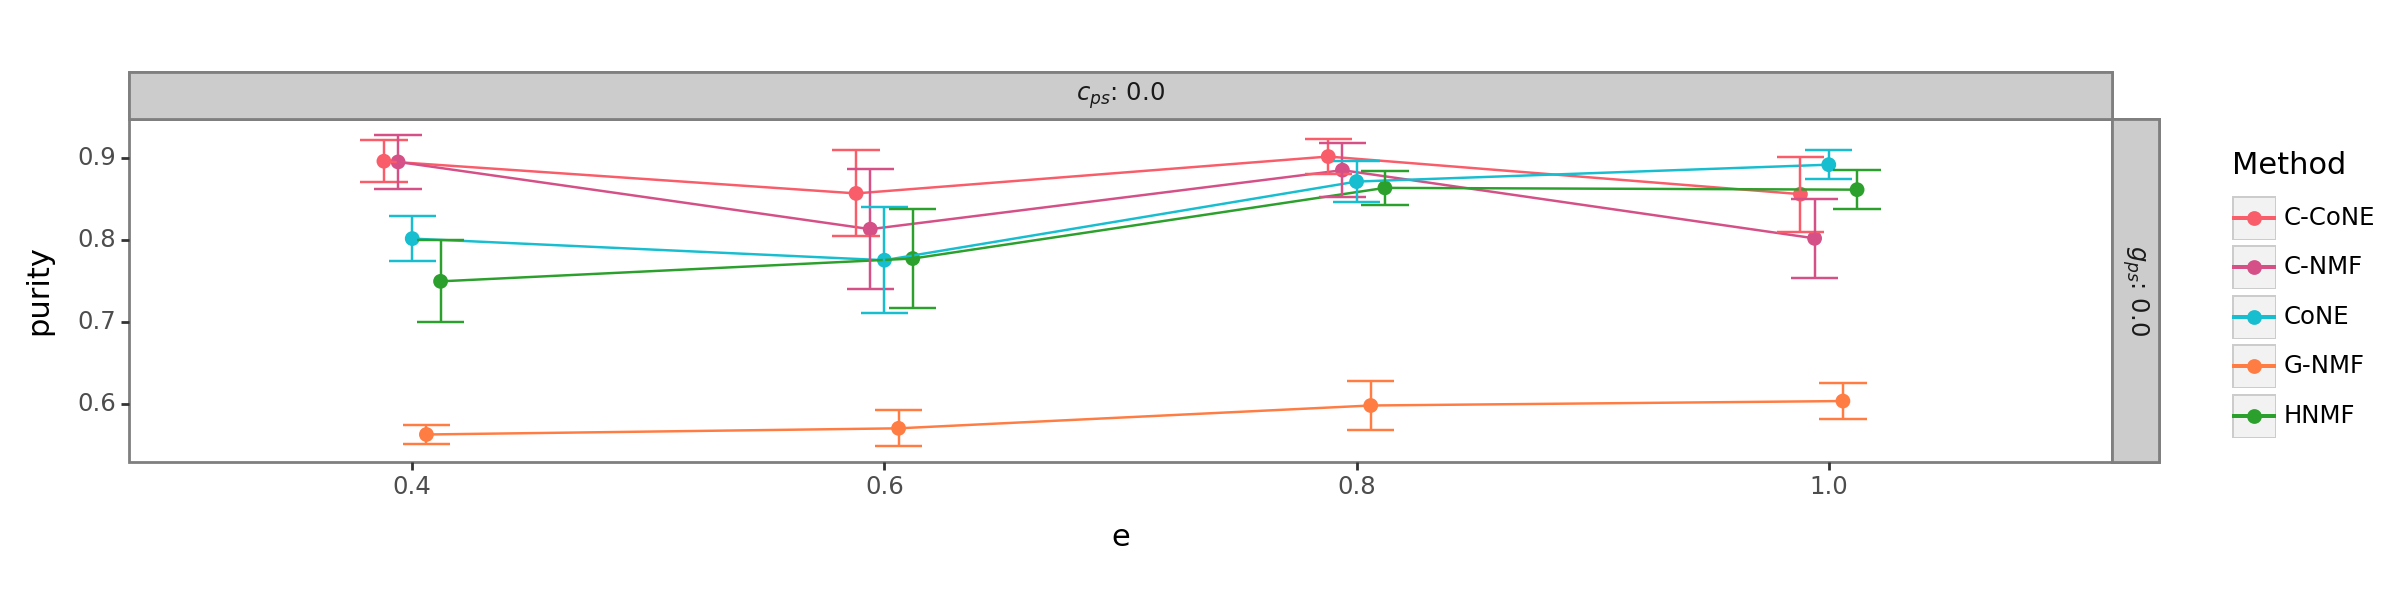

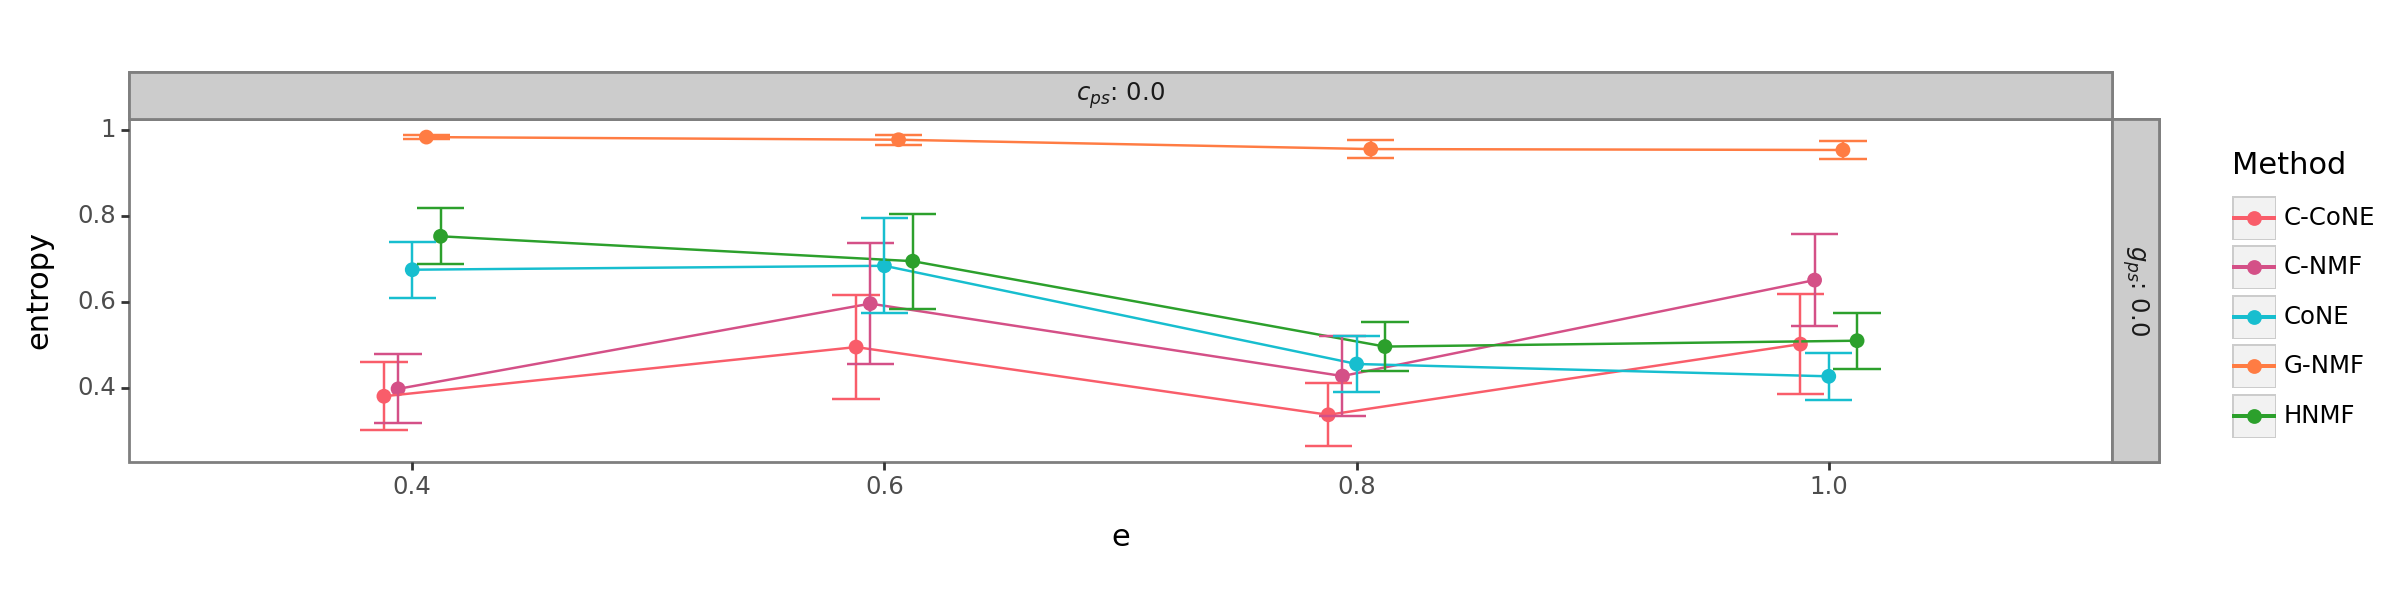

In [18]:
# get CI over 10 random datasets
# [all_runs['run_name'].isin(['RGWAS','MVBC','HNMF','SCoNE'])]
dodge = position_dodge(width=0.15)

for metric in ['nmi','purity','norm_cond_entropy']:
    summary = (
        all_runs.groupby(["run_name", "g_ps", "c_ps", "e"])[metric]
            .agg(n='count', mean='mean', std='std').reset_index()
    )
    summary.rename(columns={'g_ps':r'$g_{ps}$','c_ps':r'$c_{ps}$'},inplace=True)
    summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["n"])         # normal approx 95% CI
    summary["ymin"] = summary["mean"] - summary["ci95"]
    summary["ymax"] = summary["mean"] + summary["ci95"]
    if metric=='norm_cond_entropy':
        metric = 'entropy'
        summary.rename(columns={'norm_cond_entropy':metric},inplace=True)
    p = (
    ggplot(summary[(summary[r'$g_{ps}$']==0)], aes(x="factor(e)", y="mean", color="run_name", group="run_name"))
    + geom_point(size=2,position=dodge)
    + geom_line(position=dodge)
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),position=dodge)
    + labs(x="e", y=metric, title='',color='Method')
    + facet_grid(r'$g_{ps}$ ~ $c_{ps}$',labeller='label_both')
    + scale_color_manual(values=colors_dict)
    + theme_bw()
    + theme(
        panel_grid_major = element_blank(),
        panel_grid_minor = element_blank()
    )
    + theme(figure_size=(12,3))
    )
    print(p)

    # p = (
    # ggplot(summary[(summary[r'$g_{ps}$']!=0)], aes(x="factor(e)", y="mean", color="run_name", group="run_name"))
    # + geom_point(size=2,position=dodge)
    # + geom_line(position=dodge)
    # + geom_errorbar(aes(ymin="ymin",ymax="ymax"),position=dodge)
    # + labs(x="e", y=metric, title='',color='Method')
    # + facet_grid(r'$g_{ps}$ ~ $c_{ps}$',labeller='label_both')
    # + scale_color_manual(values=colors_dict)
    # + theme_bw()
    # + theme(
    #     panel_grid_major = element_blank(),
    #     panel_grid_minor = element_blank()
    # )
    # + theme(figure_size=(12,8))
    # )
    # print(p)


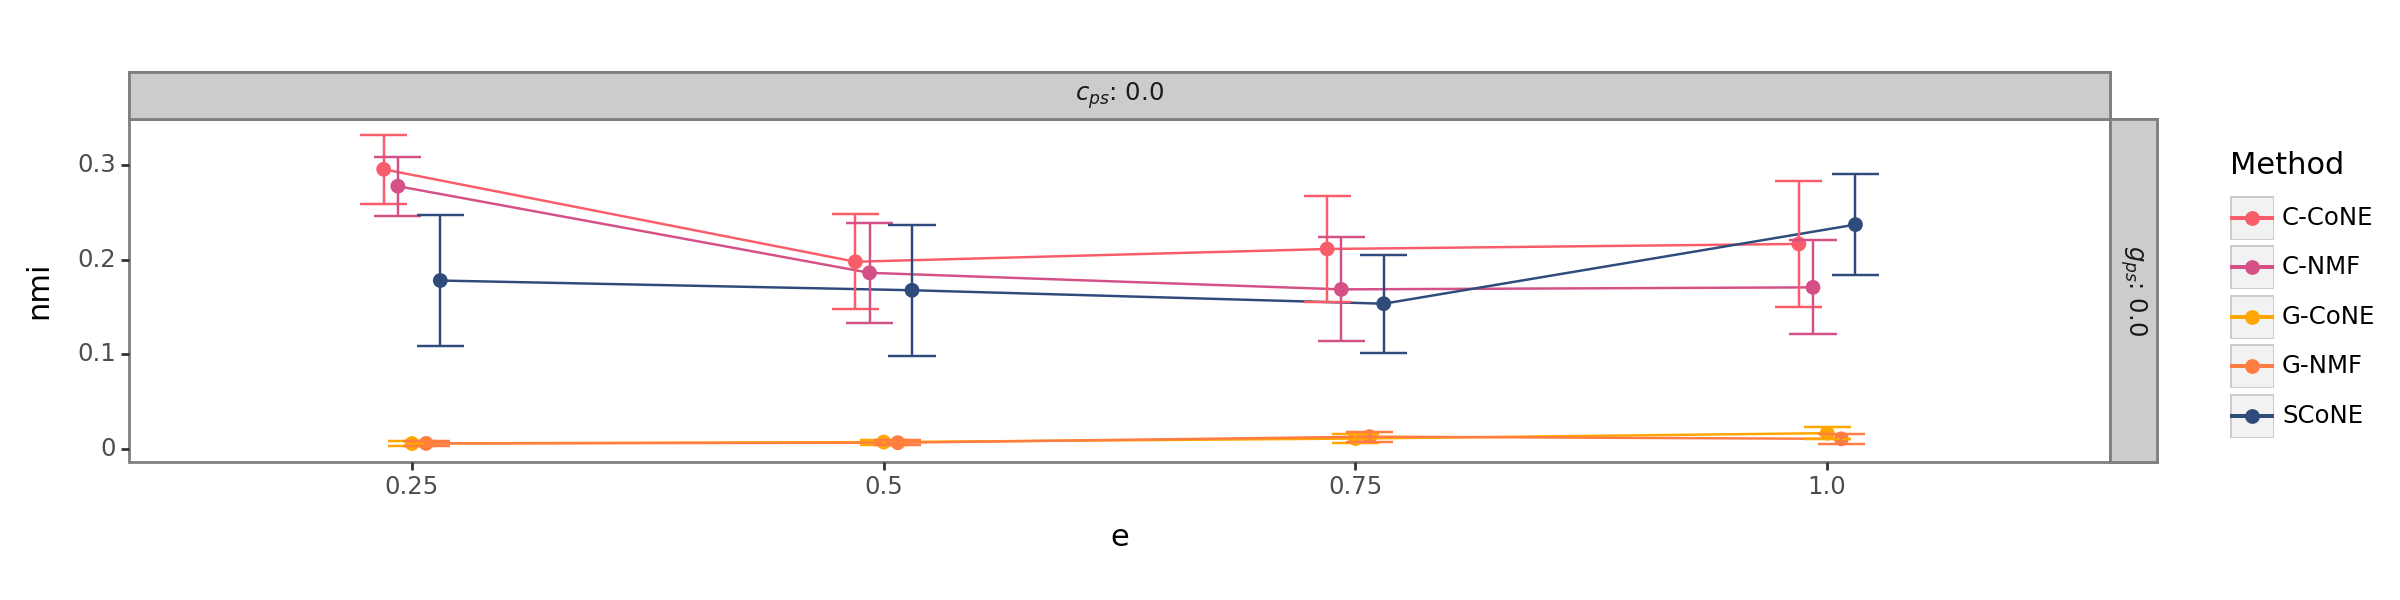

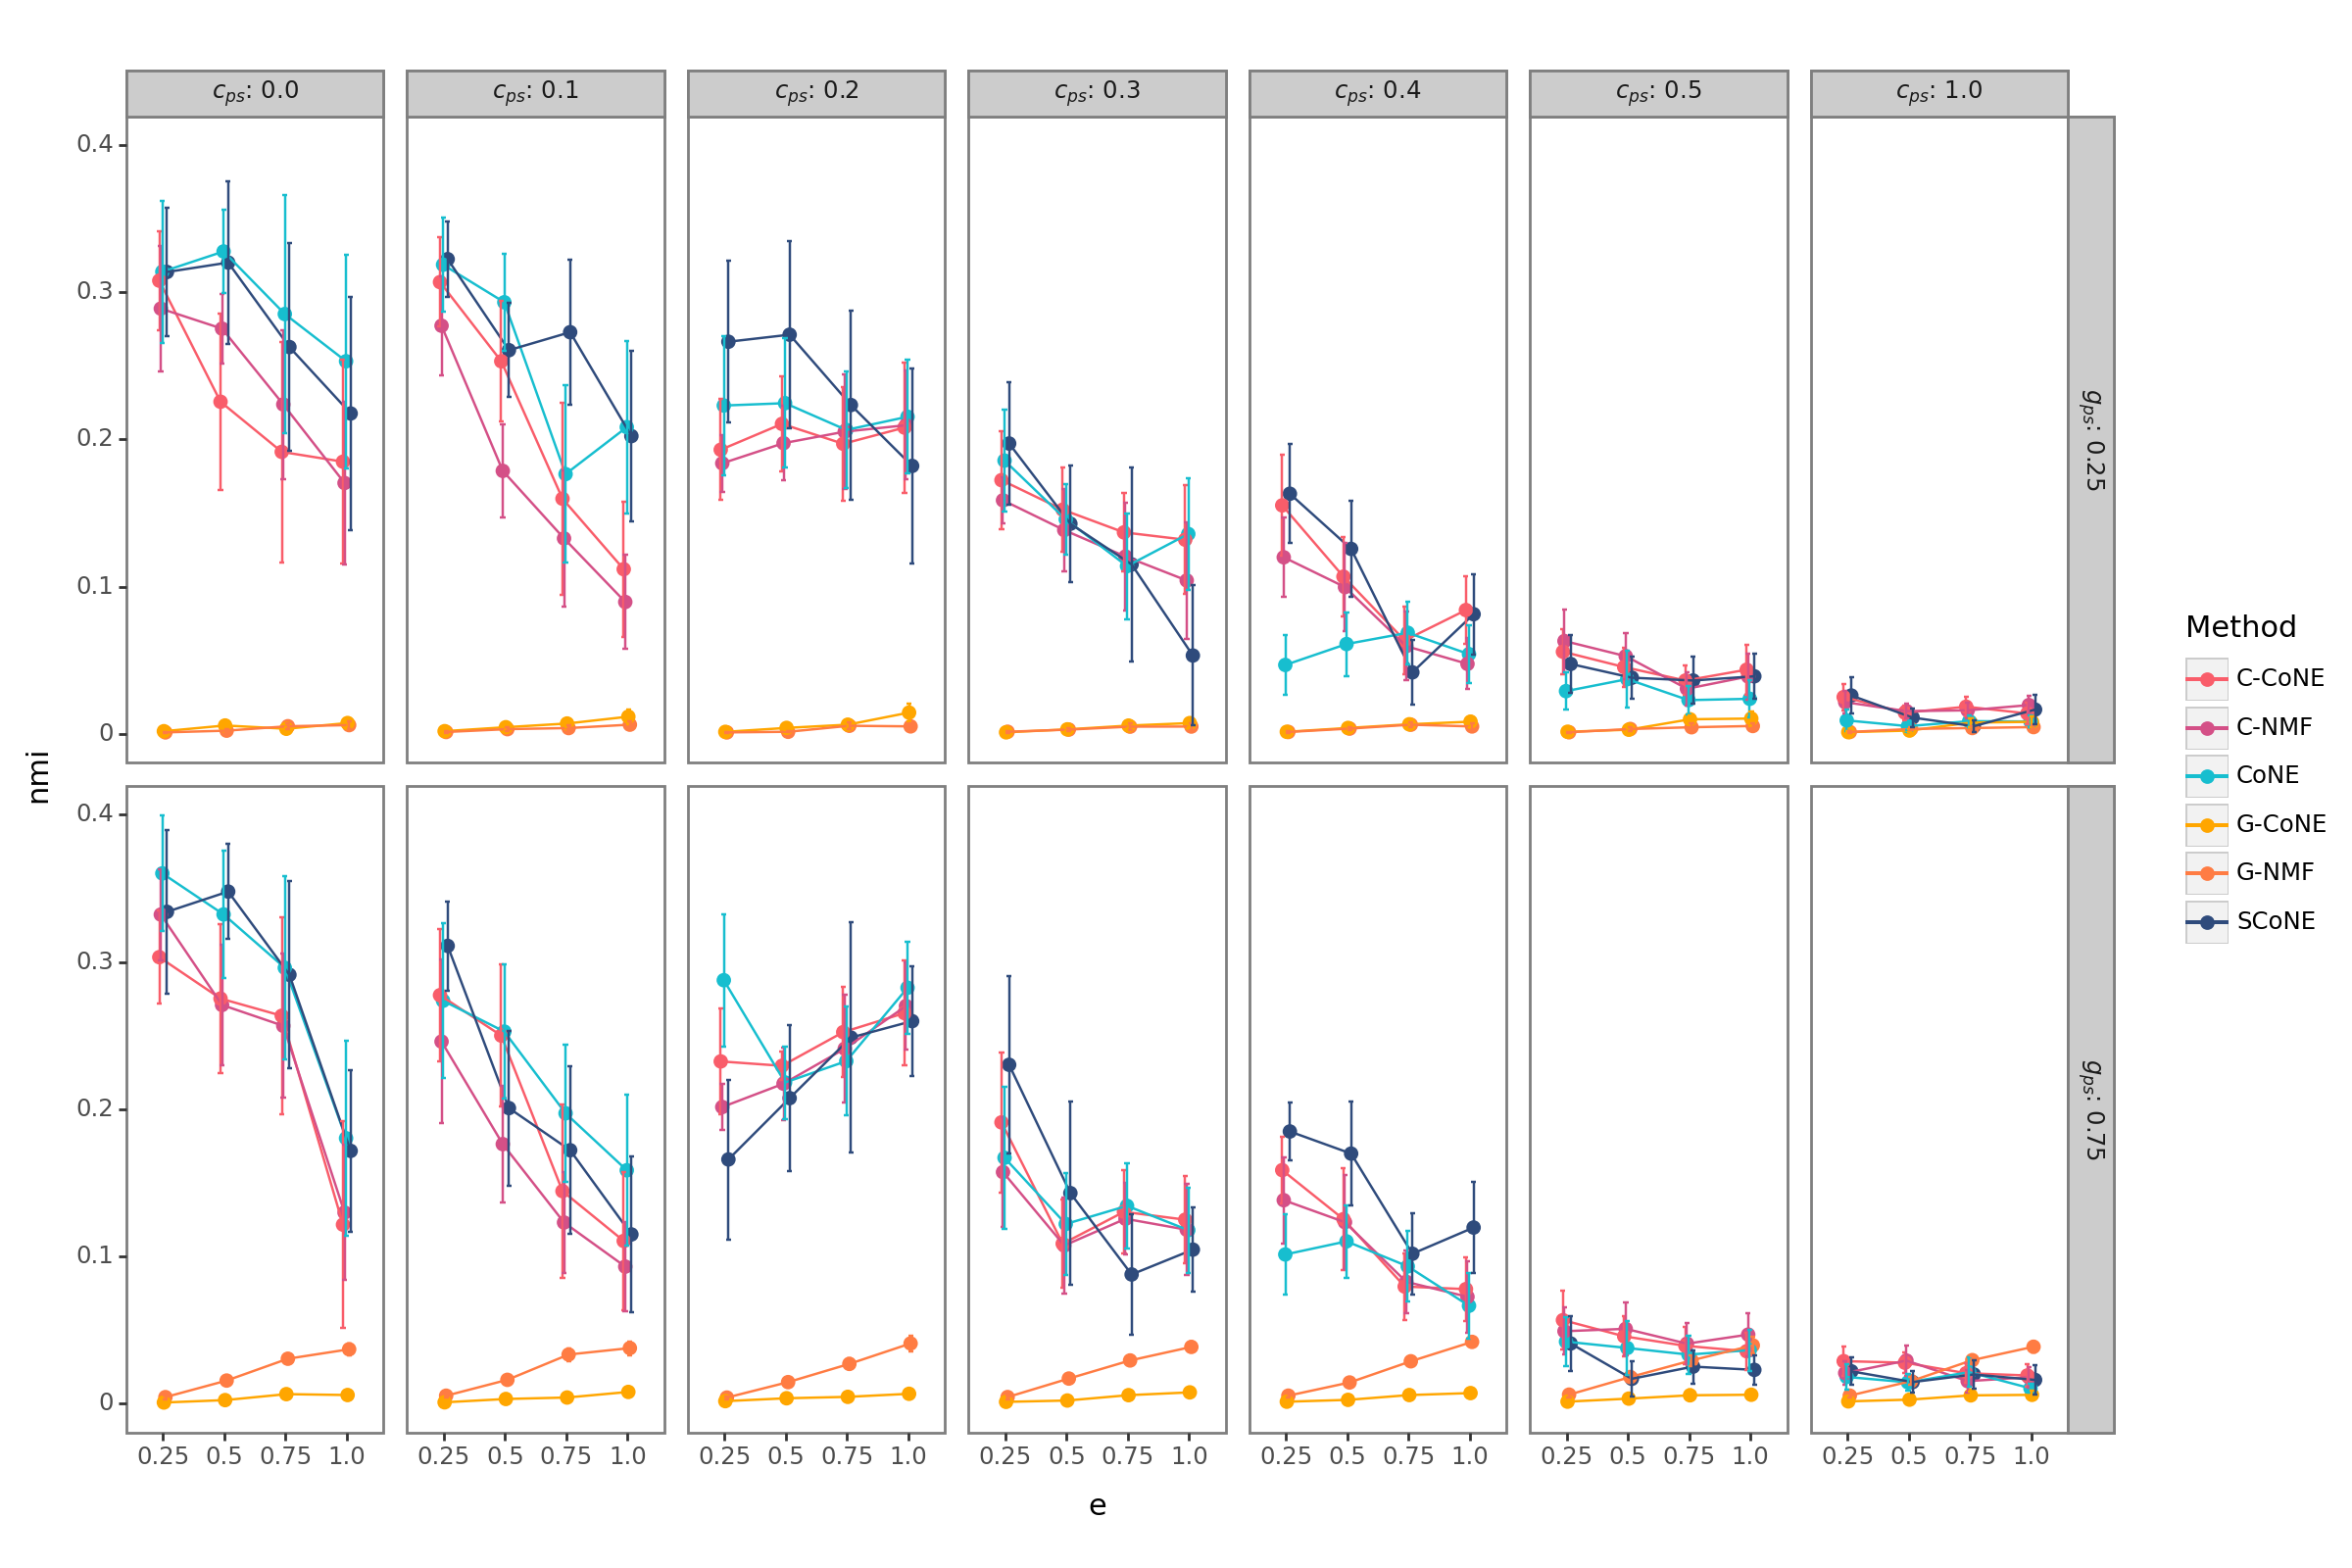

In [76]:
for metric in ['nmi']:
    summary = (
        all_runs.groupby(["run_name", "g_ps", "c_ps", "e"])[metric]
            .agg(n='count', mean='mean', std='std').reset_index()
    )
    summary.rename(columns={'g_ps':r'$g_{ps}$','c_ps':r'$c_{ps}$'},inplace=True)
    summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["n"])         # normal approx 95% CI
    summary["ymin"] = summary["mean"] - summary["ci95"]
    summary["ymax"] = summary["mean"] + summary["ci95"]
    if metric=='norm_cond_entropy':
        metric = 'entropy'
        summary.rename(columns={'norm_cond_entropy':metric},inplace=True)
    p = (
    ggplot(summary[(summary['run_name'].isin(['C-NMF','G-NMF','G-CoNE','C-CoNE','SCoNe (Fro)','SCoNE']))&(summary[r'$g_{ps}$']==0)], aes(x="factor(e)", y="mean", color="run_name", group="run_name"))
    + geom_point(size=2,position=dodge)
    + geom_line(position=dodge)
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),position=dodge)
    + labs(x="e", y=metric, title='',color='Method')
    + facet_grid(r'$g_{ps}$ ~ $c_{ps}$',labeller='label_both')
    + scale_color_manual(values=colors_dict)
    + theme_bw()
    + theme(
        panel_grid_major = element_blank(),
        panel_grid_minor = element_blank()
    )
    + theme(figure_size=(12,3))
    )
    print(p)

    p = (
    ggplot(summary[(summary['run_name'].isin(['C-NMF','G-NMF','G-CoNE','C-CoNE','SCoNe (Fro)','SCoNE','CoNE']))&(summary[r'$g_{ps}$']!=0)], aes(x="factor(e)", y="mean", color="run_name", group="run_name"))
    + geom_point(size=2,position=dodge)
    + geom_line(position=dodge)
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),position=dodge)
    + labs(x="e", y=metric, title='',color='Method')
    + facet_grid(r'$g_{ps}$ ~ $c_{ps}$',labeller='label_both')
    + scale_color_manual(values=colors_dict)
    + theme_bw()
    + theme(
        panel_grid_major = element_blank(),
        panel_grid_minor = element_blank()
    )
    + theme(figure_size=(12,8))
    )
    print(p)


# Reading in loss/consistency runs

In [98]:
mlflow.set_tracking_uri("file:/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs_loss_consistency")
client = MlflowClient()
# Get all experiments
experiments = client.search_experiments()
all_runs = []
for exp in experiments:
    df = mlflow.search_runs([exp.experiment_id])
    if not df.empty:
        df["experiment_id"] = exp.experiment_id
        df["experiment_name"] = exp.name
        all_runs.append(df)
all_runs = pd.concat(all_runs, ignore_index=True)
all_runs = all_runs[all_runs['status']=='FINISHED'].copy()
all_runs[['params.e','params.g_ps','params.c_ps','params.lambda_W','params.lambda_H_G','params.lambda_H_C']]  = all_runs[['params.e','params.g_ps','params.c_ps','params.lambda_W','params.lambda_H_G','params.lambda_H_C']].astype("float64") 
all_runs.columns=[i.replace('params.','').replace('metrics.','') for i in all_runs.columns]

In [101]:
all_runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,nmi,total_loss,user time,W_norm,...,run_name,inner_ftol,norm,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.type,tags.trainer,tags.mlflow.source.name,tags.num_epochs,experiment_name
0,abfbd72fcc8847fea08044e8a5c90e07,342308516001602830,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-28 13:55:59.679000+00:00,2025-10-28 13:56:09.256000+00:00,0.086582,2.650151,2.35,36.041053,...,SCoNE,1e-05,True,SCoNE,anewbury,LOCAL,<function alternating_opt at 0x7f1957a314c0>,/gpfs/commons/home/anewbury/miniconda/envs/jup...,50,59
1,c1268da3ab8d4431b87075423e0f0a54,342949413387897261,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-28 13:55:59.678000+00:00,2025-10-28 13:56:08.604000+00:00,0.313883,2.640372,2.46,27.833706,...,SCoNE,1e-05,True,SCoNE,anewbury,LOCAL,<function alternating_opt at 0x7f358b5e74c0>,/gpfs/commons/home/anewbury/miniconda/envs/jup...,50,59
2,52faacccab244876ae73090a510dbf64,747363981606964481,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-28 13:55:59.679000+00:00,2025-10-28 13:56:08.913000+00:00,0.097934,2.637979,2.24,40.914776,...,SCoNE,1e-05,True,SCoNE,anewbury,LOCAL,<function alternating_opt at 0x7f3a7af984c0>,/gpfs/commons/home/anewbury/miniconda/envs/jup...,50,59
3,7678b7215d3e4c2c85255b1063412212,964505407209217311,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-28 13:55:59.679000+00:00,2025-10-28 13:56:09.097000+00:00,0.401232,2.625041,2.44,38.323407,...,SCoNE,1e-05,True,SCoNE,anewbury,LOCAL,<function alternating_opt at 0x7fb1c4ec54c0>,/gpfs/commons/home/anewbury/miniconda/envs/jup...,50,59
4,2835625527e949f5aa4dc97bae08145a,999817732395336776,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-28 13:55:59.679000+00:00,2025-10-28 13:56:08.966000+00:00,0.156992,2.647457,2.31,29.838873,...,SCoNE,1e-05,True,SCoNE,anewbury,LOCAL,<function alternating_opt at 0x7f9f97c874c0>,/gpfs/commons/home/anewbury/miniconda/envs/jup...,50,59
5,112d114677dd4d17b956f4aa411543f8,462505950511556980,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-28 13:55:59.679000+00:00,2025-10-28 13:56:09.057000+00:00,0.488813,2.620169,2.69,32.219812,...,SCoNE,1e-05,True,SCoNE,anewbury,LOCAL,<function alternating_opt at 0x7f6bc07024c0>,/gpfs/commons/home/anewbury/miniconda/envs/jup...,50,59
6,ec375096881d4b149f5eeba1ca61cc0f,689651511994625753,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-28 13:55:59.679000+00:00,2025-10-28 13:56:09.190000+00:00,0.395341,2.658322,2.36,31.154297,...,SCoNE,1e-05,True,SCoNE,anewbury,LOCAL,<function alternating_opt at 0x7fd591e704c0>,/gpfs/commons/home/anewbury/miniconda/envs/jup...,50,59
7,ed856202511e4c358fca27f9a7bc76a8,849618195999166811,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-28 13:55:59.679000+00:00,2025-10-28 13:56:09.414000+00:00,0.031688,2.636717,2.40,36.562514,...,SCoNE,1e-05,True,SCoNE,anewbury,LOCAL,<function alternating_opt at 0x7fa8167994c0>,/gpfs/commons/home/anewbury/miniconda/envs/jup...,50,59
8,187d643112cc4afc90c688eda9789ef8,334736483951672435,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-28 13:55:59.679000+00:00,2025-10-28 13:56:08.933000+00:00,0.252916,2.647253,2.19,24.016421,...,SCoNE,1e-05,True,SCoNE,anewbury,LOCAL,<function alternating_opt at 0x7f5b068964c0>,/gpfs/commons/home/anewbury/miniconda/envs/jup...,50,59
9,18927c0e3deb465c93b549f29113c1cf,732105632884906389,FINISHED,file:///gpfs/commons/groups/gursoy_lab/anewbur...,2025-10-28 13:55:59.679000+00:00,2025-10-28 13:56:09.468000+00:00,0.160303,2.633371,2.28,47.028064,...,SCoNE,1e-05,True,SCoNE,anewbury,LOCAL,<function alternating_opt at 0x7f5fac07d4c0>,/gpfs/commons/home/anewbury/miniconda/envs/jup...,50,59


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:111: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


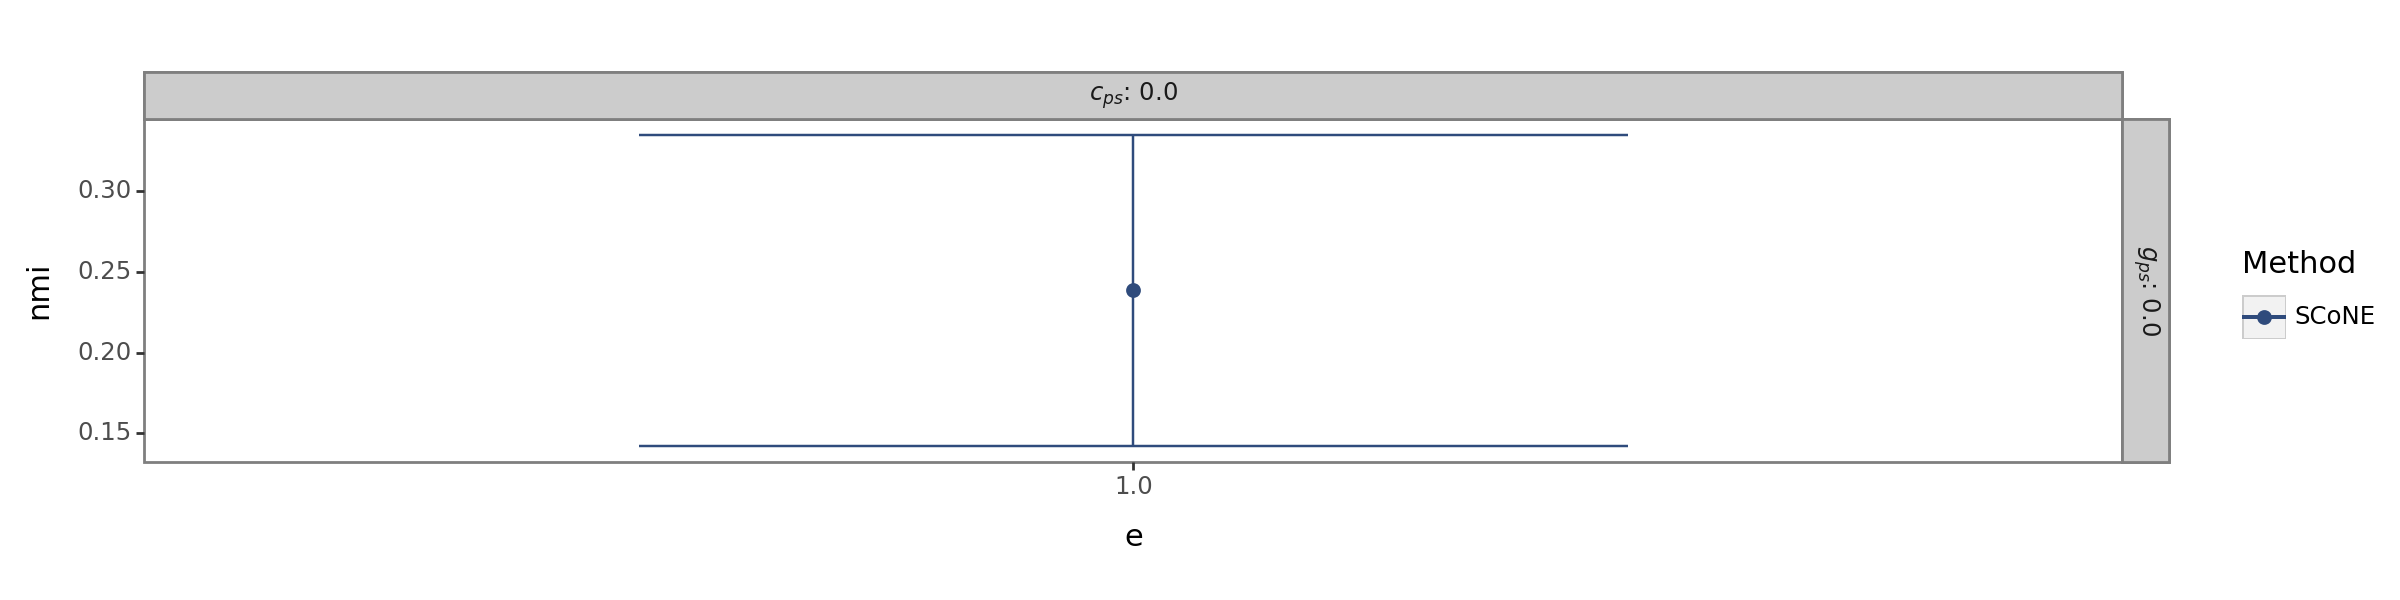

In [100]:
for metric in ['nmi']:
    summary = (
        all_runs.groupby(["run_name", "g_ps", "c_ps", "e"])[metric]
            .agg(n='count', mean='mean', std='std').reset_index()
    )
    summary.rename(columns={'g_ps':r'$g_{ps}$','c_ps':r'$c_{ps}$'},inplace=True)
    summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["n"])         # normal approx 95% CI
    summary["ymin"] = summary["mean"] - summary["ci95"]
    summary["ymax"] = summary["mean"] + summary["ci95"]
    if metric=='norm_cond_entropy':
        metric = 'entropy'
        summary.rename(columns={'norm_cond_entropy':metric},inplace=True)
    p = (
    ggplot(summary, aes(x="factor(e)", y="mean", color="run_name", group="run_name"))
    + geom_point(size=2,position=dodge)
    + geom_line(position=dodge)
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),position=dodge)
    + labs(x="e", y=metric, title='',color='Method')
    + facet_grid(r'$g_{ps}$ ~ $c_{ps}$',labeller='label_both')
    + scale_color_manual(values=colors_dict)
    + theme_bw()
    + theme(
        panel_grid_major = element_blank(),
        panel_grid_minor = element_blank()
    )
    + theme(figure_size=(12,3))
    )
    print(p)